# Dynamic Similarity for Compositional Image Retrieval

This is the **single final notebook** for the project. It loads the final trained system from `final_best_system/`, shows the official metrics and qualitative outputs, and contains the training/evaluation commands behind explicit boolean switches.

The final model keeps CLIP frozen and learns only lightweight source-conditioned composition and reranking modules. The winning inference formula is:

```text
q_model = learned_gate(source, query)
q_sum   = generic CLIP arithmetic(source, query)
q_final = normalize(q_model + 1.25 * (q_sum - source))
```

The notebook is designed to be run quickly by default. Heavy operations such as training and full official JSON evaluation are present but disabled unless the boolean flags are changed.

## Methodological Roadmap

This notebook is organized as a compact report plus runnable code. The project follows the assignment idea of building on CLIP compositionality and CLAY-style conditional similarity, but the implementation is our own lightweight pipeline rather than a third-party repository.

**Baseline and motivation.** We first implemented the assignment-style CLIP arithmetic baseline, where a source image embedding is shifted by signed text directions. We then tested several zero-shot variants: direct sums, sequential sums, and contrastive directions built from positive/negative prompt pairs. The strongest zero-shot baseline was the contrastive sequential variant, which motivated treating a multi-attribute query as an ordered composition of semantic directions rather than one long prompt.

**Hybrid compositional core.** The learned model keeps OpenAI CLIP ViT-B/32 frozen. A small sequential gate receives the source image embedding and the signed query directions, then learns how strongly each edit should move the source in CLIP space. The final compositional vector also includes a CLIP-arithmetic correction term:

```text
q_model  = learned sequential gate(source, signed query directions)
q_sum    = contrastive CLIP arithmetic(source, signed query directions)
q_final  = normalize(q_model + beta * (q_sum - source)), beta = 1.25
```

This is the part we consider the main hybrid compositionality contribution: a learned source-conditioned composer plus explicit CLIP semantic arithmetic.

**Training and experimental choices.** Early same-identity training made the model good at retrieving the paired target identity, but it was weak on official JSON queries such as `Male`, `Young`, and `Chubby`, where the official target is not necessarily the same person. We therefore moved to mixed training: same-identity pairs for preservation, official-like synthetic positives for the assignment metric, and weak/global oversampling. We also ran hyperparameter searches over learning rate, source preservation, residual scale, beta, and Hamming-weighted target scores.

**Why a reranker was added.** Oracle top-pool diagnostics showed that the hybrid vector often reaches the right semantic neighbourhood: many official-valid targets appear inside a broad top-500 pool, even when the first top-10 ranking is imperfect. This led to a second-stage calibrated CelebA attribute probe. The final system promotes candidates predicted to satisfy the query and preserve non-query attributes, but fills missing slots with the original CLIP ranking to avoid over-pruning.

**Final reported system.** We report both the hybrid compositional core and the complete retrieval system built on top of it. The complete system improves substantially over the vanilla assignment baseline on Recall@1/5/10 and Precision@1/5/10, while the qualitative examples help explain remaining precision limitations.


## Literature Connection and Original Contribution

The assignment asks us to build on two ideas: CLIP compositionality and CLAY-style conditional similarity. We used them as design constraints rather than copying an external implementation.

- **CLIP / Berasi et al. motivation.** Frozen CLIP ViT-B/32 gives a shared image-text space where semantic directions can be formed from prompts. However, plain text/image arithmetic is brittle when several edits must be composed, especially for negative attributes and correlated concepts. This motivated prompt ensembles and contrastive directions of the form `d_attr = normalize(t_with_attr - t_without_attr)`.
- **CLAY motivation.** CLAY frames retrieval as conditional similarity: the query condition should change what it means for two images to be similar. We keep the same spirit but avoid a fixed condition stack. Instead, we learn a source-conditioned sequential composer that decides how strongly each signed direction should move the source in CLIP space.
- **Our original contribution.** The final method is hybrid: a learned sequential gate composes multiple signed CLIP directions, and a zero-shot arithmetic branch acts as a correction vector. The full retrieval system then adds a calibrated attribute probe as a second-stage verifier. All trainable modules are lightweight PyTorch models written in this project; CLIP itself is used as the required frozen backbone.


## Experimental Decision Trail

The final system was not chosen in one jump. The table summarizes the main experiments and why each one changed the next design choice.

| Stage | What we tested | Main finding | Decision / pivot |
| --- | --- | --- | --- |
| Assignment baseline | Direct CLIP arithmetic: `source + signed text directions` | Simple and weak: direct-sum Macro R@10 was about `0.108`. | Needed a stronger zero-shot baseline and better composition. |
| Contrastive arithmetic | Positive/negative prompt pairs and sequential normalization | Contrastive sequential became the strongest zero-shot baseline, Macro R@10 about `0.187`. | Use contrastive signed directions as the primitive edit representation. |
| Early learned gate | Learned source-conditioned weights over edit directions | Improved local edits but still mismatched official JSON on global/correlated attributes such as `Male`, `Young`, `Chubby`. | Treat training/evaluation mismatch as the central issue, not only model capacity. |
| Same-identity training analysis | Exact target B from same identity | Synthetic validation was strong, but official JSON often accepts cross-identity targets. | Keep same-identity as preservation signal, but add official-like synthetic positives. |
| Pure official-like positives | Multi-positive sets satisfying query and Hamming-style preservation | More aligned with benchmark, but too much official-like supervision weakened identity/source preservation. | Use a mixture instead of replacing same-identity training. |
| Hybrid v7 training | `70%` official-like, `20%` same-identity, `10%` weak/global; Hamming-weighted positives | Internal official-like validation reached about `80.6%` R@10; final hybrid core reached Macro R@10 about `0.397`. | Freeze this as the hybrid compositional core. |
| Top-pool oracle diagnostic | Check if valid targets are inside broad top-500 before final ranking | Many valid targets are already in the broad neighbourhood reached by `q_final`. | Add a fair learned reranker/probe instead of only changing the query vector. |
| Probe/reranker sweeps | MLP, residual MLP, label-wise and transformer probes | The best embedding MLP probe beat transformer/CNN variants on Macro R@10. | Use calibrated v4 MLP probe as final reranker, reaching Macro R@10 about `0.479`. |

This process matters because it separates two problems: (1) moving the query vector into the right semantic region, and (2) selecting the clean official-valid images from that region. The hybrid gate+sum solves the first problem reasonably well; the probe-based reranker addresses the second.


## Expected Folder Layout

For a complete rerun, keep the notebook at the repository root or under `notebooks/`, with the final artifacts in `final_best_system/`:

```text
deep_learning/
├── notebooks/
│   └── DL26_Project_Delivery_notebook.ipynb
├── final_best_system/
│   ├── weights/best_val_official_like_at10.pt
│   ├── data/celeba_evaluation.json
│   ├── data/celeba/annotations/list_attr_celeba.txt
│   ├── data/celeba/embeddings/openai_clip_vit_b32/test_image_embeddings.pt
│   ├── data/celeba/embeddings/openai_clip_vit_b32/attribute_text_embeddings.pt
│   ├── data/celeba/embeddings/openai_clip_vit_b32/signed_attribute_prompt_embeddings_v2_photo_templates.pt
│   └── results/probe_embedding_v4_m04/probe/best_probe.pt
└── celeba/img_align_celeba/        # needed only for qualitative image grids
```

The submitted notebook keeps outputs embedded. The artifact paths above are required only if the reviewer wants to rerun the code cells.


## Colab Execution Notes

The notebook expects the submitted project artifacts to be present next to it, especially `final_best_system/`. The final package contains the trained gate checkpoint, the best v4 probe checkpoint, calibrated thresholds, test-gallery CLIP embeddings, prompt embeddings, CelebA attributes, and the official evaluation JSON needed for inference/evaluation.

The full CelebA image folder is only needed for qualitative grids. If images are unavailable, metric tables and vector-based inference still run from the packaged embeddings.

Heavy training and full JSON recomputation are disabled by default through boolean flags so the notebook can be inspected quickly. The training cells are included for reproducibility/smoke testing, but the delivered results are loaded from the saved final artifacts.

All qualitative figures used in the report are embedded directly in this notebook, so they remain visible even when opened in Google Colab.



In [1]:
# Runtime switches. Defaults are safe for a quick delivery-notebook smoke run.
RUN_INSTALL_DEPS = True

# Heavy operations. Keep False for normal review; set True only when deliberately retraining/recomputing.
RUN_FULL_TRAINING = False
RUN_SHORT_TRAINING_SMOKE = False
RUN_RECOMPUTE_EMBEDDINGS = False
RUN_RECOMPUTE_PROMPT_EMBEDDINGS = False
RUN_FULL_JSON_EVALUATION = False
RUN_FILTERING_MATRIX_RECOMPUTE = False

# Lightweight checks/outputs used in the submitted notebook.
RUN_PAIR_CONSTRUCTION_DEMO = True
RUN_EMBEDDING_CACHE_SMOKE = True
RUN_FINAL_SYSTEM_SMOKE = True
RUN_QUALITATIVE_EXAMPLES = True
RUN_ORACLE_DIAGNOSTIC_SMOKE = False

DEVICE_REQUEST = "auto"
FINAL_BETA = 1.25

# Example used for the quick inference cell.
EXAMPLE_QUERY_ID = 5
EXAMPLE_SOURCE_INDEX = 3
EXAMPLE_TOP_K = 10


In [2]:
if RUN_INSTALL_DEPS:
    import subprocess
    import sys
    subprocess.run([
        sys.executable, "-m", "pip", "install",
        "torch", "torchvision", "pandas", "matplotlib", "pillow", "tqdm"
    ], check=True)
else:
    print("Dependency installation skipped. Set RUN_INSTALL_DEPS=True only if needed.")

## Project Paths and Imports

The notebook searches upward from the current working directory until it finds `final_best_system/` and `cluster/`. This makes it runnable both from the repository root and from the `notebooks/` directory.

In [3]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Image as IPyImage, display


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "final_best_system").is_dir():
            return candidate
    raise RuntimeError("Could not find a project root containing final_best_system/.")


PROJECT_ROOT = find_project_root()
CLUSTER_ROOT = PROJECT_ROOT / "cluster"
FINAL_DIR = PROJECT_ROOT / "final_best_system"
FINAL_CODE = FINAL_DIR / "code"
FINAL_SCRIPTS = FINAL_CODE / "scripts"
FINAL_ORCH = FINAL_CODE / "orchestrator"
FINAL_PROBE = FINAL_CODE / "probe_filtering"

# For the runnable final package, project_core should resolve data under final_best_system/data.
os.environ["DL_PROJECT_ROOT"] = str(FINAL_DIR)
sys.path.insert(0, str(FINAL_SCRIPTS))
sys.path.insert(0, str(FINAL_ORCH))
sys.path.insert(0, str(FINAL_PROBE))

from learned_gate_core import condition_embeddings, load_model_checkpoint, load_prompt_embedding_cache
from project_core import choose_device, load_torch, parse_query, read_attribute_table

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FINAL_DIR:", FINAL_DIR)
print("CLUSTER_ROOT exists:", CLUSTER_ROOT.exists())



PROJECT_ROOT: /Users/kuba/deep_learning
FINAL_DIR: /Users/kuba/deep_learning/final_best_system
CLUSTER_ROOT exists: True


## Assignment Metric Definition

The assignment defines `Recall@K` as a **hit-rate**:

```text
Recall@K = 1 if at least one official-valid target appears in top-K, otherwise 0
Precision@K = number of official-valid targets in top-K / K
```

Therefore, a method can have good Recall@10 while still having low Precision@10. This means it often finds at least one valid target, but does not fill the entire top-10 with valid targets.

## Load the Final System

This cell loads:

- the final trained checkpoint from `final_best_system/weights/`;
- the signed prompt embedding cache used by the gate;
- the CLIP text directions used by the arithmetic correction;
- the frozen test image embedding gallery.

In [4]:
DEVICE = choose_device(DEVICE_REQUEST)
print("Device:", DEVICE)

FINAL_CHECKPOINT_PATH = FINAL_DIR / "weights" / "best_val_official_like_at10.pt"
PACKAGE_EMBEDDING_DIR = FINAL_DIR / "data" / "celeba" / "embeddings" / "openai_clip_vit_b32"
PROMPT_CACHE_PATH = PACKAGE_EMBEDDING_DIR / "signed_attribute_prompt_embeddings_v2_photo_templates.pt"
TEXT_DIRECTIONS_PATH = PACKAGE_EMBEDDING_DIR / "attribute_text_embeddings.pt"
TEST_EMBEDDINGS_PATH = PACKAGE_EMBEDDING_DIR / "test_image_embeddings.pt"
EVAL_JSON_PATH = FINAL_DIR / "data" / "celeba_evaluation.json"
PROBE_RESULTS_PATH = FINAL_DIR / "results" / "probe_embedding_v4_m04"
PROBE_CHECKPOINT_PATH = PROBE_RESULTS_PATH / "probe" / "best_probe.pt"
PROBE_THRESHOLDS_PATH = PROBE_RESULTS_PATH / "probe" / "calibrated_thresholds.pt"
PROBE_TEST_PROBS_PATH = PROBE_RESULTS_PATH / "probe" / "test_probe_probs.pt"

required = [
    FINAL_CHECKPOINT_PATH,
    PROMPT_CACHE_PATH,
    TEXT_DIRECTIONS_PATH,
    TEST_EMBEDDINGS_PATH,
    EVAL_JSON_PATH,
    PROBE_CHECKPOINT_PATH,
    PROBE_THRESHOLDS_PATH,
    PROBE_TEST_PROBS_PATH,
]
for path in required:
    assert path.exists(), f"Missing required file: {path}"

final_model, final_checkpoint = load_model_checkpoint(FINAL_CHECKPOINT_PATH, DEVICE)
final_model.eval()
final_config = final_checkpoint["config"]

prompt_cache = load_prompt_embedding_cache(PROMPT_CACHE_PATH)
text_bank = load_torch(TEXT_DIRECTIONS_PATH)
text_directions = F.normalize(text_bank["directions"].float().to(DEVICE), dim=-1)

gallery_cache = load_torch(TEST_EMBEDDINGS_PATH)
gallery = F.normalize(gallery_cache["embeddings"].float().to(DEVICE), dim=-1)
gallery_filenames = list(gallery_cache["filenames"])

attributes, attribute_filenames, attribute_matrix = read_attribute_table()
attribute_to_index = {name: index for index, name in enumerate(attributes)}
filename_to_attribute_row = {name: idx for idx, name in enumerate(attribute_filenames)}
evaluation_json = json.loads(EVAL_JSON_PATH.read_text())

print("Gate checkpoint:", FINAL_CHECKPOINT_PATH)
print("Probe checkpoint:", PROBE_CHECKPOINT_PATH)
print("Prompt cache:", PROMPT_CACHE_PATH.name)
print("Gallery:", gallery.shape)
print("Official JSON query entries:", len(evaluation_json))


Device: mps


Gate checkpoint: /Users/kuba/deep_learning/final_best_system/weights/best_val_official_like_at10.pt
Probe checkpoint: /Users/kuba/deep_learning/final_best_system/results/probe_embedding_v4_m04/probe/best_probe.pt
Prompt cache: signed_attribute_prompt_embeddings_v2_photo_templates.pt
Gallery: torch.Size([19962, 512])
Official JSON query entries: 14


## Final Inference Function

For each source image and textual modification query, the system computes:

```text
q_model = learned_gate(source, query)
q_sum   = normalize(source + sum signed CLIP text directions)
q_final = normalize(q_model + beta * (q_sum - source))
```

Retrieval then ranks every gallery image by cosine similarity with `q_final`.

In [5]:
def condition_tensors_for_query(conditions, batch_size, device):
    max_len = max(1, len(conditions))
    attrs = torch.full((batch_size, max_len), -1, dtype=torch.long, device=device)
    signs = torch.zeros((batch_size, max_len), dtype=torch.int8, device=device)
    for pos, (sign, attr) in enumerate(conditions):
        attrs[:, pos] = attribute_to_index[attr]
        signs[:, pos] = int(sign)
    return attrs, signs


def learned_gate_query(source_embeddings, conditions):
    source_embeddings = F.normalize(source_embeddings.float().to(DEVICE), dim=-1)
    attrs, signs = condition_tensors_for_query(conditions, len(source_embeddings), DEVICE)
    cond, mask = condition_embeddings(
        prompt_cache,
        attrs,
        signs,
        DEVICE,
        str(final_config.get("condition_mode", "signed_direction")),
    )
    with torch.inference_mode():
        q_model, alpha, _ = final_model(source_embeddings, cond, mask)
    return F.normalize(q_model, dim=-1), alpha


def generic_sum_query(source_embeddings, conditions):
    source_embeddings = F.normalize(source_embeddings.float().to(DEVICE), dim=-1)
    edit = torch.zeros_like(source_embeddings)
    for sign, attr in conditions:
        edit = edit + int(sign) * text_directions[attribute_to_index[attr]].unsqueeze(0)
    edit = F.normalize(edit, dim=-1)
    return F.normalize(source_embeddings + edit, dim=-1)


def final_query(source_embeddings, query_text, beta=FINAL_BETA):
    conditions = parse_query(query_text)
    q_model, alpha = learned_gate_query(source_embeddings, conditions)
    q_sum = generic_sum_query(source_embeddings, conditions)
    q_final = F.normalize(q_model + float(beta) * (q_sum - F.normalize(source_embeddings.float().to(DEVICE), dim=-1)), dim=-1)
    return q_final, {"conditions": conditions, "alpha": alpha.detach().cpu(), "q_model": q_model.detach().cpu(), "q_sum": q_sum.detach().cpu()}


def retrieve_topk_for_source(query_id, source_index, top_k=10, beta=FINAL_BETA):
    query_text = evaluation_json[query_id]["query"]
    source = gallery[[source_index]]
    q_final, details = final_query(source, query_text, beta=beta)
    scores = q_final @ gallery.T
    scores[0, source_index] = -torch.inf
    top = scores.topk(top_k, dim=1).indices[0].detach().cpu().tolist()
    valid_targets = set(map(int, evaluation_json[query_id]["ground_truth"].get(str(source_index), [])))
    rows = []
    for rank, idx in enumerate(top, start=1):
        rows.append({
            "rank": rank,
            "test_index": idx,
            "filename": gallery_filenames[idx],
            "official_json_valid": idx in valid_targets,
        })
    return pd.DataFrame(rows), details

## Quick Inference Smoke Test

This cell recomputes the final vector from the final checkpoint and retrieves top-10 images for one official JSON source/query case. It does **not** use the precomputed `retrievals.jsonl`.

In [6]:
query_text = evaluation_json[EXAMPLE_QUERY_ID]["query"]
print(f"Example query_id={EXAMPLE_QUERY_ID}: {query_text}")
print(f"Source index: {EXAMPLE_SOURCE_INDEX}, filename: {gallery_filenames[EXAMPLE_SOURCE_INDEX]}")

example_topk, example_details = retrieve_topk_for_source(EXAMPLE_QUERY_ID, EXAMPLE_SOURCE_INDEX, EXAMPLE_TOP_K)
display(example_topk)
print("Gate alpha values:", example_details["alpha"].numpy().round(3).tolist())

Example query_id=5: +Blond_Hair
Source index: 3, filename: 182641.jpg


,rank,test_index,filename,official_json_valid
0,1,18761,201399.jpg,False
1,2,11084,193722.jpg,False
2,3,15773,198411.jpg,False
3,4,7849,190487.jpg,False
4,5,10657,193295.jpg,True
5,6,8979,191617.jpg,False
6,7,6234,188872.jpg,False
7,8,6770,189408.jpg,False
8,9,13659,196297.jpg,True
9,10,8668,191306.jpg,False


Gate alpha values: [[0.18700000643730164]]


## Full System Smoke Test: Gate + Sum + Probe

The previous cell recomputes the hybrid vector. This cell runs the packaged final evaluator on one tiny official case, verifying that the full pipeline loads: learned gate, CLIP arithmetic correction, v4 probe, calibrated thresholds, and probe-based promote/fill reranking.


In [7]:
# Lightweight end-to-end check: use saved final artifacts and run a tiny official case.
# This cell does not call external scripts and does not require retrievals.jsonl.

def load_probe_assets():
    thresholds_payload = load_torch(PROBE_THRESHOLDS_PATH)
    probe_probs_payload = load_torch(PROBE_TEST_PROBS_PATH)
    thresholds = thresholds_payload["thresholds"]["accuracy"].float().to(DEVICE)
    probe_probs = probe_probs_payload["probs"].float().to(DEVICE)
    probe_attributes = list(probe_probs_payload["attributes"])
    if probe_attributes != attributes:
        raise RuntimeError("Probe attribute order does not match CelebA attribute order.")
    return thresholds, probe_probs

probe_thresholds, test_probe_probs = load_probe_assets()


def truth_query_ok(test_index, conditions):
    filename = gallery_filenames[int(test_index)]
    row = attribute_matrix[filename_to_attribute_row[filename]]
    for sign, attr in conditions:
        wanted = 1 if int(sign) > 0 else -1
        if int(row[attribute_to_index[attr]]) != wanted:
            return False
    return True


def probe_promote_and_fill(source_index, q_final, conditions, top_pool=500, top_k=10):
    scores = (q_final @ gallery.T).squeeze(0)
    scores[int(source_index)] = -torch.inf
    pool = scores.topk(min(int(top_pool), scores.numel()), dim=0).indices

    if not conditions:
        return pool[:top_k].detach().cpu().tolist()

    cond_indices = torch.tensor([attribute_to_index[attr] for _, attr in conditions], device=DEVICE, dtype=torch.long)
    signs = torch.tensor([int(sign) for sign, _ in conditions], device=DEVICE, dtype=torch.long)

    candidate_probs = test_probe_probs[pool]
    candidate_bits = candidate_probs >= probe_thresholds[None, :]
    source_bits = test_probe_probs[int(source_index)] >= probe_thresholds

    wanted_positive = signs > 0
    query_bits = candidate_bits[:, cond_indices]
    query_ok = torch.where(wanted_positive[None, :], query_bits, ~query_bits).all(dim=1)

    nonquery_mask = torch.ones(len(attributes), dtype=torch.bool, device=DEVICE)
    nonquery_mask[cond_indices] = False
    hamming = (candidate_bits[:, nonquery_mask] != source_bits[None, nonquery_mask]).sum(dim=1)
    hamming_ok = hamming <= 2

    promoted = pool[query_ok & hamming_ok].detach().cpu().tolist()
    selected = []
    seen = set()
    for idx in promoted:
        if idx not in seen:
            selected.append(int(idx)); seen.add(int(idx))
        if len(selected) >= top_k:
            break
    # Fill with original q_final ranking to avoid catastrophic over-pruning when the probe is wrong.
    for idx in pool.detach().cpu().tolist():
        if idx not in seen:
            selected.append(int(idx)); seen.add(int(idx))
        if len(selected) >= top_k:
            break
    return selected[:top_k]

if RUN_FINAL_SYSTEM_SMOKE:
    query_text = evaluation_json[EXAMPLE_QUERY_ID]["query"]
    q_final, details = final_query(gallery[[EXAMPLE_SOURCE_INDEX]], query_text, beta=FINAL_BETA)
    selected = probe_promote_and_fill(EXAMPLE_SOURCE_INDEX, q_final, details["conditions"], top_pool=50, top_k=EXAMPLE_TOP_K)
    valid = set(map(int, evaluation_json[EXAMPLE_QUERY_ID]["ground_truth"].get(str(EXAMPLE_SOURCE_INDEX), [])))
    smoke_rows = []
    for rank, idx in enumerate(selected, 1):
        smoke_rows.append({
            "rank": rank,
            "test_index": idx,
            "filename": gallery_filenames[idx],
            "official_json_valid": idx in valid,
            "query_attributes_ok": truth_query_ok(idx, details["conditions"]),
        })
    print("Tiny final-system smoke: gate + corrective sum + v4 probe promote/fill")
    display(pd.DataFrame(smoke_rows))
else:
    print("Final-system smoke skipped.")

final_summary = pd.read_csv(PROBE_RESULTS_PATH / "A_cal_query_hardh2_accuracy" / "summary.csv")
display(final_summary)


Tiny final-system smoke: gate + corrective sum + v4 probe promote/fill


,rank,test_index,filename,official_json_valid,query_attributes_ok
0,1,18761,201399.jpg,False,True
1,2,13659,196297.jpg,True,True
2,3,7917,190555.jpg,False,True
3,4,14487,197125.jpg,False,True
4,5,16138,198776.jpg,True,True
5,6,8496,191134.jpg,True,True
6,7,10034,192672.jpg,False,True
7,8,6432,189070.jpg,False,True
8,9,19906,202544.jpg,False,True
9,10,3768,186406.jpg,False,True


,method,checkpoint,probe_checkpoint,query_entries,source_query_cases,avg_kept_in_pool,macro_Recall@1,macro_Recall@5,macro_Recall@10,macro_Precision@1,...,macro_Precision@10,micro_Recall@1,micro_Recall@5,micro_Recall@10,micro_Precision@1,micro_Precision@5,micro_Precision@10,config_id,arch,loss
0,query_hamming_fill_accuracy,/mnt/meditech/group1/deep_learning/cluster/art...,artifacts/results/probe_arch_sweep_v4_finetune...,14,33052,33.647253,0.123158,0.356573,0.478655,0.123158,...,0.086415,0.096152,0.283704,0.405452,0.096152,0.078513,0.069391,v4_m04_deep_asl_lr2e4_d00,mlp,asl


## CelebA Split Protocol and Leakage Control

CelebA provides an official split file called `list_eval_partition.txt`. Each image filename is assigned to one partition:

| partition id | meaning | local count | role in this project |
| --- | --- | ---: | --- |
| `0` | train | 162,770 | train synthetic pairs and train the attribute probe |
| `1` | validation | 19,867 | internal validation, threshold calibration, checkpoint/model selection |
| `2` | test | 19,962 | final retrieval gallery and official JSON evaluation only |

We used this split explicitly when creating CLIP embedding caches: `train_image_embeddings.pt`, `valid_image_embeddings.pt`, and `test_image_embeddings.pt`.

No official JSON target list is used to optimize model weights. The clean protocol is:

```text
train split      -> optimizer updates
validation split -> internal validation / threshold calibration / model selection
test split + celeba_evaluation.json -> final Recall@K and Precision@K only
```

The word "evaluation" can be confusing here. In `list_eval_partition.txt`, the file name is inherited from CelebA and contains train/validation/test split ids. In `celeba_evaluation.json`, "evaluation" means the professor-provided held-out benchmark. We treat the JSON as test-only.


## Training Pair Construction

Before evaluating on the official JSON, we trained the composer on synthetic pairs built from CelebA annotations. The important point is that the official JSON source-query pairs are not used to build training pairs.

We used three pair families:

1. **Same-identity pairs**: two images of the same identity with different attributes. The query is the signed set of attributes that change from source to target. This teaches source preservation.
2. **Official-like multi-positive pairs**: for a source image and a sampled signed query, valid targets are images satisfying the requested query attributes while keeping the non-query CelebA attributes close to the source with Hamming distance <= 2. This mimics the assignment rule without using official JSON test pairs.
3. **Weak/global oversampling pairs**: same logic as official-like, but oversampling difficult attributes such as `Male`, `Young`, and `Chubby`, which were weak points in early experiments.

The final v7 training mix was:

```text
70% official-like multi-positive pairs
20% same-identity pairs
10% weak/global oversampling
```

The small cell below does not enumerate the full training set; it reconstructs the same logic on local annotations and prints concrete examples. Full enumeration/training was run on the cluster because it depends on the full train/valid embedding caches and runs for many thousands of steps.


In [8]:
from collections import defaultdict


def find_local_annotation(name):
    candidates = [
        FINAL_DIR / "data" / "celeba" / "annotations" / name,
        PROJECT_ROOT / "data" / "celeba" / "annotations" / name,
        PROJECT_ROOT / "cluster" / "data" / "celeba" / "annotations" / name,
        PROJECT_ROOT / "celeba" / name,
    ]
    for path in candidates:
        if path.exists():
            return path
    return None


def read_attr_file(path):
    lines = path.read_text().splitlines()
    attrs = lines[1].split()
    rows = {}
    for line in lines[2:]:
        parts = line.split()
        if not parts:
            continue
        rows[parts[0]] = {attr: int(value) for attr, value in zip(attrs, parts[1:])}
    return attrs, rows


def read_identity_file(path):
    by_identity = defaultdict(list)
    for line in path.read_text().splitlines():
        parts = line.split()
        if len(parts) == 2:
            by_identity[parts[1]].append(parts[0])
    return by_identity


def signed_changes(source_attrs, target_attrs, max_changes=8):
    changes = []
    for attr in source_attrs:
        before = source_attrs[attr]
        after = target_attrs[attr]
        if before != after:
            changes.append(("+" if after == 1 else "-", attr))
    return changes[:max_changes]


def hamming_non_query(source_attrs, candidate_attrs, query_attrs):
    return sum(
        source_attrs[attr] != candidate_attrs[attr]
        for attr in source_attrs
        if attr not in query_attrs
    )


def satisfies_query(candidate_attrs, conditions):
    return all(candidate_attrs[attr] == (1 if sign == "+" else -1) for sign, attr in conditions)

attr_path = find_local_annotation("list_attr_celeba.txt")
identity_path = find_local_annotation("identity_CelebA.txt")

if not attr_path:
    print("CelebA attribute annotations not found; pair-construction demo skipped.")
else:
    attrs, attr_rows = read_attr_file(attr_path)
    print("Loaded attributes:", len(attrs), "images:", len(attr_rows))

    if identity_path:
        identities = read_identity_file(identity_path)
        same_identity_example = None
        for identity, files in identities.items():
            files = [f for f in files if f in attr_rows]
            if len(files) < 2:
                continue
            for i in range(min(len(files), 8)):
                for j in range(i + 1, min(len(files), 8)):
                    a, b = files[i], files[j]
                    changes = signed_changes(attr_rows[a], attr_rows[b])
                    if changes:
                        same_identity_example = (identity, a, b, changes)
                        break
                if same_identity_example:
                    break
            if same_identity_example:
                break
        print("\nSame-identity example:")
        if same_identity_example:
            identity, a, b, changes = same_identity_example
            print({"identity": identity, "source": a, "target": b, "query_changes": changes})
        else:
            print("No same-identity attribute-change example found in local annotations.")
    else:
        print("identity_CelebA.txt not found; same-identity demo skipped.")

    def find_official_like_example(conditions, max_sources=2000, max_candidates=8000):
        query_attrs = {attr for _, attr in conditions}
        candidate_pool = [
            (fname, row)
            for fname, row in attr_rows.items()
            if satisfies_query(row, conditions)
        ][:max_candidates]
        for source_file, source_row in list(attr_rows.items())[:max_sources]:
            candidates = []
            for fname, row in candidate_pool:
                if fname == source_file:
                    continue
                h = hamming_non_query(source_row, row, query_attrs)
                if h <= 2:
                    candidates.append((fname, h))
                if len(candidates) >= 5:
                    return source_file, candidates
        return None, []

    print("\nOfficial-like example:")
    conditions = [("+", "Smiling"), ("+", "Eyeglasses")]
    source_file, candidates = find_official_like_example(conditions)
    print({
        "source": source_file,
        "query": conditions,
        "valid_targets_sample_hamming_le2": candidates[:5],
    })

    print("\nWeak/global focused example:")
    weak_conditions = [("+", "Male"), ("-", "Young")]
    weak_source_file, weak_candidates = find_official_like_example(weak_conditions)
    print({
        "source": weak_source_file,
        "query": weak_conditions,
        "valid_targets_sample_hamming_le2": weak_candidates[:5],
    })



Loaded attributes: 40 images: 202599

Same-identity example:
{'identity': '2880', 'source': '000001.jpg', 'target': '000404.jpg', 'query_changes': [('-', 'Arched_Eyebrows'), ('-', 'Straight_Hair'), ('+', 'Wavy_Hair'), ('-', 'Wearing_Earrings')]}

Official-like example:
{'source': '000002.jpg', 'query': [('+', 'Smiling'), ('+', 'Eyeglasses')], 'valid_targets_sample_hamming_le2': [('056777.jpg', 2), ('093464.jpg', 2), ('119184.jpg', 2), ('144654.jpg', 2), ('166112.jpg', 2)]}

Weak/global focused example:


{'source': '000002.jpg', 'query': [('+', 'Male'), ('-', 'Young')], 'valid_targets_sample_hamming_le2': [('000068.jpg', 2), ('000771.jpg', 2), ('000775.jpg', 2), ('000790.jpg', 2), ('000898.jpg', 2)]}


## Training Objective and Optimization Choices

Let `s` be the normalized CLIP image embedding of the source image and let `d_1, ..., d_m` be the signed contrastive CLIP directions for the query attributes. For example, `+Eyeglasses` uses `d = normalize(t_with_glasses - t_without_glasses)`, while `-Young` uses `-d_young`.

The learned sequential composer applies the edits one by one:

```text
q_0 = s
alpha_j = gate(q_{j-1}, d_j)
q_j = normalize(q_{j-1} + alpha_j d_j + small_residual_j)
q_model = q_m
```

In parallel, we compute a transparent CLIP arithmetic branch:

```text
q_sum = normalize(s + sum_j d_j)
q_hybrid = normalize(q_model + beta * (q_sum - s))
```

The correction `(q_sum - s)` is not added as an unnormalized Euclidean displacement. Retrieval is cosine-based after normalization; the correction mostly changes the angular direction of the final query vector.

The final v7 gate objective is:

```text
L_total = L_infoNCE
        + lambda_target * (1 - cos(q_hybrid, target))
        + lambda_source * (1 - cos(q_hybrid, source))
        + lambda_triplet * L_triplet
```

where:

```text
L_infoNCE = (1 - w) * L_exact_target
          + w * L_weighted_multi_positive
```

`L_exact_target` uses the same-identity target B. `L_weighted_multi_positive` uses compatible train-split positives that satisfy the query and preserve non-query attributes. Positives with non-query Hamming distance <= 1 receive weight `1.0`; positives at distance exactly 2 receive a smaller weight; invalid candidates receive weight `0`. This keeps the official <=2 rule while preferring stronger source preservation.

The final gate run used AdamW, batch size `256`, learning rate `5e-5`, weight decay `1e-4`, temperature `0.02`, gradient clipping `1.0`, dropout `0.1`, and validation every `4000` optimizer steps. These choices were selected after shorter cluster sweeps: AdamW was stable for frozen-embedding MLP training, clipping avoided occasional large gradient spikes, and the batch size was a practical compromise between contrastive negatives and GPU memory.

The final probe is a multi-label attribute verifier trained on frozen CLIP image embeddings:

```text
probe(z_image) -> 40 CelebA attribute logits
```

The selected v4 probe is an MLP with hidden dimensions `(1536, 1024, 512)`, ASL loss, AdamW, learning rate `2e-4`, batch size `2048`, no dropout, and per-attribute threshold calibration on validation. We tried deeper/wider MLPs, residual MLPs, label-wise probes, transformer probes, and from-scratch CNN/fusion probes. The MLP remained best on the final retrieval objective, likely because the frozen CLIP embedding already contains enough global attribute information for the verifier, while larger architectures added complexity without better calibration.


## Internal Training and Validation Metrics

We report two different kinds of numbers:

- **Internal training/validation metrics**: measured on our synthetic pair dataset and validation gallery. These tell us whether the model is learning the training objective.
- **Official JSON metrics**: measured only after training on the professor-provided evaluation JSON. These are the final assignment metrics.

For the gate/composer training we tracked:

```text
train_loss, train_info_nce, train_cos_q_source, train_cos_q_target,
val_exact_R@10, val_attr_success@10, val_official_like@10, val_mean_rank_B
```

For the final probe training we tracked:

```text
train_loss, macro F1, macro accuracy, % validation images with predicted Hamming <= 2
```

If the gate training logs are not present locally, the cell below prints the exact copy command to fetch them from the cluster.


Gate training metrics path: /Users/kuba/deep_learning/final_best_system/results/gate_training_v7/metrics.csv


,epoch,step,train_loss,train_info_nce,train_exact_info_nce,train_multipositive_info_nce,train_multipositive_weight,train_weighted_positive_mean,train_hamming_le1_positive_count,train_hamming_eq2_positive_count,...,val_exact_R@5,val_exact_R@10,val_attr_success@1,val_attr_success@5,val_attr_success@10,val_official_like@1,val_official_like@5,val_official_like@10,val_mean_rank_B,val_queries
0,2,4000,1.783234,1.702717,1.930926,1.626648,0.75,0.825081,0.509428,1.052788,...,0.392334,0.571777,0.383789,0.814941,0.927246,0.260498,0.642578,0.797852,53.134766,4096
1,4,8000,1.656323,1.575738,1.788645,1.504768,0.75,0.825124,0.509983,1.052564,...,0.393311,0.586182,0.372314,0.796631,0.920654,0.248047,0.635010,0.796631,62.786377,4096
2,6,12000,1.604479,1.524311,1.732376,1.454956,0.75,0.825023,0.508499,1.053128,...,0.407715,0.576416,0.368896,0.796631,0.915771,0.255127,0.641846,0.790283,49.886963,4096
3,8,16000,1.566468,1.486673,1.691162,1.418510,0.75,0.825071,0.508088,1.049233,...,0.420654,0.597900,0.377686,0.811035,0.924072,0.266357,0.660645,0.805908,60.850342,4096
4,10,20000,1.531625,1.452226,1.654654,1.384750,0.75,0.825095,0.508815,1.051627,...,0.393555,0.580322,0.376221,0.787842,0.916748,0.260986,0.635986,0.798584,61.910400,4096


/var/folders/lj/9m2788vx3s30t4gnyb0r4ppw0000gn/T/ipykernel_74027/1809477203.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


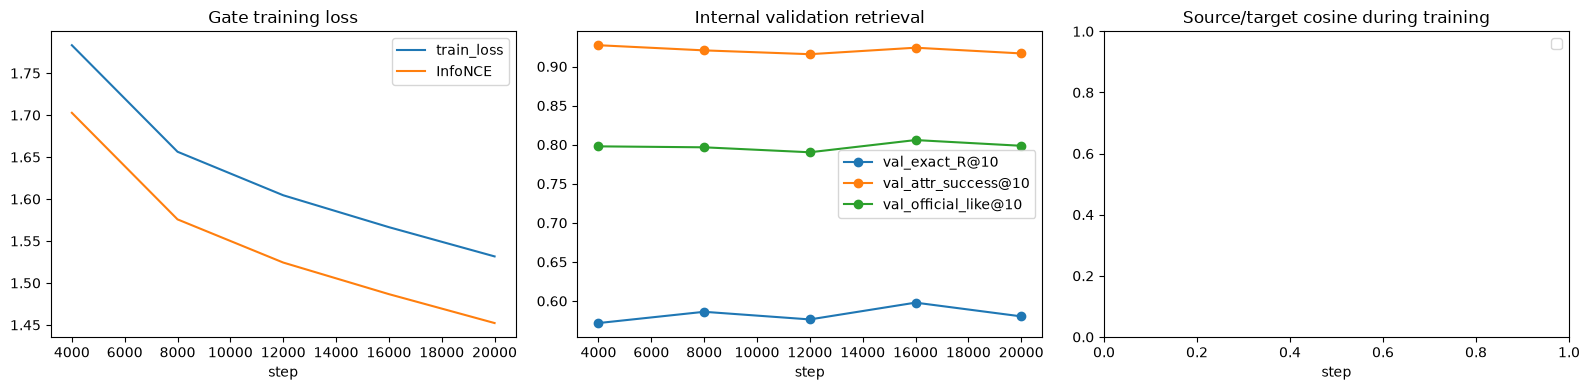


Last internal validation / best lines:
[2026-06-26 16:59:24] validation epoch=2 step=4000 exact@10=0.5718 attr@10=0.9272 official_like@10=0.7979 mean_rank_B=53.1
[2026-06-26 16:59:24] BEST_OFFICIAL_LIKE epoch=2 step=4000 val_official_like@10=0.7979
[2026-06-26 16:59:25] BEST_EXACT epoch=2 step=4000 val_exact_R@10=0.5718
[2026-06-26 17:00:31] validation epoch=4 step=8000 exact@10=0.5862 attr@10=0.9207 official_like@10=0.7966 mean_rank_B=62.8
[2026-06-26 17:00:32] BEST_EXACT epoch=4 step=8000 val_exact_R@10=0.5862
[2026-06-26 17:01:37] validation epoch=6 step=12000 exact@10=0.5764 attr@10=0.9158 official_like@10=0.7903 mean_rank_B=49.9
[2026-06-26 17:02:42] validation epoch=8 step=16000 exact@10=0.5979 attr@10=0.9241 official_like@10=0.8059 mean_rank_B=60.9
[2026-06-26 17:02:42] BEST_OFFICIAL_LIKE epoch=8 step=16000 val_official_like@10=0.8059
[2026-06-26 17:02:42] BEST_EXACT epoch=8 step=16000 val_exact_R@10=0.5979
[2026-06-26 17:03:50] validation epoch=10 step=20000 exact@10=0.5803 at

,epoch,step,train_loss,selection_score,acc_macro_f1,acc_macro_accuracy,acc_pct_hamming_le2,f1_macro_f1,f1_macro_recall,f1_pct_hamming_le2
4,5,400,0.186077,0.782575,0.677883,0.911715,0.301354,0.722304,0.775743,0.221875
5,6,480,0.183481,0.784971,0.678422,0.912073,0.305230,0.723925,0.781136,0.215030
6,7,560,0.181416,0.787681,0.688144,0.912720,0.311874,0.725306,0.781819,0.221976
7,8,640,0.179444,0.788772,0.692179,0.912774,0.313535,0.726065,0.780757,0.223939
8,9,720,0.177733,0.789859,0.688430,0.912979,0.313183,0.727222,0.785461,0.222026
9,10,800,0.176007,0.791167,0.691450,0.913287,0.317511,0.727665,0.782928,0.230332
10,11,880,0.174358,0.791708,0.690192,0.913575,0.320230,0.727662,0.786534,0.221573
11,12,960,0.172758,0.792609,0.694475,0.913622,0.319928,0.728624,0.787180,0.230181
12,13,1040,0.171469,0.792602,0.694532,0.913704,0.321991,0.728204,0.787474,0.225248
13,14,1120,0.170121,0.792523,0.690649,0.913935,0.321891,0.728145,0.785611,0.225751


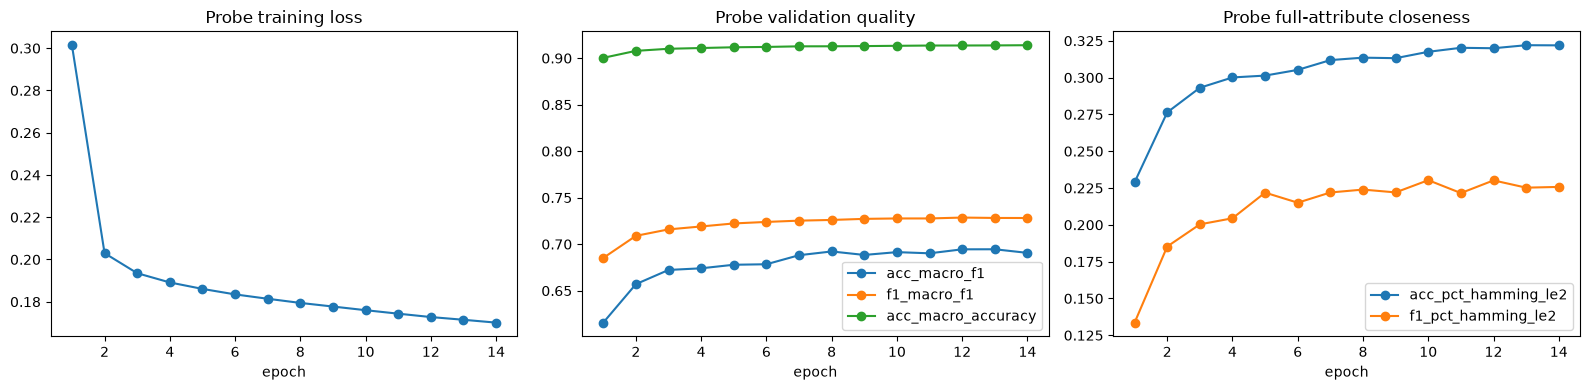

In [9]:
GATE_TRAINING_DIR = FINAL_DIR / "results" / "gate_training_v7"
GATE_METRICS_PATH = GATE_TRAINING_DIR / "metrics.csv"
GATE_PROGRESS_PATH = GATE_TRAINING_DIR / "progress.txt"
GATE_HPSEARCH_SUMMARY_PATH = GATE_TRAINING_DIR / "hpsearch_summary.csv"
PROBE_TRAIN_METRICS_PATH = PROBE_RESULTS_PATH / "probe" / "train_metrics.csv"

print("Gate training metrics path:", GATE_METRICS_PATH)
if not GATE_METRICS_PATH.exists():
    print("\nGate training CSV is not present locally yet.")
    print("Run this on your Mac to copy the final v7 training logs from the cluster:\n")
    copy_command = """cd /Users/kuba/deep_learning
REMOTE="kuba.diquattro@baldo.disi.unitn.it"
REMOTE_ROOT="/mnt/meditech/group1/deep_learning/cluster"
REMOTE_SEARCH="$REMOTE_ROOT/artifacts/training_runs/hpsearch_hamming_weighted_v7_20260626_163418_long"
REMOTE_RUN="$REMOTE_SEARCH/hamming_weighted_v7_v7_70_001_h2_0p75_off0p7_same0p2_weak0p1_h20p75_lr5em05_beta0p75_long"
mkdir -p final_best_system/results/gate_training_v7
rsync -av "$REMOTE:$REMOTE_RUN/metrics.csv" final_best_system/results/gate_training_v7/
rsync -av "$REMOTE:$REMOTE_RUN/progress.txt" final_best_system/results/gate_training_v7/
rsync -av "$REMOTE:$REMOTE_RUN/config.json" final_best_system/results/gate_training_v7/
rsync -av "$REMOTE:$REMOTE_SEARCH/summary.csv" final_best_system/results/gate_training_v7/hpsearch_summary.csv
"""
    print(copy_command)
else:
    gate_metrics = pd.read_csv(GATE_METRICS_PATH)
    display(gate_metrics.tail(10))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(gate_metrics["step"], gate_metrics["train_loss"], label="train_loss")
    if "train_info_nce" in gate_metrics:
        axes[0].plot(gate_metrics["step"], gate_metrics["train_info_nce"], label="InfoNCE")
    axes[0].set_title("Gate training loss")
    axes[0].set_xlabel("step")
    axes[0].legend()

    validation_cols = [c for c in ["val_exact_R@10", "val_attr_success@10", "val_official_like@10"] if c in gate_metrics]
    for col in validation_cols:
        axes[1].plot(gate_metrics["step"], gate_metrics[col], marker="o", label=col)
    axes[1].set_title("Internal validation retrieval")
    axes[1].set_xlabel("step")
    axes[1].legend()

    cosine_cols = [c for c in ["train_cos_q_source", "train_cos_q_target"] if c in gate_metrics]
    for col in cosine_cols:
        axes[2].plot(gate_metrics["step"], gate_metrics[col], label=col)
    axes[2].set_title("Source/target cosine during training")
    axes[2].set_xlabel("step")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    if GATE_PROGRESS_PATH.exists():
        best_lines = [line for line in GATE_PROGRESS_PATH.read_text().splitlines() if "BEST_" in line or "validation" in line]
        print("\nLast internal validation / best lines:")
        for line in best_lines[-12:]:
            print(line)

print("\nProbe training metrics path:", PROBE_TRAIN_METRICS_PATH)
if PROBE_TRAIN_METRICS_PATH.exists():
    probe_metrics = pd.read_csv(PROBE_TRAIN_METRICS_PATH)
    display(probe_metrics.tail(10))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(probe_metrics["epoch"], probe_metrics["train_loss"], marker="o")
    axes[0].set_title("Probe training loss")
    axes[0].set_xlabel("epoch")

    for col in ["acc_macro_f1", "f1_macro_f1", "acc_macro_accuracy"]:
        if col in probe_metrics:
            axes[1].plot(probe_metrics["epoch"], probe_metrics[col], marker="o", label=col)
    axes[1].set_title("Probe validation quality")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    for col in ["acc_pct_hamming_le2", "f1_pct_hamming_le2"]:
        if col in probe_metrics:
            axes[2].plot(probe_metrics["epoch"], probe_metrics[col], marker="o", label=col)
    axes[2].set_title("Probe full-attribute closeness")
    axes[2].set_xlabel("epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Probe train metrics are missing too; expected:", PROBE_TRAIN_METRICS_PATH)


## Internal Metrics: Definitions, Source Files, and Best Values

The training curves above are not official JSON results. They are internal diagnostics computed on our synthetic training/validation setup.

**Where the numbers come from**

- Gate/composer metrics are loaded from `final_best_system/results/gate_training_v7/metrics.csv`.
- The v7 HP-search summary is loaded from `final_best_system/results/gate_training_v7/hpsearch_summary.csv`.
- Probe/verifier metrics are loaded from `final_best_system/results/probe_embedding_v4_m04/probe/train_metrics.csv`.
- Probe architecture-sweep evaluation rows are loaded from `final_best_system/results/probe_embedding_v4_m04/aggregate_summary.csv`.

**What is a step?**

A `step` is one optimizer update on one mini-batch, not an epoch. In the final gate run the batch size was 256, so `step=4000` means 4000 mini-batch gradient updates. The plots start at `step=4000` because validation/checkpoint metrics were logged only at validation intervals; training did start from step 0, but no validation point was saved before the first checkpoint.

**Internal gate metrics**

- `val_exact_R@K`: fraction of synthetic validation queries for which the exact synthetic target image B appears in the top K.
- `val_attr_success@K`: fraction of validation queries for which at least one top-K retrieved image satisfies the requested edited attributes.
- `val_official_like@K`: internal official-like success, using the same spirit as the assignment: satisfy query attributes and preserve non-query attributes under a Hamming-style constraint.
- `val_mean_rank_B`: average rank of the exact synthetic target B; lower is better.

**Probe metrics**

- `acc_macro_accuracy`: average per-attribute classification accuracy over the 40 CelebA attributes.
- `acc_macro_f1` / `f1_macro_f1`: macro-F1 over attributes under different threshold objectives.
- `acc_pct_hamming_le2`: fraction of validation images where the predicted 40-attribute vector differs from ground truth in at most two attributes.

The cell below recomputes the headline values directly from those CSVs, so the reported numbers are traceable and reproducible.


In [10]:
# Summarize internal metrics directly from the saved cluster CSV files.
metric_sources = pd.DataFrame(
    [
        {"artifact": "Gate validation curves", "path": str(GATE_METRICS_PATH.relative_to(PROJECT_ROOT))},
        {"artifact": "Gate HP-search summary", "path": str(GATE_HPSEARCH_SUMMARY_PATH.relative_to(PROJECT_ROOT))},
        {"artifact": "Probe training curves", "path": str(PROBE_TRAIN_METRICS_PATH.relative_to(PROJECT_ROOT))},
        {"artifact": "Probe architecture sweep", "path": str((PROBE_RESULTS_PATH / "aggregate_summary.csv").relative_to(PROJECT_ROOT))},
    ]
)
print("Metric source files")
display(metric_sources)

if GATE_METRICS_PATH.exists():
    gate_metrics = pd.read_csv(GATE_METRICS_PATH)
    gate_best_rows = []
    for metric, meaning in [
        ("val_exact_R@1", "exact target B in top-1"),
        ("val_exact_R@5", "exact target B in top-5"),
        ("val_exact_R@10", "exact target B in top-10"),
        ("val_attr_success@10", "any top-10 result satisfies requested attributes"),
        ("val_official_like@10", "internal official-like success@10"),
    ]:
        if metric in gate_metrics:
            row = gate_metrics.loc[gate_metrics[metric].idxmax()]
            gate_best_rows.append(
                {
                    "metric": metric,
                    "meaning": meaning,
                    "best_value": float(row[metric]),
                    "as_percent": f"{100 * float(row[metric]):.2f}%",
                    "epoch": int(row["epoch"]),
                    "step": int(row["step"]),
                }
            )
    gate_best = pd.DataFrame(gate_best_rows)
    print("Gate/composer internal best values")
    display(gate_best)

    first, last = gate_metrics.iloc[0], gate_metrics.iloc[-1]
    gate_progress = pd.DataFrame(
        [
            {
                "metric": "train_loss",
                "first_logged": float(first["train_loss"]),
                "last_logged": float(last["train_loss"]),
                "relative_change": f"{100 * (float(last['train_loss']) / float(first['train_loss']) - 1):.1f}%",
            },
            {
                "metric": "train_info_nce",
                "first_logged": float(first["train_info_nce"]),
                "last_logged": float(last["train_info_nce"]),
                "relative_change": f"{100 * (float(last['train_info_nce']) / float(first['train_info_nce']) - 1):.1f}%",
            },
            {
                "metric": "train_cos_final_target",
                "first_logged": float(first["train_cos_final_target"]),
                "last_logged": float(last["train_cos_final_target"]),
                "relative_change": f"{100 * (float(last['train_cos_final_target']) / float(first['train_cos_final_target']) - 1):.1f}%",
            },
        ]
    )
    print("Gate/composer training trend")
    display(gate_progress)

if PROBE_TRAIN_METRICS_PATH.exists():
    probe_metrics = pd.read_csv(PROBE_TRAIN_METRICS_PATH)
    probe_best_rows = []
    for metric, meaning in [
        ("acc_macro_accuracy", "mean per-attribute accuracy over 40 CelebA attributes"),
        ("acc_macro_f1", "macro F1 with accuracy-calibrated thresholds"),
        ("f1_macro_f1", "macro F1 with F1-calibrated thresholds"),
        ("f1_macro_recall", "macro recall with F1-calibrated thresholds"),
        ("acc_pct_hamming_le2", "images with <=2 errors over all 40 predicted attributes"),
    ]:
        if metric in probe_metrics:
            row = probe_metrics.loc[probe_metrics[metric].idxmax()]
            probe_best_rows.append(
                {
                    "metric": metric,
                    "meaning": meaning,
                    "best_value": float(row[metric]),
                    "as_percent": f"{100 * float(row[metric]):.2f}%",
                    "epoch": int(row["epoch"]),
                    "step": int(row["step"]),
                }
            )
    print("Probe/verifier internal best values")
    display(pd.DataFrame(probe_best_rows))

    first, last = probe_metrics.iloc[0], probe_metrics.iloc[-1]
    probe_progress = pd.DataFrame(
        [
            {
                "metric": "train_loss",
                "first_logged": float(first["train_loss"]),
                "last_logged": float(last["train_loss"]),
                "relative_change": f"{100 * (float(last['train_loss']) / float(first['train_loss']) - 1):.1f}%",
            },
            {
                "metric": "selection_score",
                "first_logged": float(first["selection_score"]),
                "last_logged": float(last["selection_score"]),
                "relative_change": f"{100 * (float(last['selection_score']) / float(first['selection_score']) - 1):.1f}%",
            },
        ]
    )
    print("Probe/verifier training trend")
    display(probe_progress)


Metric source files


,artifact,path
0,Gate validation curves,final_best_system/results/gate_training_v7/met...
1,Gate HP-search summary,final_best_system/results/gate_training_v7/hps...
2,Probe training curves,final_best_system/results/probe_embedding_v4_m...
3,Probe architecture sweep,final_best_system/results/probe_embedding_v4_m...


Gate/composer internal best values


,metric,meaning,best_value,as_percent,epoch,step
0,val_exact_R@1,exact target B in top-1,0.124023,12.40%,8,16000
1,val_exact_R@5,exact target B in top-5,0.420654,42.07%,8,16000
2,val_exact_R@10,exact target B in top-10,0.597900,59.79%,8,16000
3,val_attr_success@10,any top-10 result satisfies requested attributes,0.927246,92.72%,2,4000
4,val_official_like@10,internal official-like success@10,0.805908,80.59%,8,16000


Gate/composer training trend


,metric,first_logged,last_logged,relative_change
0,train_loss,1.783234,1.531625,-14.1%
1,train_info_nce,1.702717,1.452226,-14.7%
2,train_cos_final_target,0.357365,0.362831,1.5%


Probe/verifier internal best values


,metric,meaning,best_value,as_percent,epoch,step
0,acc_macro_accuracy,mean per-attribute accuracy over 40 CelebA att...,0.913935,91.39%,14,1120
1,acc_macro_f1,macro F1 with accuracy-calibrated thresholds,0.694532,69.45%,13,1040
2,f1_macro_f1,macro F1 with F1-calibrated thresholds,0.728624,72.86%,12,960
3,f1_macro_recall,macro recall with F1-calibrated thresholds,0.787474,78.75%,13,1040
4,acc_pct_hamming_le2,images with <=2 errors over all 40 predicted a...,0.321991,32.20%,13,1040


Probe/verifier training trend


,metric,first_logged,last_logged,relative_change
0,train_loss,0.301411,0.170121,-43.6%
1,selection_score,0.730991,0.792523,8.4%


## Official Results Saved in the Repository

The full official evaluation over all 33,052 official **test cases** has already been run on the cluster and copied into `final_best_system/results/`.

Important: these JSON cases were **not used for training**. The file `celeba_evaluation.json` is treated as a held-out benchmark. During optimization we generated synthetic source/query/target supervision only from CelebA train-split annotations. The validation split was used only for internal validation, threshold calibration, and checkpoint/model selection. After training was finished, each official JSON source image and query was passed through the frozen system, the top-k retrievals were computed, and only then were they compared with the JSON target lists to compute Recall@K and Precision@K.

The table below compares:

1. assignment baseline: direct CLIP arithmetic;
2. strongest zero-shot CLIP baseline: contrastive sequential arithmetic;
3. hybrid core: learned gate + generic arithmetic correction;
4. final full system: hybrid core + calibrated v4 attribute-probe reranking.


Macro metrics: each query counts equally.


,system,method,macro_Recall@1,macro_Recall@5,macro_Recall@10,macro_Precision@1,macro_Precision@5,macro_Precision@10
0,Assignment baseline,direct_sum,0.023967,0.071827,0.108424,0.023967,0.017568,0.014712
1,Strong CLIP baseline,contrastive_sequential,0.040636,0.123810,0.187076,0.040636,0.031001,0.026976
2,Final best system,model_plus_generic_delta_beta_1p50,0.086418,0.263710,0.391472,0.086418,0.072713,0.062885


Micro metrics: every source-query case counts equally.


,system,method,micro_Recall@1,micro_Recall@5,micro_Recall@10,micro_Precision@1,micro_Precision@5,micro_Precision@10
0,Assignment baseline,direct_sum,0.025717,0.081478,0.124773,0.025717,0.020265,0.017681
1,Strong CLIP baseline,contrastive_sequential,0.034461,0.109494,0.166525,0.034461,0.027793,0.024183
2,Final best system,model_plus_generic_delta_beta_1p50,0.066895,0.209579,0.313657,0.066895,0.055283,0.049274


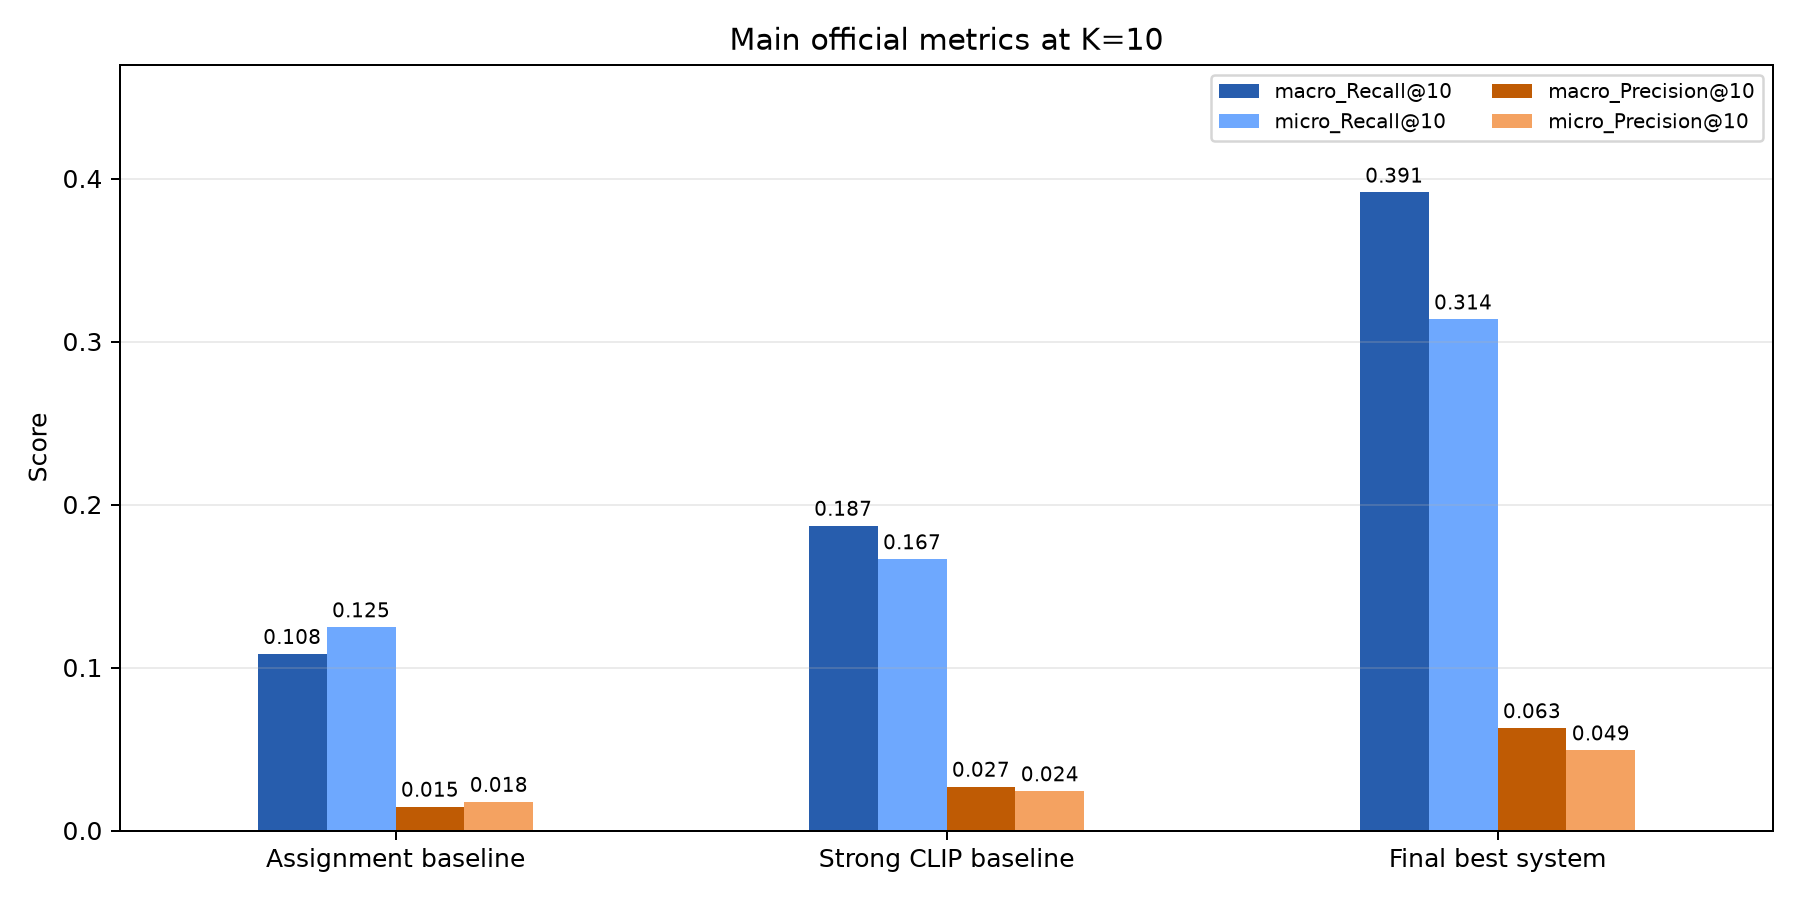

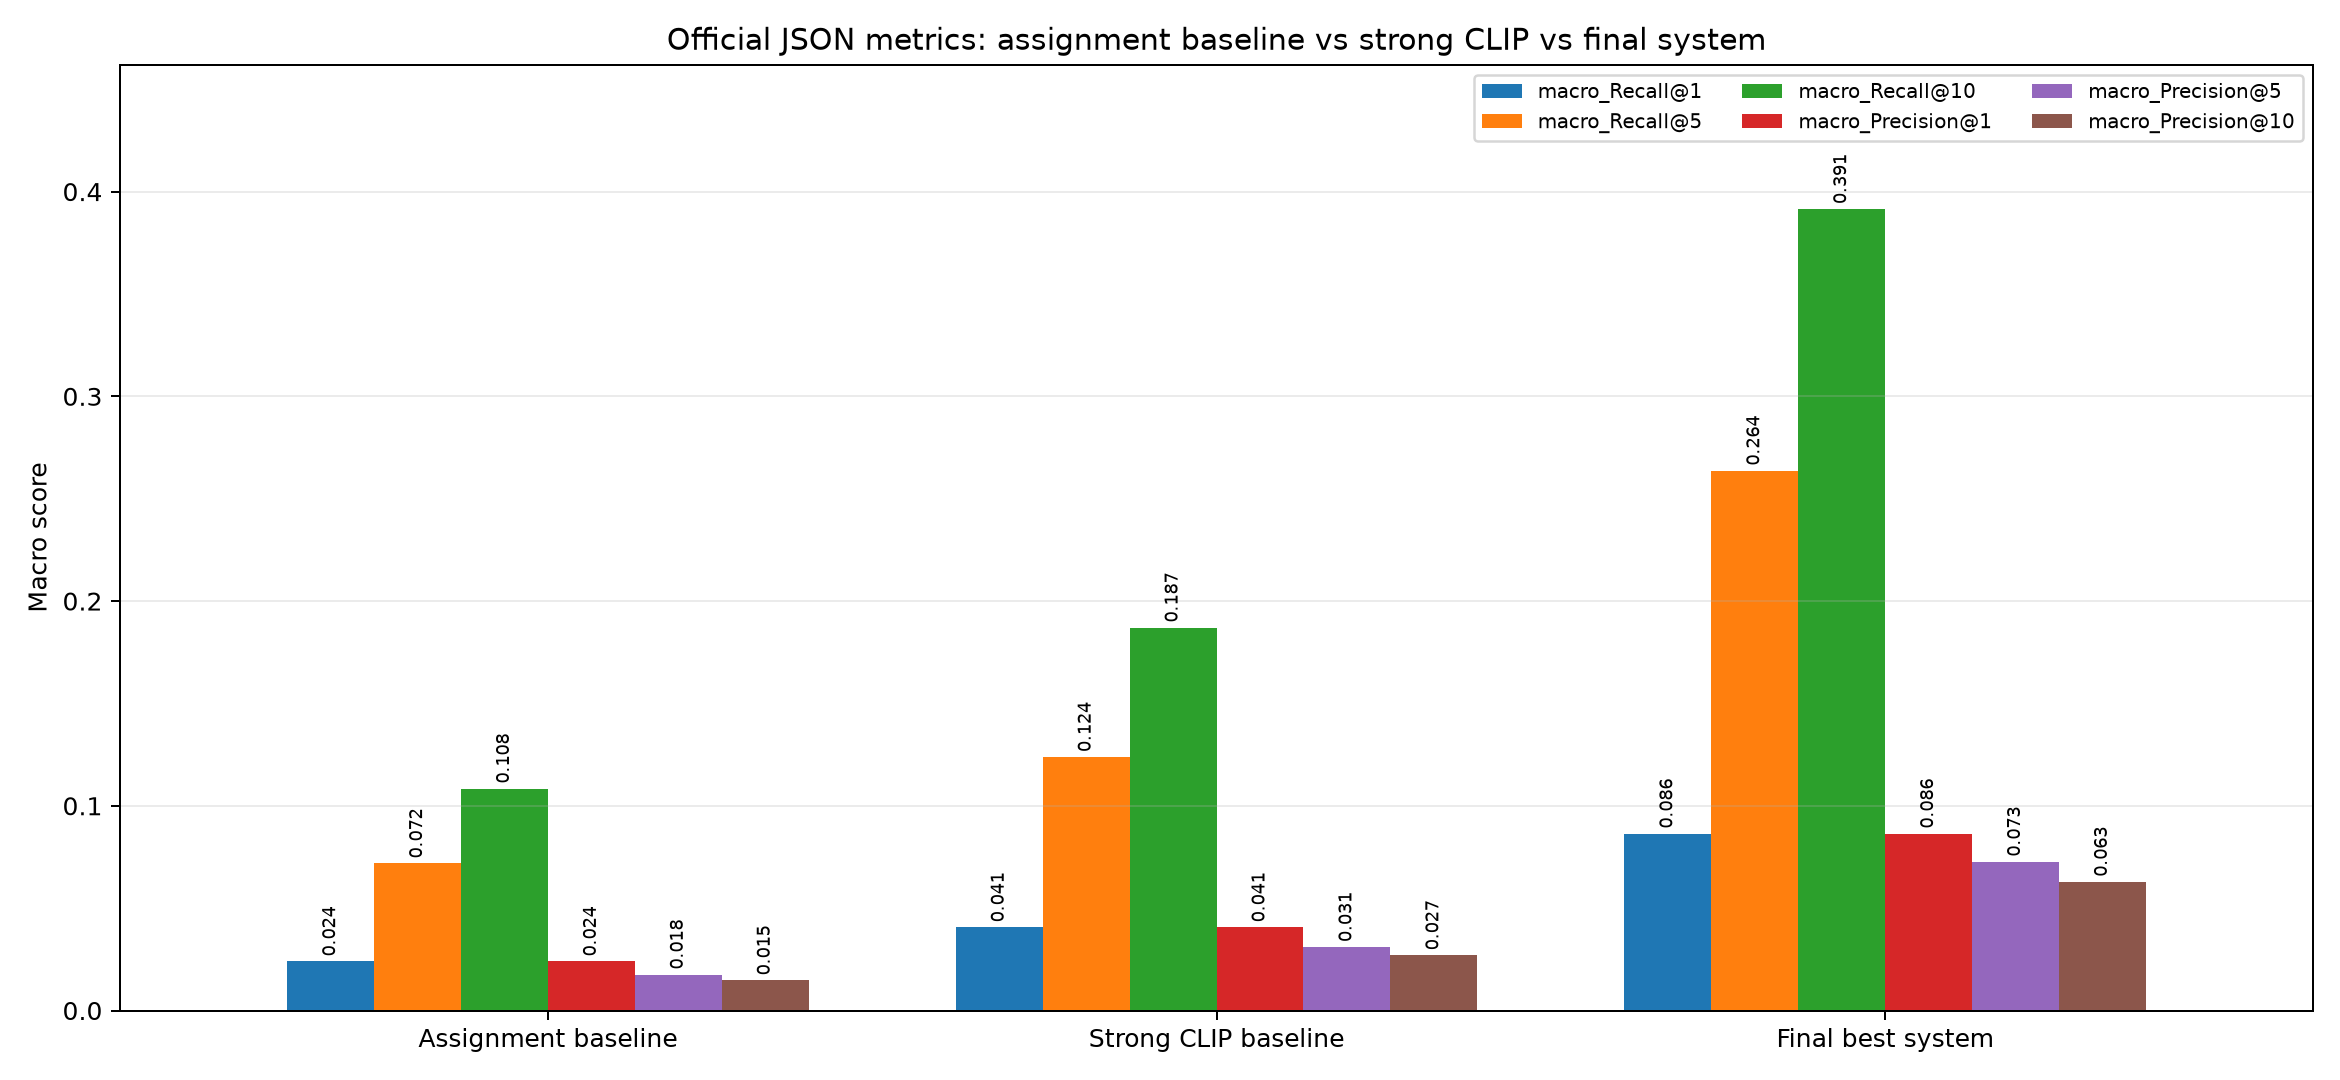

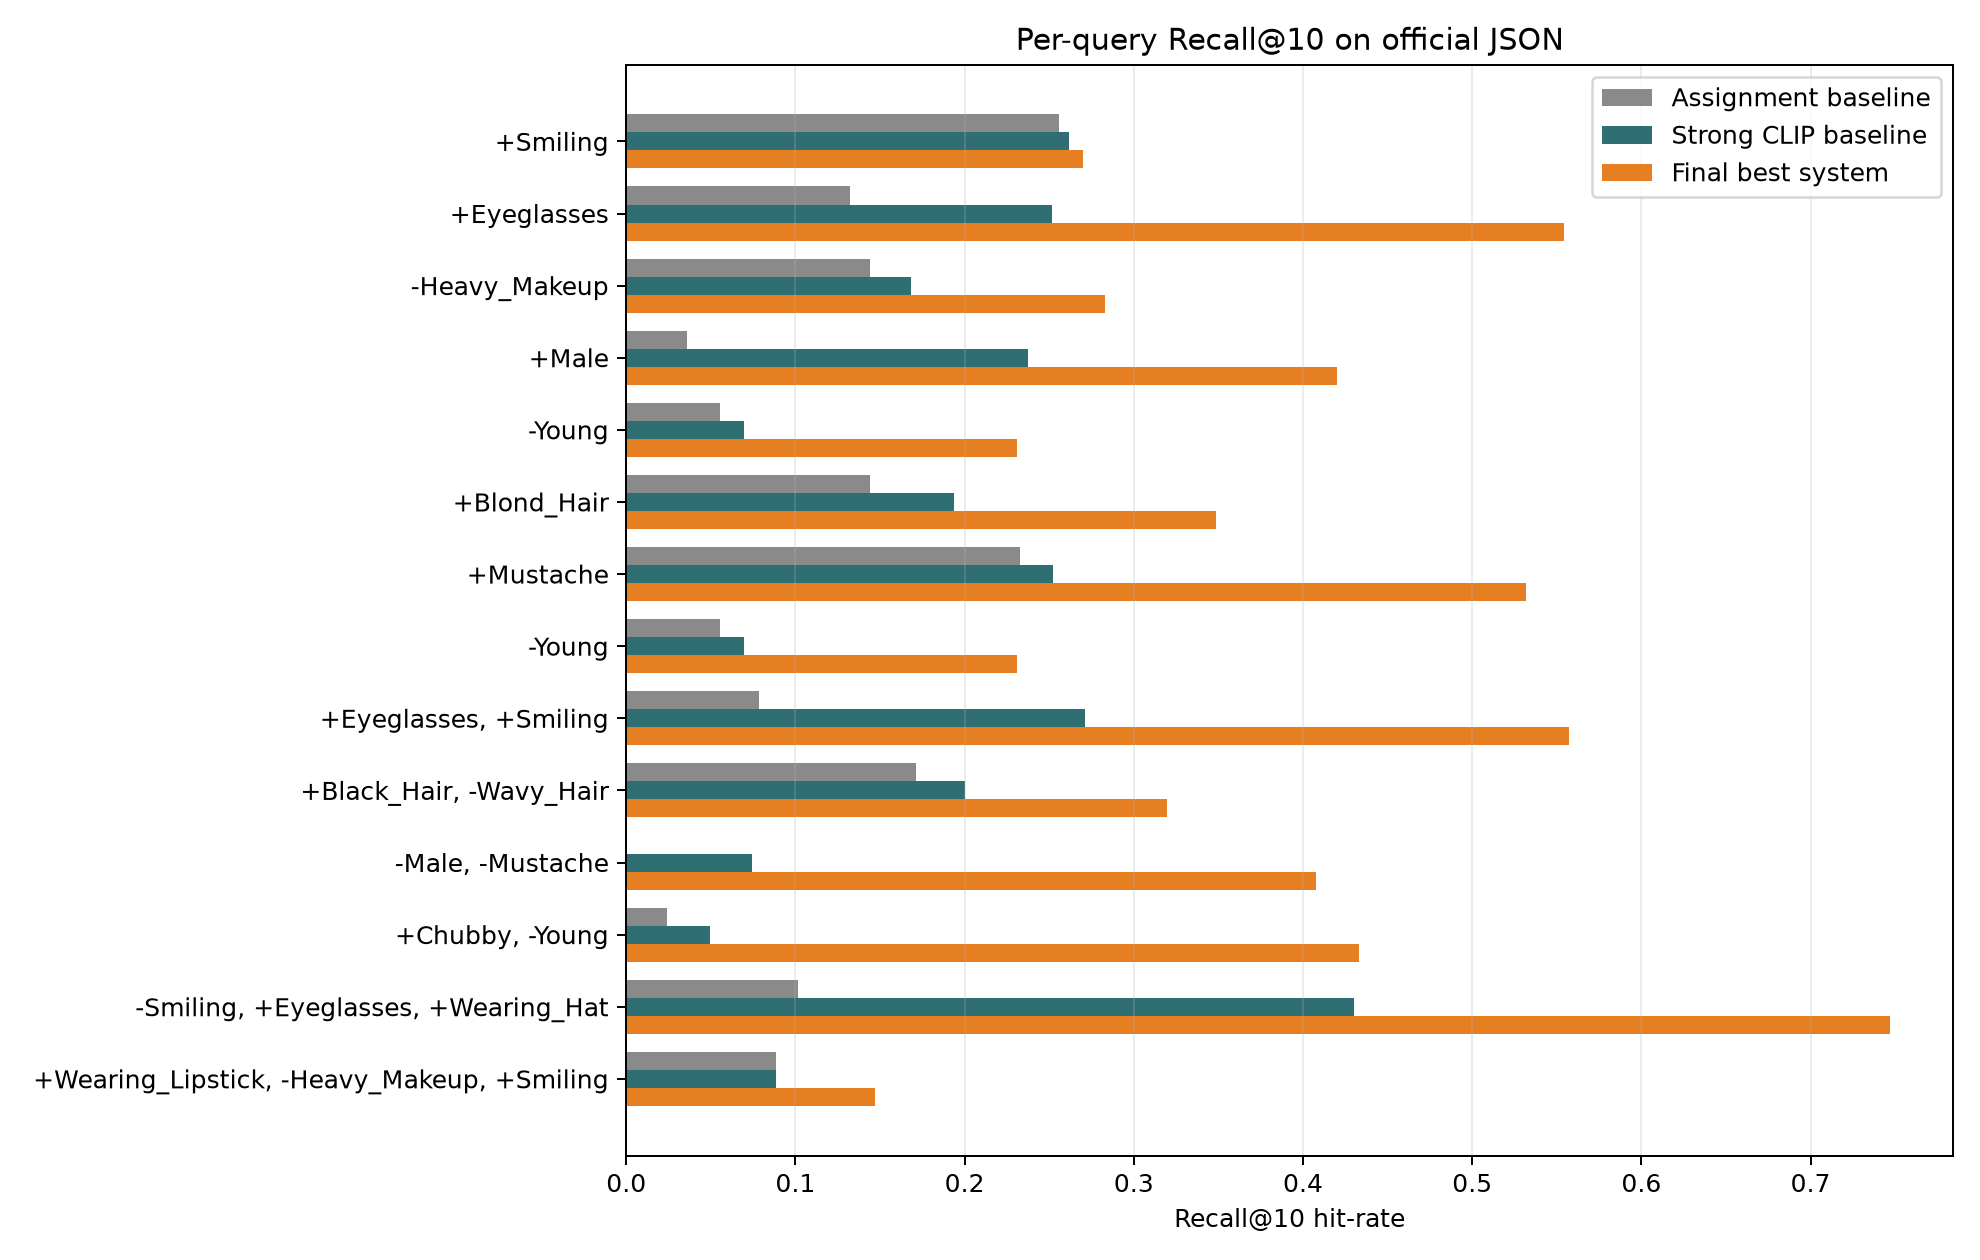

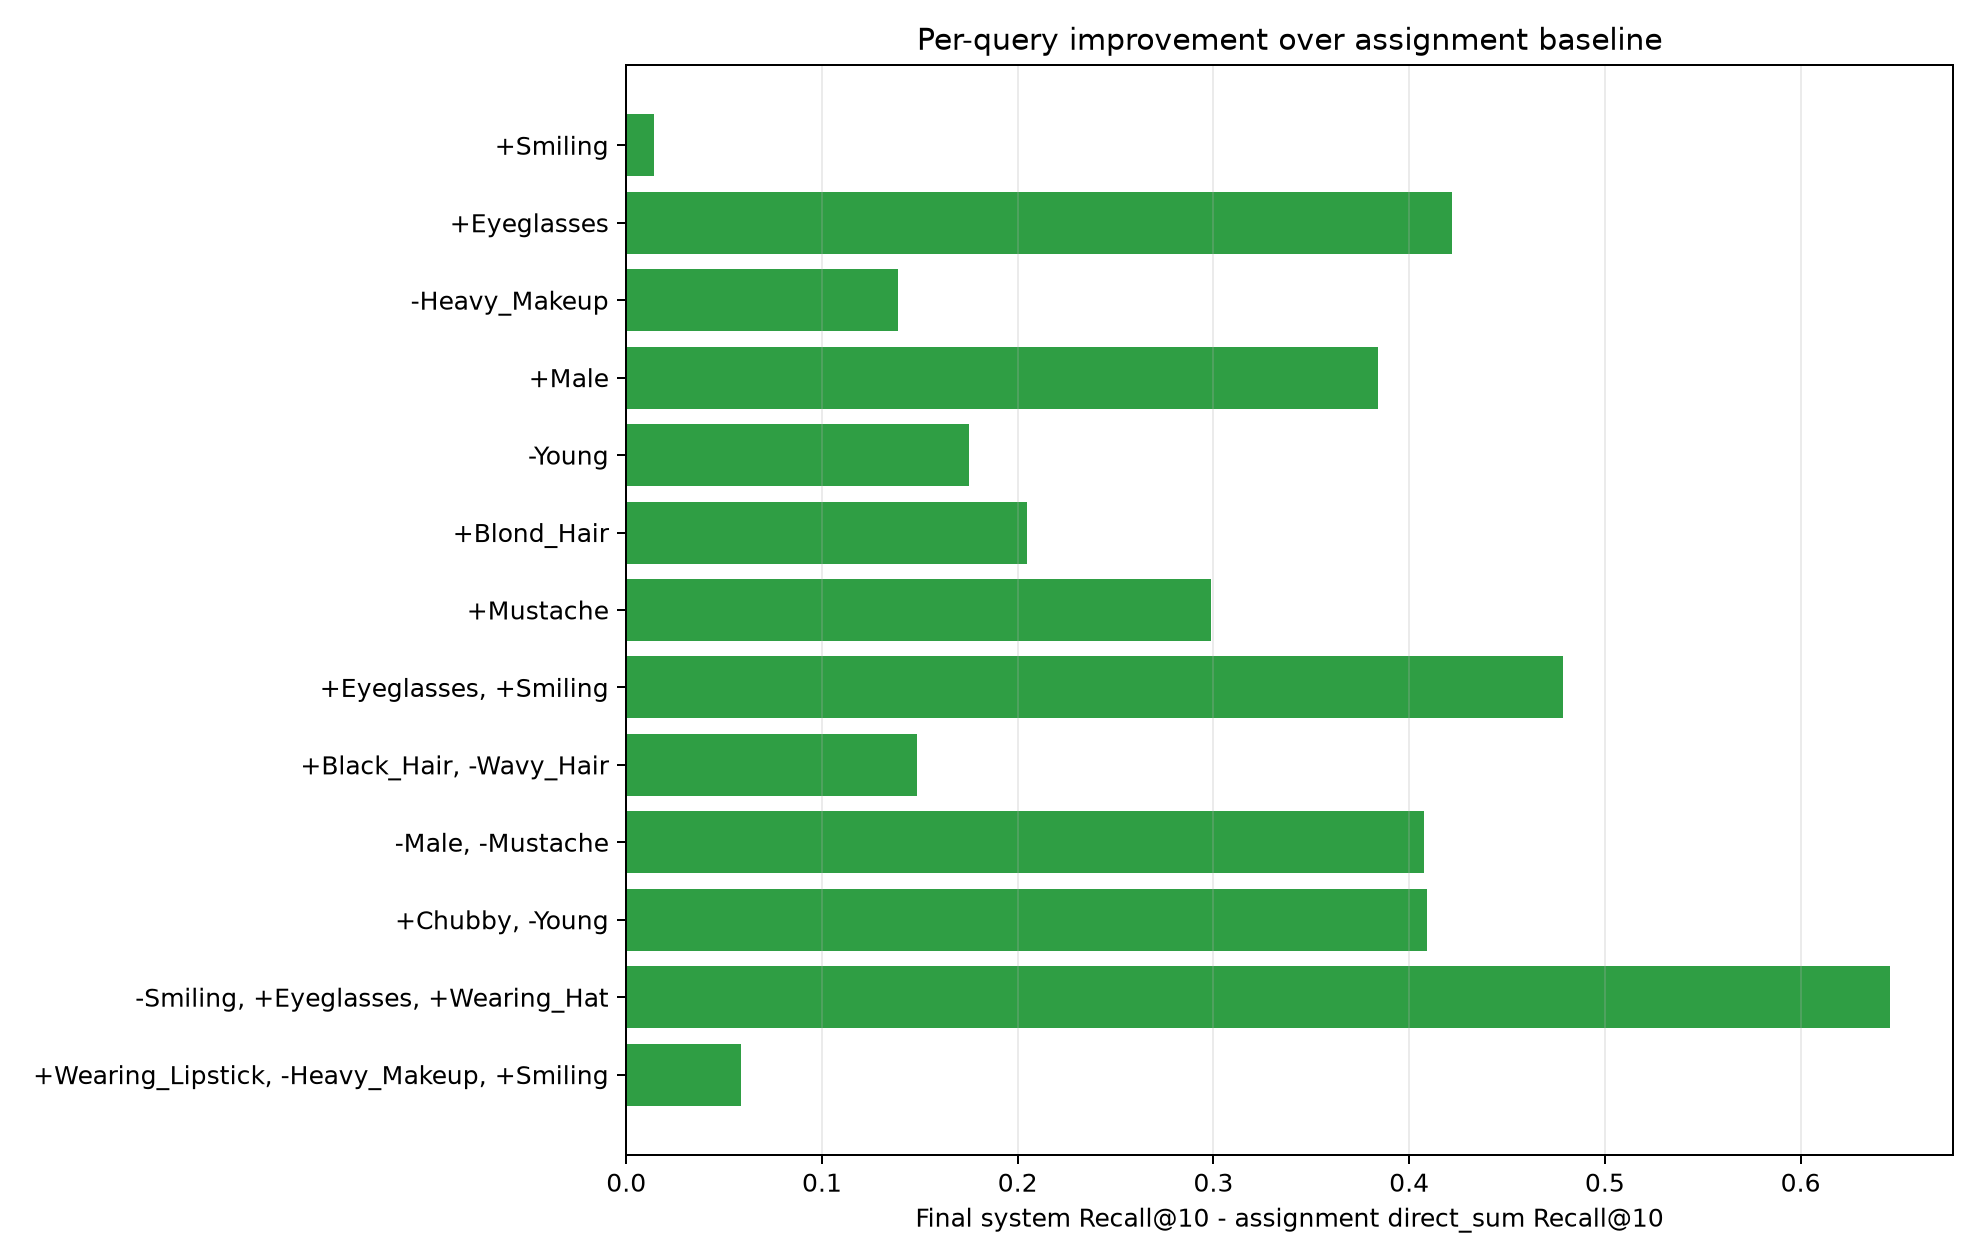

In [11]:
macro_metrics = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "overall_metrics_macro.csv")
micro_metrics = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "overall_metrics_micro.csv")
all_metrics = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "overall_metrics_three_systems.csv")
per_query = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "per_query_recall10_three_systems.csv")

print("Macro metrics: each query counts equally.")
display(macro_metrics)

print("Micro metrics: every source-query case counts equally.")
display(micro_metrics)

for image_name in [
    "overall_metrics_k10_focus.png",
    "overall_metrics_three_systems.png",
    "per_query_recall10_three_systems.png",
    "per_query_recall10_improvement.png",
]:
    image_path = FINAL_DIR / "results" / "clean_report" / image_name
    if image_path.exists():
        display(IPyImage(filename=str(image_path)))

## Qualitative Examples

The qualitative viewer shows:

- blue: source/input image;
- light green: official-valid JSON target;
- yellow: satisfies the requested query attributes, but is not JSON-valid;
- red: fails at least one requested query attribute.

This helps diagnose whether a retrieved image fails because it violates the requested edit or because it does not satisfy the stricter official Hamming/source-preservation rule.

Saved /Users/kuba/deep_learning/final_best_system/results/delivery_notebook_qualitative/query_05_source_3_top10.png


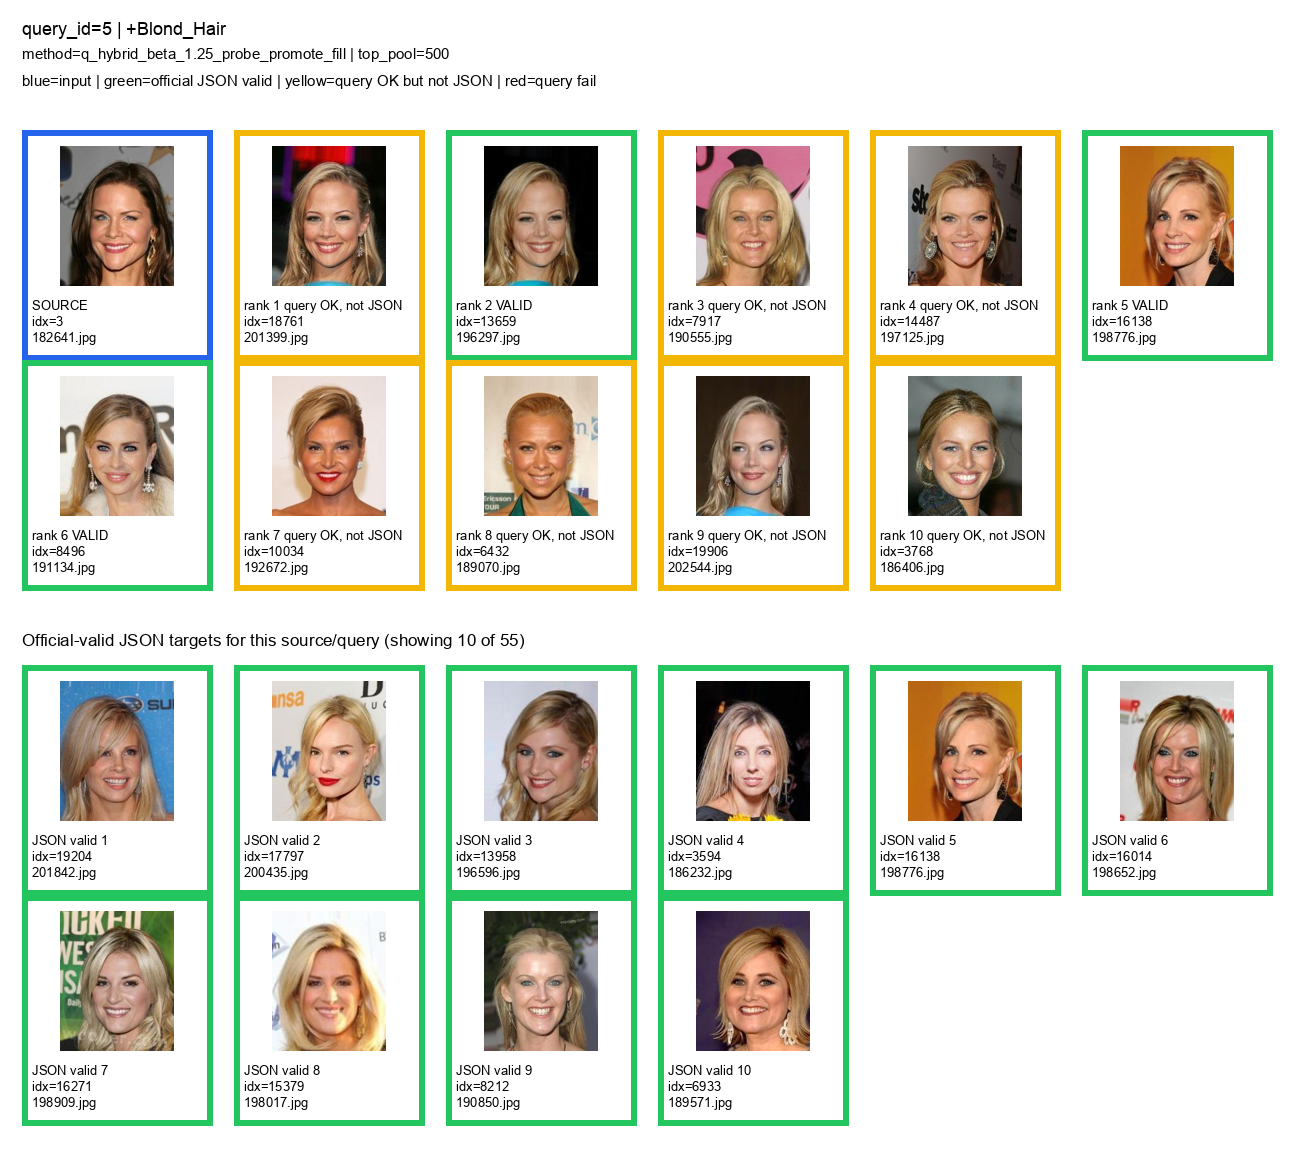

Saved /Users/kuba/deep_learning/final_best_system/results/delivery_notebook_qualitative/query_12_source_37_top10.png


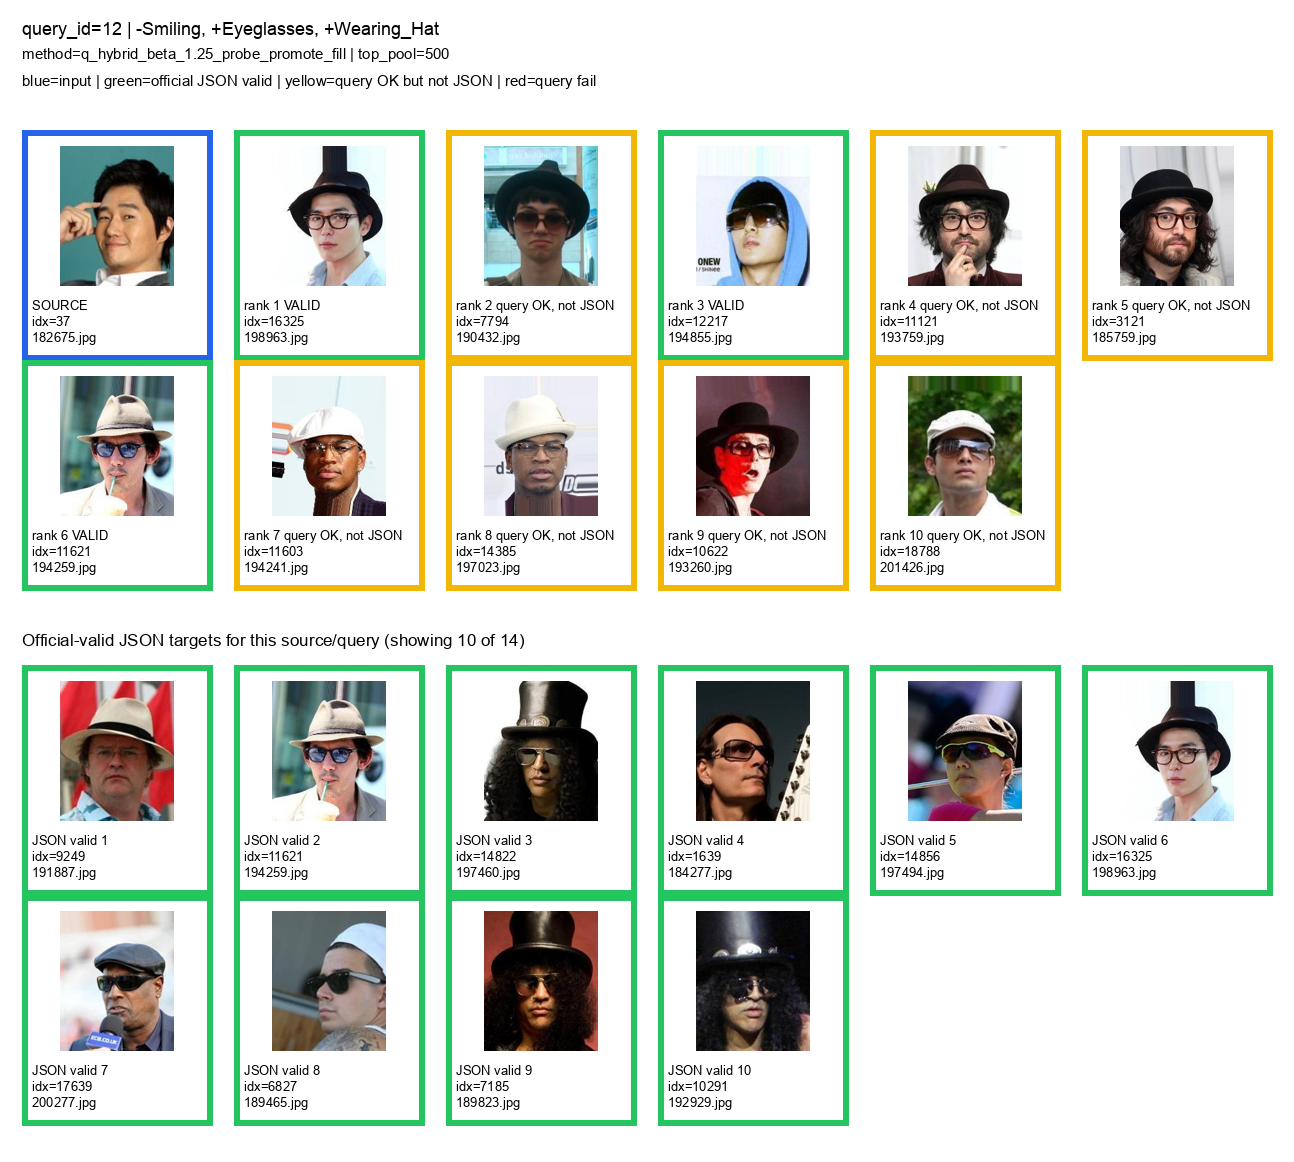

Saved /Users/kuba/deep_learning/final_best_system/results/delivery_notebook_qualitative/query_13_source_3977_top10.png


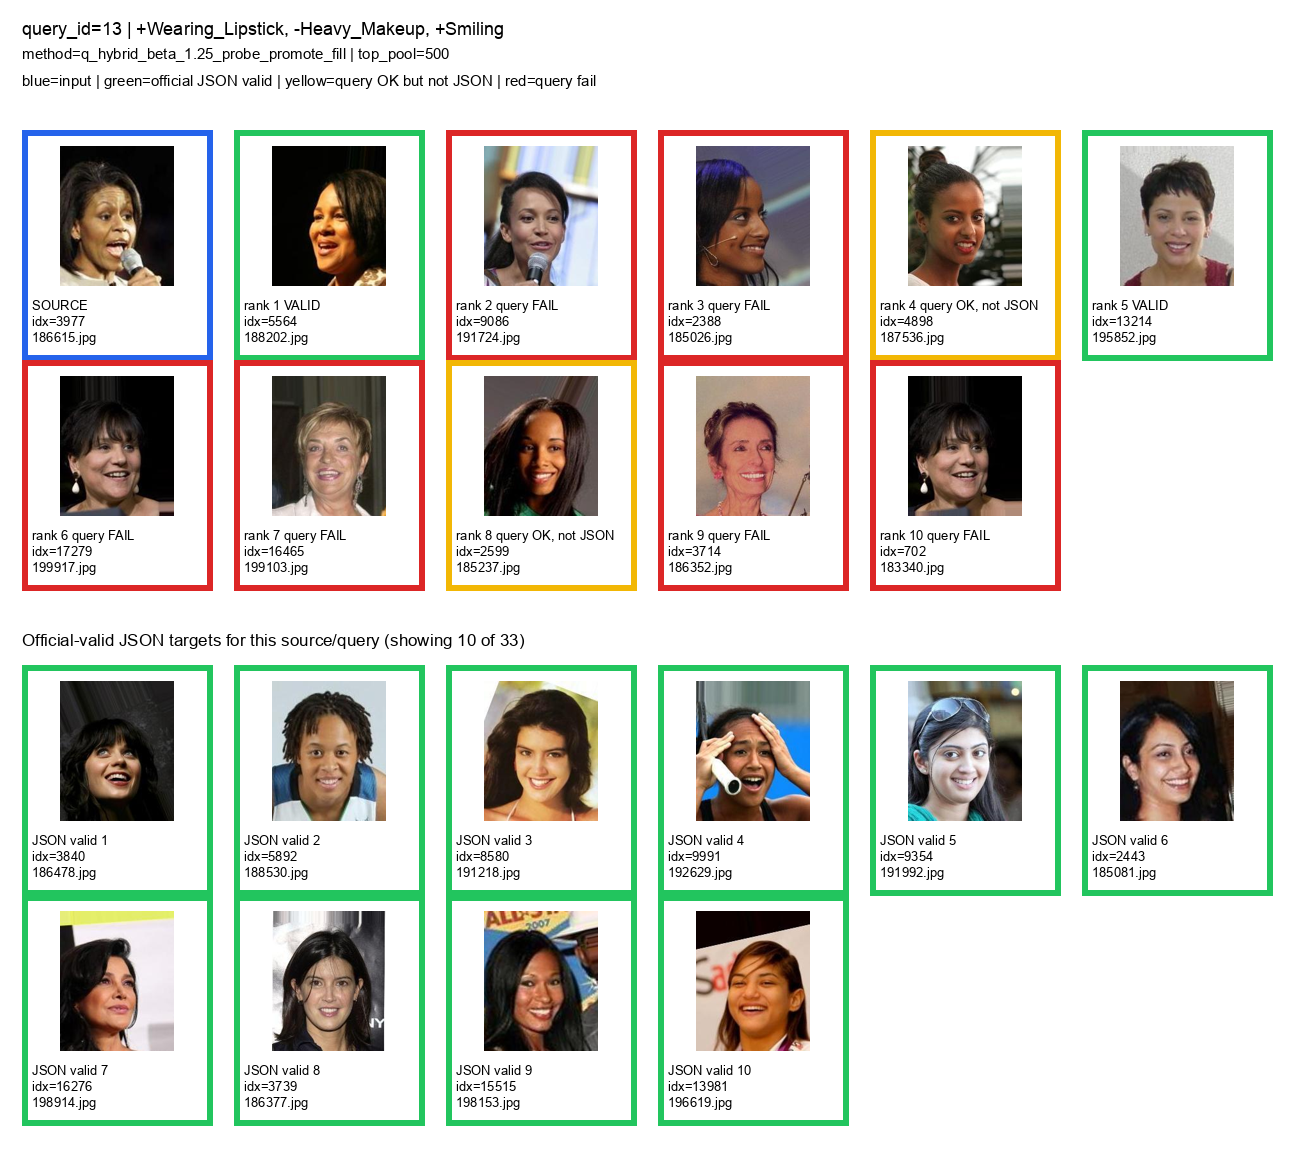

In [12]:
from PIL import Image, ImageDraw, ImageFont


def find_image_root():
    candidates = [
        PROJECT_ROOT / "celeba" / "img_align_celeba",
        FINAL_DIR / "data" / "celeba" / "img_align_celeba",
        PROJECT_ROOT / "data" / "celeba" / "img_align_celeba",
        CLUSTER_ROOT / "data" / "celeba" / "img_align_celeba",
    ]
    for path in candidates:
        if path.is_dir():
            return path
    return None


def draw_retrieval_grid(query_id, source_index, top_k=10, top_pool=500, output_dir=None):
    image_root = find_image_root()
    if image_root is None:
        print("CelebA image folder not found; qualitative grid skipped.")
        return None

    entry = evaluation_json[int(query_id)]
    query_text = entry["query"]
    valid_targets = set(map(int, entry["ground_truth"].get(str(int(source_index)), [])))
    if not valid_targets:
        raise ValueError(f"source_index={source_index} is not valid for query_id={query_id}")

    q_final, details = final_query(gallery[[int(source_index)]], query_text, beta=FINAL_BETA)
    selected = probe_promote_and_fill(source_index, q_final, details["conditions"], top_pool=top_pool, top_k=top_k)

    card_w, card_h = 190, 230
    img_w, img_h = 140, 140
    margin = 22
    title_h = 130
    row_gap = 40
    cols = 6
    pred_count = 1 + top_k
    pred_rows = (pred_count + cols - 1) // cols
    valid_show = list(valid_targets)[:top_k]
    valid_rows = (len(valid_show) + cols - 1) // cols
    width = cols * card_w + (cols + 1) * margin
    height = title_h + pred_rows * card_h + row_gap + 50 + max(1, valid_rows) * card_h + margin
    canvas = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(canvas)

    colors = {
        "source": "#2563eb",       # blue
        "json_valid": "#22c55e",   # light/strong green
        "query_ok": "#f2b705",     # yellow
        "query_fail": "#dc2626",   # red
    }

    def font(size=16):
        try:
            return ImageFont.truetype("Arial.ttf", size)
        except Exception:
            return ImageFont.load_default()

    def add_card(idx, label, position, border_color):
        x, y = position
        draw.rectangle([x, y, x + card_w, y + card_h], outline=border_color, width=6)
        filename = gallery_filenames[int(idx)]
        image_path = image_root / filename
        try:
            im = Image.open(image_path).convert("RGB")
            im.thumbnail((img_w, img_h))
            ix = x + (card_w - im.width) // 2
            iy = y + 16
            canvas.paste(im, (ix, iy))
        except Exception as exc:
            draw.text((x + 10, y + 20), f"missing\n{filename}\n{exc}", fill="black", font=font(12))
        draw.text((x + 10, y + img_h + 28), label, fill="black", font=font(13))

    draw.text((margin, 18), f"query_id={query_id} | {query_text}", fill="black", font=font(18))
    draw.text((margin, 45), f"method=q_hybrid_beta_{FINAL_BETA}_probe_promote_fill | top_pool={top_pool}", fill="black", font=font(15))
    draw.text((margin, 72), "blue=input | green=official JSON valid | yellow=query OK but not JSON | red=query fail", fill="black", font=font(15))

    cards = [(source_index, f"SOURCE\nidx={source_index}\n{gallery_filenames[int(source_index)]}", colors["source"])]
    for rank, idx in enumerate(selected, 1):
        if idx in valid_targets:
            status = "VALID"
            color = colors["json_valid"]
        elif truth_query_ok(idx, details["conditions"]):
            status = "query OK, not JSON"
            color = colors["query_ok"]
        else:
            status = "query FAIL"
            color = colors["query_fail"]
        cards.append((idx, f"rank {rank} {status}\nidx={idx}\n{gallery_filenames[int(idx)]}", color))

    y0 = title_h
    for n, (idx, label, color) in enumerate(cards):
        row, col = divmod(n, cols)
        add_card(idx, label, (margin + col * (card_w + margin), y0 + row * card_h), color)

    valid_y = y0 + pred_rows * card_h + row_gap
    draw.text((margin, valid_y), f"Official-valid JSON targets for this source/query (showing {len(valid_show)} of {len(valid_targets)})", fill="black", font=font(17))
    valid_y += 35
    for n, idx in enumerate(valid_show):
        row, col = divmod(n, cols)
        add_card(idx, f"JSON valid {n+1}\nidx={idx}\n{gallery_filenames[int(idx)]}", (margin + col * (card_w + margin), valid_y + row * card_h), colors["json_valid"])

    output_dir = Path(output_dir or (FINAL_DIR / "results" / "delivery_notebook_qualitative"))
    output_dir.mkdir(parents=True, exist_ok=True)
    out = output_dir / f"query_{int(query_id):02d}_source_{int(source_index)}_top{top_k}.png"
    canvas.save(out)
    return out

if RUN_QUALITATIVE_EXAMPLES:
    qualitative_examples = [
        (5, 3),      # +Blond_Hair
        (12, 37),    # -Smiling, +Eyeglasses, +Wearing_Hat
        (13, 3977),  # +Wearing_Lipstick, -Heavy_Makeup, +Smiling
    ]
    for query_id, source_index in qualitative_examples:
        path = draw_retrieval_grid(query_id, source_index, top_k=10, top_pool=500)
        if path:
            print("Saved", path)
            display(IPyImage(filename=str(path)))
else:
    print("Qualitative examples skipped.")


## Reproducibility Training Code, Disabled by Default

The previous section reports the actual cluster training outputs. This section keeps the runnable training entry points for reproducibility. It is disabled by default because full runs take cluster/GPU time and should not be executed accidentally while reviewing the notebook.

For a quick smoke, set `RUN_SHORT_TRAINING_SMOKE=True` and keep `TRAINING_PROFILE="short"`. For the real experiment we used the long cluster jobs documented in the report text and logs.


In [13]:
# Toggle RUN_SHORT_TRAINING_SMOKE=True at the top of the notebook to run a small reproducibility smoke.
# Full training was performed on the Baldo cluster. The commands below mirror the final families:
# gate v7 hamming-weighted training, followed by the v4 embedding-probe architecture sweep.

TRAINING_PROFILE = "short"  # keep "short" in notebooks; use "long" only on the cluster
TRAIN_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if RUN_SHORT_TRAINING_SMOKE:
    if not CLUSTER_ROOT.exists():
        raise RuntimeError("cluster/ scripts are required for training reproduction, but cluster/ was not found.")

    training_env = dict(os.environ)
    training_env["DL_PROJECT_ROOT"] = str(CLUSTER_ROOT)

    commands = [
        [
            sys.executable,
            str(CLUSTER_ROOT / "experimental" / "run_official_mix_hpsearch_v7_weighted.py"),
            "--profile", TRAINING_PROFILE,
            "--configs", str(CLUSTER_ROOT / "configs" / "gate_v7_hamming_weighted_3h_configs.json"),
            "--device", TRAIN_DEVICE,
            "--limit", "1" if TRAINING_PROFILE == "short" else "0",
            "--beta-eval-time-budget-seconds", "120" if TRAINING_PROFILE == "short" else "0",
        ],
        [
            sys.executable,
            str(CLUSTER_ROOT / "experimental" / "probe_arch_sweep_v4_finetune.py"),
            "--profile", TRAINING_PROFILE,
            "--device", TRAIN_DEVICE,
            "--limit", "1" if TRAINING_PROFILE == "short" else "0",
            "--query-ids", "0",
            "--max-sources-per-query", "8",
            "--top-pool", "50",
        ],
    ]
    for command in commands:
        print("Running:", " ".join(map(str, command)))
        subprocess.run(command, check=True, cwd=CLUSTER_ROOT, env=training_env)
else:
    print("Training smoke skipped. Set RUN_SHORT_TRAINING_SMOKE=True for a short smoke; use the cluster for full runs.")



Training smoke skipped. Set RUN_SHORT_TRAINING_SMOKE=True for a short smoke; use the cluster for full runs.


## Full Official Evaluation Code, Disabled by Default

The final official evaluation is already saved. This cell shows how it can be recomputed with the final checkpoint and beta value.

In [14]:
if RUN_FULL_JSON_EVALUATION:
    eval_device = "cuda" if torch.cuda.is_available() else "cpu"
    output_root = FINAL_DIR / "results" / "notebook_recomputed_beta_eval"
    subprocess.run(
        [
            sys.executable,
            str(FINAL_CODE / "orchestrator" / "evaluate_beta_sweep_blends.py"),
            "--checkpoint", str(FINAL_CHECKPOINT_PATH),
            "--output-root", str(output_root),
            "--betas", str(FINAL_BETA),
            "--device", eval_device,
            "--force",
        ],
        check=True,
        cwd=FINAL_CODE,
    )
    print("Saved recomputed evaluation to", output_root)
else:
    print("Full JSON evaluation skipped. Set RUN_FULL_JSON_EVALUATION=True to recompute it.")

Full JSON evaluation skipped. Set RUN_FULL_JSON_EVALUATION=True to recompute it.


## Top-Pool Diagnostic: Does the System Reach the Right Region?

This diagnostic asks a different question from the final fair evaluation. Instead of asking only whether the first ten retrieved images are official-valid, we ask whether the broad candidate pool produced by `q_final` already contains official-valid targets.

The procedure is:

1. compute the real final query vector `q_final` with the learned gate plus arithmetic correction;
2. retrieve a broad pool, e.g. top-500, top-200, or top-100 by cosine similarity;
3. compare two filtering families inside that pool:
   - **oracle filters**, which use the true CelebA attributes and are therefore diagnostic upper bounds, not deployable inference;
   - **learned-probe filters**, which use the trained attribute probe and are realistic but noisy.

If oracle filtering works very well inside top-500, it means the retrieval vector lands in the right semantic neighbourhood. The remaining issue is then candidate selection/reranking, not only vector composition.


Diagnostic figure: broad-pool retrieval vs final top-10 selection


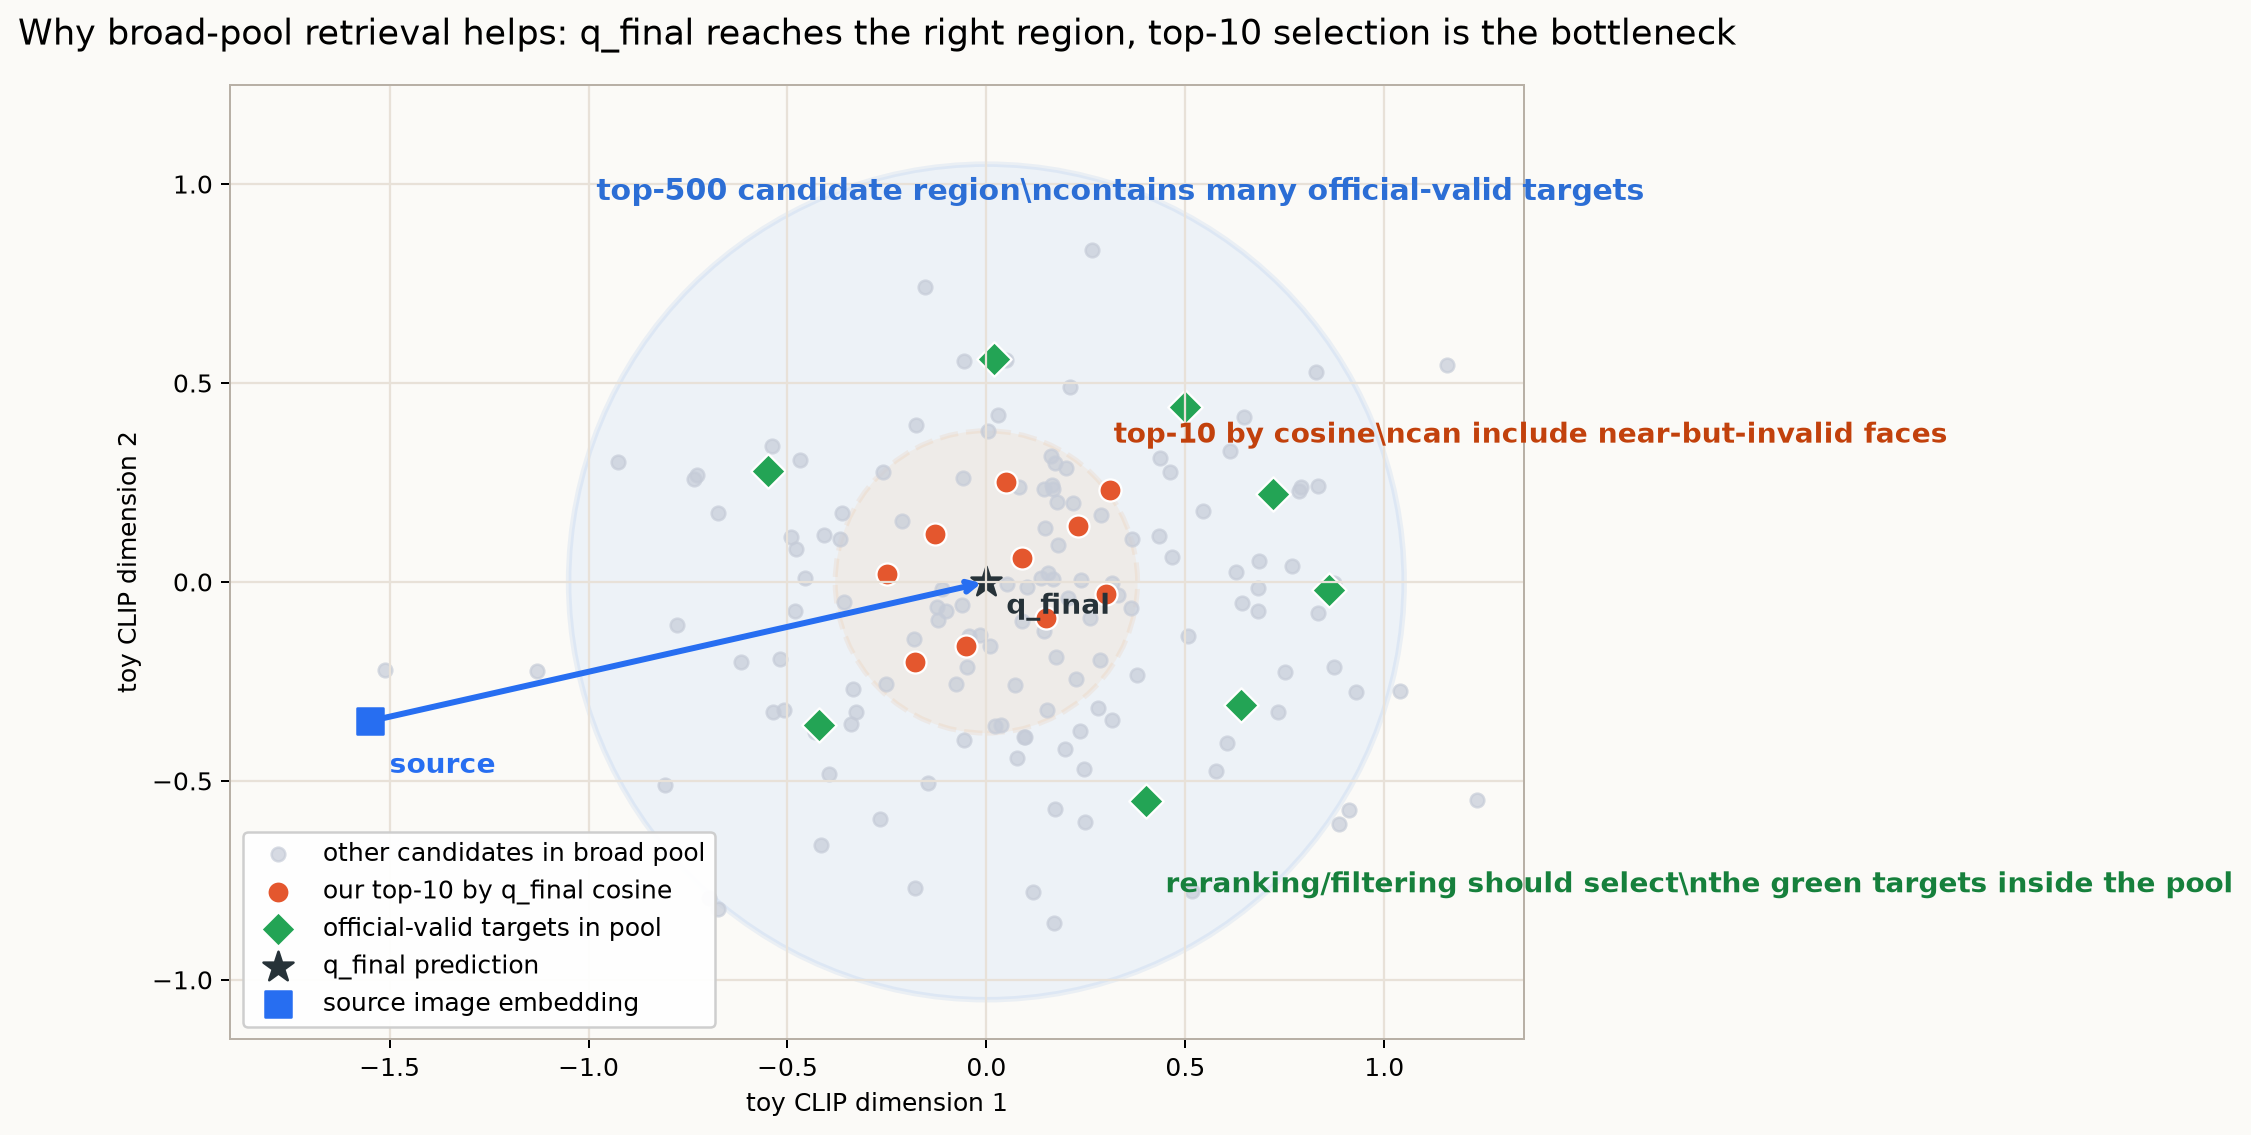

Full JSON diagnostic results. Oracle rows are upper bounds; probe rows are realistic learned filters.


,top_pool,method,Recall@1,Recall@5,Recall@10,Precision@1,Precision@5,Precision@10,avg_kept
0,100,oracle: Hamming only,0.472740,0.733239,0.772934,0.472740,0.347144,0.244799,6.534642
1,100,oracle: query + Hamming,0.782434,0.782434,0.782434,0.782434,0.453364,0.277387,3.032797
2,100,oracle: query only,0.102808,0.297773,0.424029,0.102808,0.083414,0.073275,65.452348
3,100,probe: Hamming only,0.079148,0.237505,0.335018,0.079148,0.064329,0.055528,21.210184
4,100,probe: query + Hamming + fill,0.094336,0.284037,0.398856,0.094336,0.079463,0.069309,11.444814
5,100,probe: query + Hamming strict,0.090282,0.251906,0.323399,0.090282,0.071088,0.057086,11.444814
6,100,probe: query only,0.075790,0.233813,0.344578,0.075790,0.062998,0.056121,69.113911
7,100,"q_final top-10, no filtering",0.070586,0.219866,0.328392,0.070586,0.058314,0.052088,10.000000
8,200,oracle: Hamming only,0.500696,0.812326,0.869115,0.500696,0.415067,0.323239,10.877194
9,200,oracle: query + Hamming,0.886270,0.886270,0.886270,0.886270,0.604611,0.403325,4.930171


In [15]:
filtering_summary_path = FINAL_DIR / "results" / "filtering_matrix" / "real_system_rerun_20260629_114221" / "summary.csv"
filtering_figure_path = FINAL_DIR / "explanations" / "top_pool_retrieval_diagnostic.png"

if RUN_FILTERING_MATRIX_RECOMPUTE:
    output_root = FINAL_DIR / "results" / "filtering_matrix" / "notebook_rerun"
    subprocess.run(
        [
            sys.executable,
            str(FINAL_DIR / "code" / "evaluate_filtering_matrix.py"),
            "--device", DEVICE_REQUEST,
            "--top-pools", "500", "200", "100",
            "--source-batch-size", "256",
            "--output-root", str(output_root),
        ],
        check=True,
        cwd=PROJECT_ROOT,
    )
    filtering_summary_path = output_root / "summary.csv"

if not filtering_figure_path.exists():
    subprocess.run(
        [sys.executable, str(FINAL_DIR / "code" / "make_top_pool_explanation_figure.py")],
        check=True,
        cwd=PROJECT_ROOT,
    )

filtering_summary = pd.read_csv(filtering_summary_path)
selected_methods = [
    "best_no_filter",
    "oracle_query_only",
    "oracle_hamming_only",
    "oracle_query_and_hamming",
    "probe_query_only",
    "probe_hamming_only",
    "probe_query_and_hamming",
    "probe_query_and_hamming_fill",
]
method_labels = {
    "best_no_filter": "q_final top-10, no filtering",
    "oracle_query_only": "oracle: query only",
    "oracle_hamming_only": "oracle: Hamming only",
    "oracle_query_and_hamming": "oracle: query + Hamming",
    "probe_query_only": "probe: query only",
    "probe_hamming_only": "probe: Hamming only",
    "probe_query_and_hamming": "probe: query + Hamming strict",
    "probe_query_and_hamming_fill": "probe: query + Hamming + fill",
}
show_cols = ["top_pool", "method", "Recall@1", "Recall@5", "Recall@10", "Precision@1", "Precision@5", "Precision@10", "avg_kept"]
filtering_view = filtering_summary[filtering_summary["method"].isin(selected_methods)][show_cols].copy()
filtering_view["method"] = filtering_view["method"].map(method_labels)
filtering_view = filtering_view.sort_values(["top_pool", "method"]).reset_index(drop=True)

print("Diagnostic figure: broad-pool retrieval vs final top-10 selection")
display(IPyImage(filename=str(filtering_figure_path)))

print("Full JSON diagnostic results. Oracle rows are upper bounds; probe rows are realistic learned filters.")
display(filtering_view)


## Interpretation of the Top-Pool Diagnostic

The top-pool diagnostic supports the following reading: the learned hybrid composition usually moves the query into a useful part of the CLIP space, but cosine ranking alone does not reliably order all official-valid targets into the first ten positions.

For example, with a top-500 pool, oracle query+Hamming filtering reaches very high Recall@10. This means that, if candidate validity were known perfectly, many correct answers could be recovered from the region already reached by `q_final`. The learned probe is much weaker than the oracle, so the practical bottleneck becomes robust attribute/source-preservation estimation inside the candidate pool.

This is why the final system uses a conservative learned-probe promote-and-fill strategy: it promotes candidates that look valid, but fills the remaining positions with the original `q_final` ranking to avoid over-pruning when the probe is wrong.


## Findings

The final system improves substantially over both the assignment baseline and the strongest zero-shot CLIP arithmetic baseline. We separate three levels of the system:

1. **Hybrid compositionality core:** learned sequential gate plus CLIP arithmetic correction. This is the part that directly addresses hybrid compositionality: it composes the source image with multiple signed query directions.
2. **Full retrieval system:** hybrid compositionality core plus a calibrated attribute probe that reranks/promotes candidates inside a broad top-500 pool.
3. **Probe refinement:** later probe sweeps showed that an embedding MLP probe (`v4_m04_deep_asl_lr2e4_d00`) is the strongest current reranker. A from-scratch CNN/CLIP-fusion probe came very close, but did not beat the embedding probe on Macro Recall@10.

Best saved official full-run values found so far:

```text
Hybrid core only Macro Recall@10:       0.39698
Previous packaged probe Macro R@10:     0.47297
Best v4 embedding-probe Macro R@10:     0.478655
Best v4 embedding-probe Macro P@10:     0.086415
```

The remaining weakness is Precision@10: the model often reaches a useful region and retrieves at least one valid target, but it does not always fill all ten slots with official-valid targets. The top-pool diagnostic shows that many valid targets are already inside a broad candidate pool; therefore future work should focus on a stronger fair reranker or attribute/source-preservation estimator rather than only changing the query vector.




## Qualitative caveat: official labels vs perceptual preservation

The official evaluation is the metric we optimize/report, but it is useful to inspect qualitative cases. The JSON target set is discrete and based on CelebA attribute constraints, so a visually plausible retrieval can be counted as invalid if it fails one binary annotation or if it is not in the official target list. Conversely, official-valid examples can sometimes preserve the requested attribute while changing non-requested visual details such as hair color, lipstick, or makeup.

These examples are not used to replace the official numbers; they are a sanity check explaining why our system can look perceptually strong even when Precision@10 remains low.

**Reproducible commands:**

```bash
.venv/bin/python final_best_system/code/show_json_retrieval_example.py --query-id 5 --source-index 3 --top-k 10
.venv/bin/python final_best_system/code/show_json_retrieval_example.py --query-id 4 --source-index 3 --top-k 10
```

The current default visualizes the final probe-reranked system. To reproduce the older hybrid-core screenshots exactly, pass `--method-dir final_best_system/results/final_best_model_plus_generic_delta_beta_1p50`.

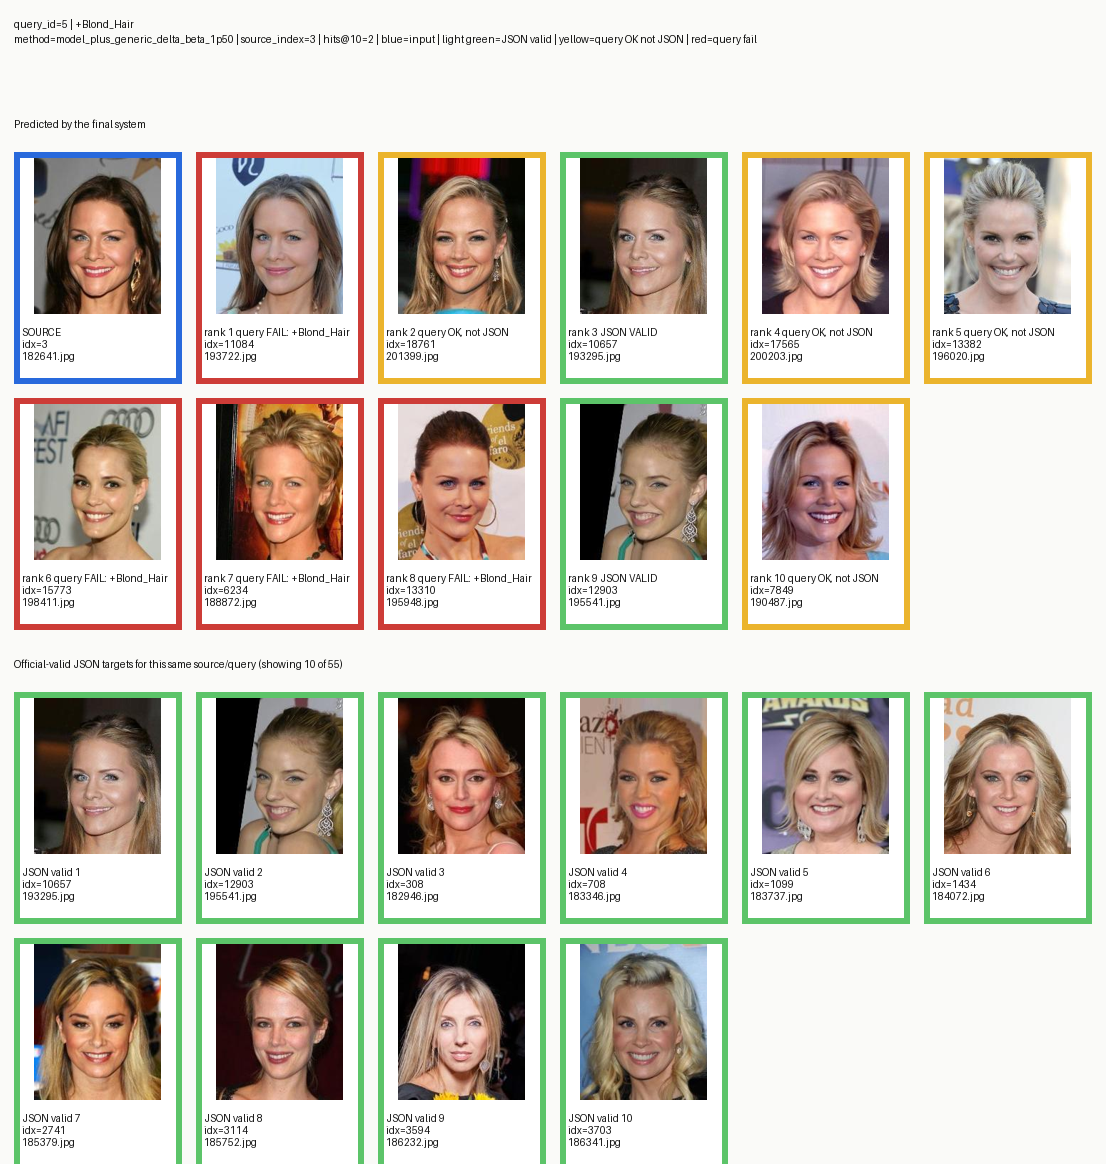

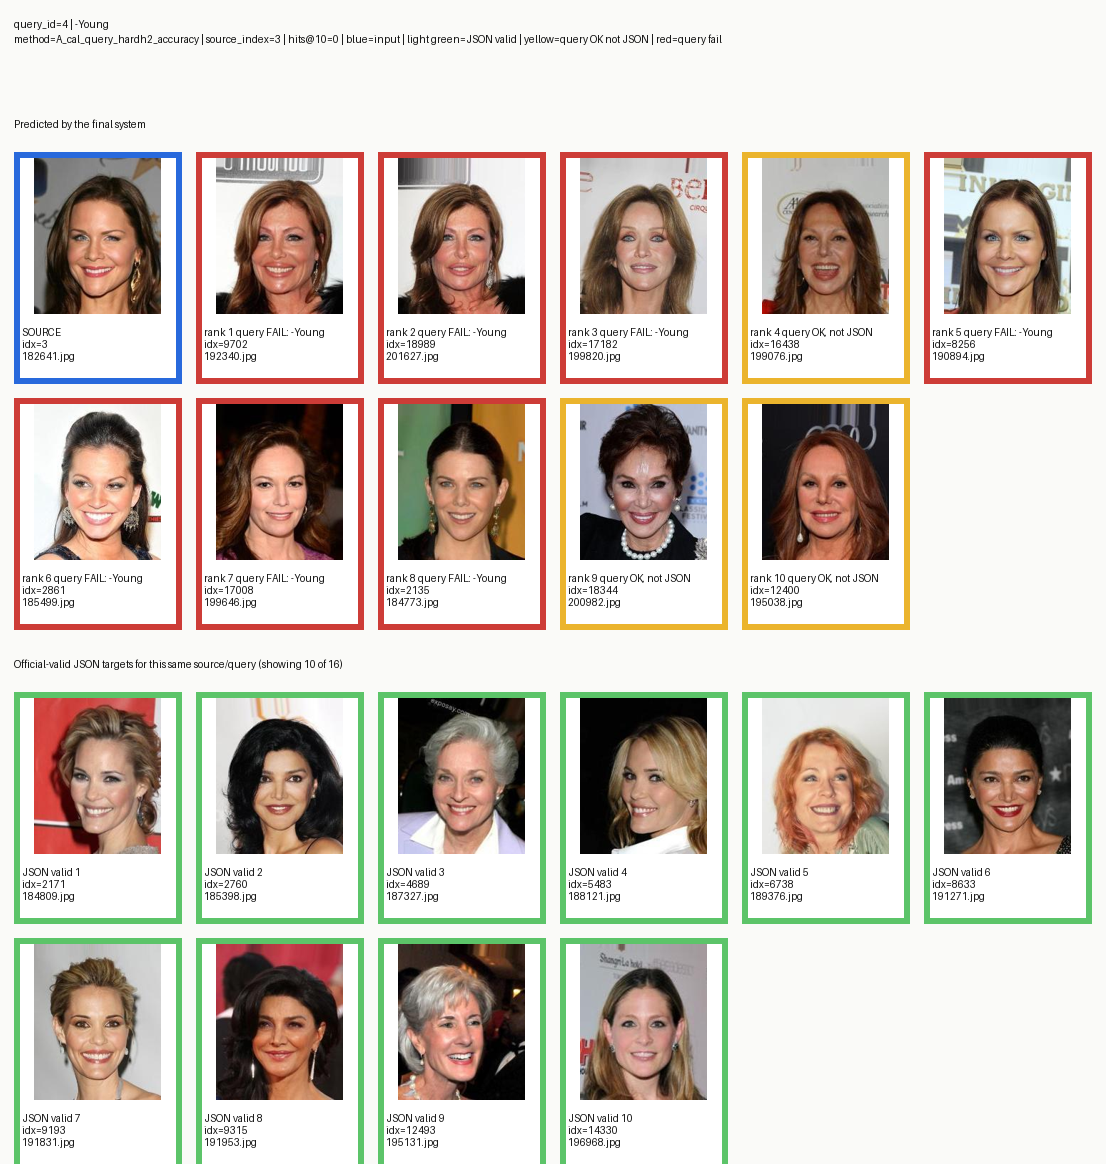


In [16]:
# List valid source indices for each official JSON query.
# This avoids errors such as source_index=3 not found for query_id=10.
import json
from pathlib import Path

evaluation_path = FINAL_DIR / "data" / "celeba_evaluation.json"
if not evaluation_path.exists():
    fallback_paths = [
        PROJECT_ROOT / "celeba_evaluation.json",
        PROJECT_ROOT / "cluster" / "data" / "celeba_evaluation.json",
    ]
    evaluation_path = next((path for path in fallback_paths if path.exists()), evaluation_path)

evaluation = json.loads(evaluation_path.read_text())
for query_id, entry in enumerate(evaluation):
    sources = sorted(map(int, entry["ground_truth"].keys()))
    preview = ", ".join(map(str, sources[:12]))
    print(f"query_id={query_id:02d} | {entry['query']:<45} | sources={len(sources):5d} | examples: {preview}")



query_id=00 | +Smiling                                      | sources= 4786 | examples: 13, 14, 15, 20, 23, 27, 28, 31, 36, 47, 52, 54
query_id=01 | +Eyeglasses                                   | sources= 2196 | examples: 7, 15, 20, 23, 27, 31, 37, 47, 60, 65, 95, 97
query_id=02 | -Heavy_Makeup                                 | sources= 4087 | examples: 2, 8, 13, 22, 25, 29, 32, 40, 45, 50, 52, 54
query_id=03 | +Male                                         | sources= 1595 | examples: 4, 7, 20, 33, 40, 42, 53, 60, 62, 64, 87, 102
query_id=04 | -Young                                        | sources= 5355 | examples: 2, 3, 7, 10, 13, 15, 20, 22, 23, 25, 29, 35
query_id=05 | +Blond_Hair                                   | sources= 5469 | examples: 2, 3, 7, 13, 20, 21, 22, 25, 29, 40, 47, 50
query_id=06 | +Mustache                                     | sources=  301 | examples: 23, 399, 534, 546, 561, 576, 610, 620, 691, 714, 815, 900
query_id=07 | -Young                                  

## Open-vocabulary and multi-attribute qualitative tests

The official evaluation only covers the 40 CelebA attributes, but our final system operates in CLIP embedding space. This means we can also run qualitative open-vocabulary tests with concepts that were never part of the supervised CelebA label set. These examples are **not** official metrics, because no ground-truth labels exist for them; they are visual sanity checks for semantic compositionality.

For an open attribute such as `Sunglasses` or `visible teeth`, the edit direction is computed from CLIP text embeddings:

```text
d = normalize(CLIP_text("a portrait photo of a face with <attribute>")
              - CLIP_text("a portrait photo of a face without <attribute>"))
```

The same learned sequential gate and vector-delta correction then operate on these directions together with known CelebA directions. Yellow borders mean that the known CelebA part of the query is satisfied, while the open-vocabulary part is visually inspected but not label-verifiable.

### Single-attribute sanity check: eyeglasses vs sunglasses

We keep one simple single-attribute example to introduce the idea. With the same source image, `+Eyeglasses` retrieves regular/prescription glasses, while `+Sunglasses` retrieves darker/tinted sunglasses. This suggests that the CLIP-space edit direction distinguishes related but different concepts.

<table>
<tr>
<td><strong>Known CelebA: +Eyeglasses</strong></td>
<td><strong>Open CLIP: +Sunglasses</strong></td>
</tr>
<tr>
<td>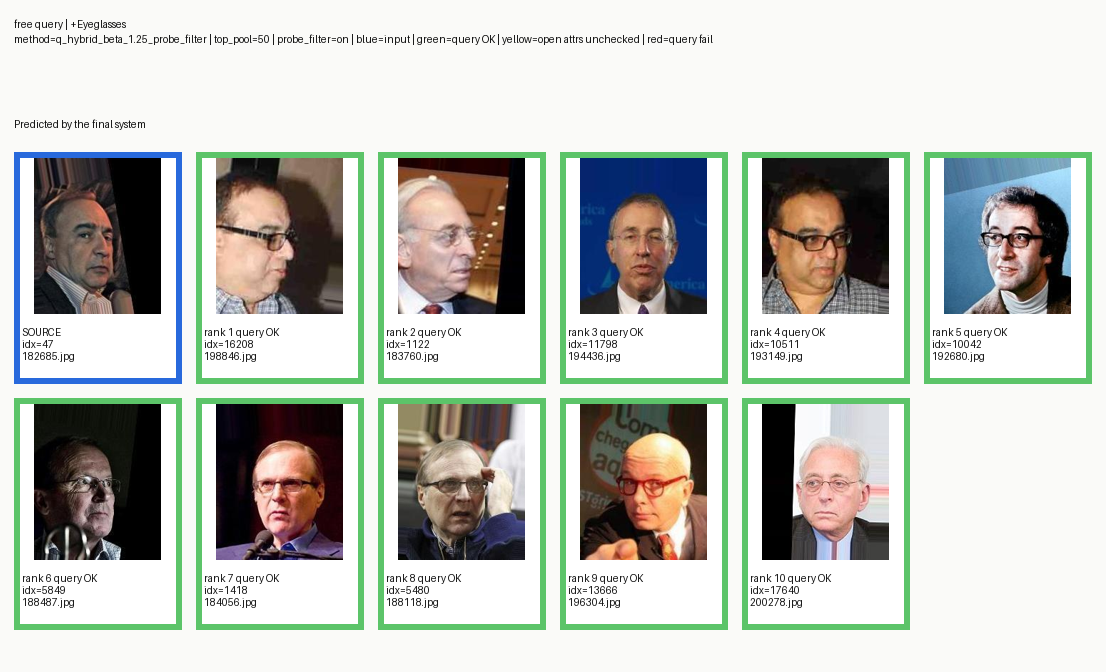</td>
<td>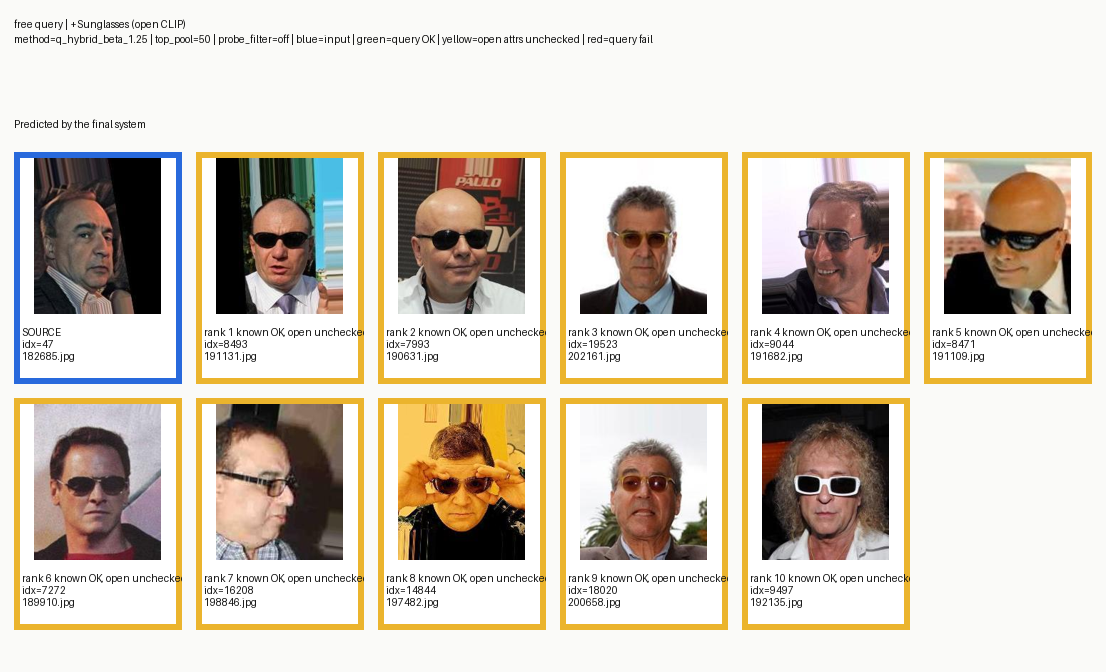</td>
</tr>
</table>

### Multi-attribute open-vocabulary examples

The more interesting case is when multiple edits are requested at once, mixing known CelebA attributes with unknown open-vocabulary ones. Below we use the same source identity and vary combinations such as `visible teeth`, `Eyeglasses`, `Sunglasses`, and `white skin`. The examples show that the system can often move toward the requested combination while preserving a coherent face neighborhood.

<table>
<tr>
<td><strong>-visible teeth, -Eyeglasses</strong></td>
<td><strong>+white skin, -visible teeth, -Eyeglasses</strong></td>
</tr>
<tr>
<td>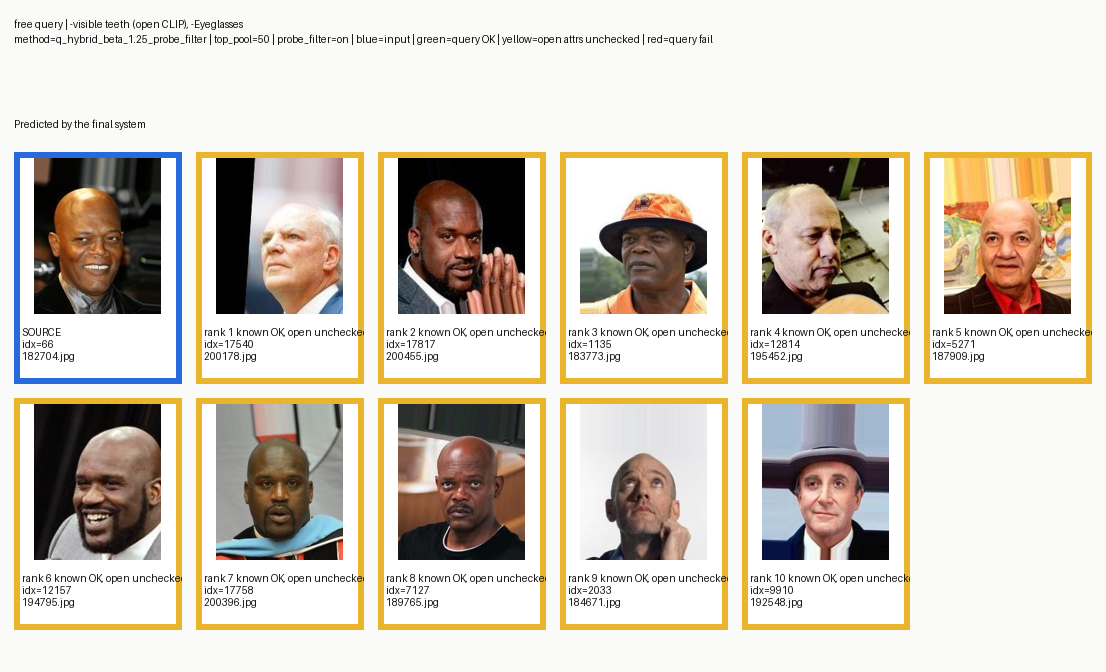</td>
<td>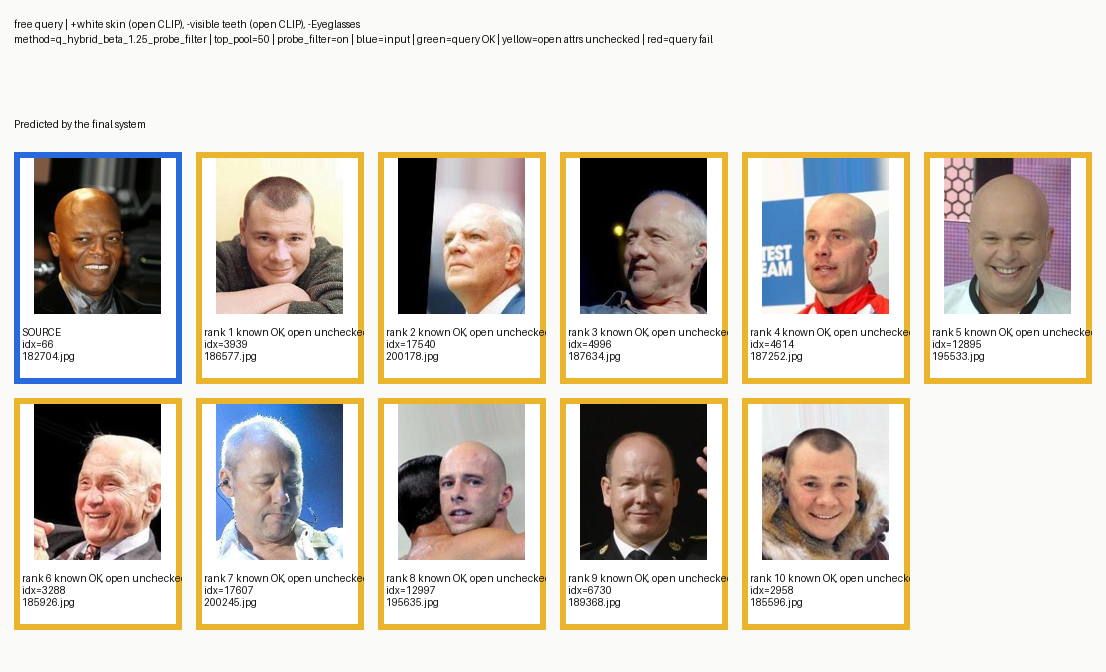</td>
</tr>
</table>

<table>
<tr>
<td><strong>-visible teeth, +Eyeglasses</strong></td>
</tr>
<tr>
<td>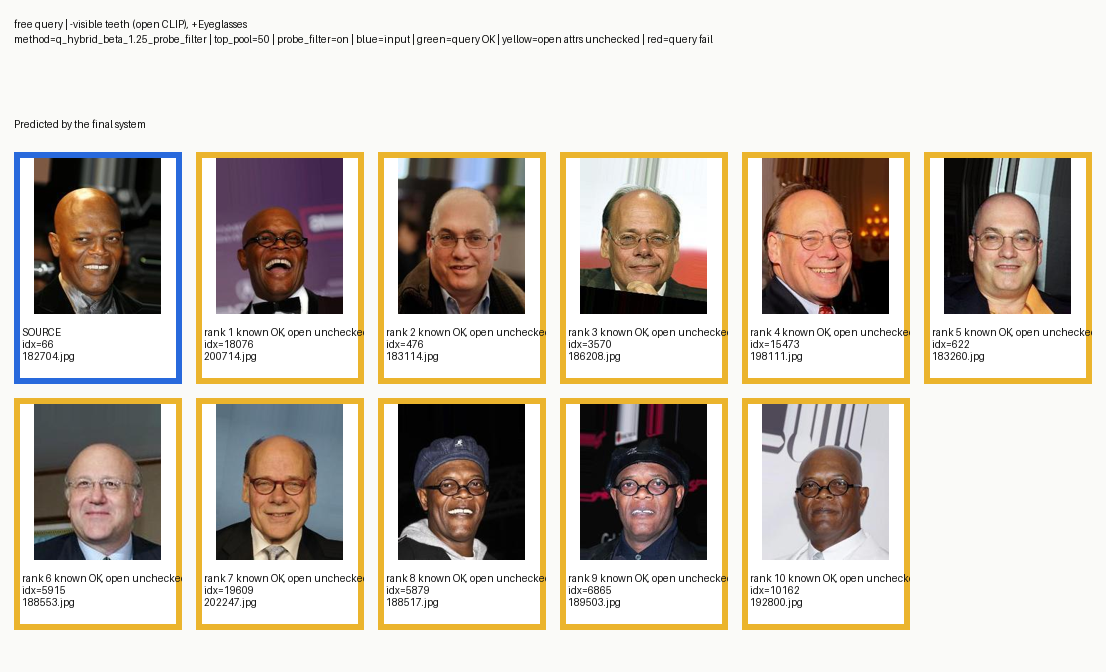</td>
</tr>
</table>


<table>
<tr>
<td><strong>+visible teeth, +sunglasses</strong></td>
</tr>
<tr>
<td>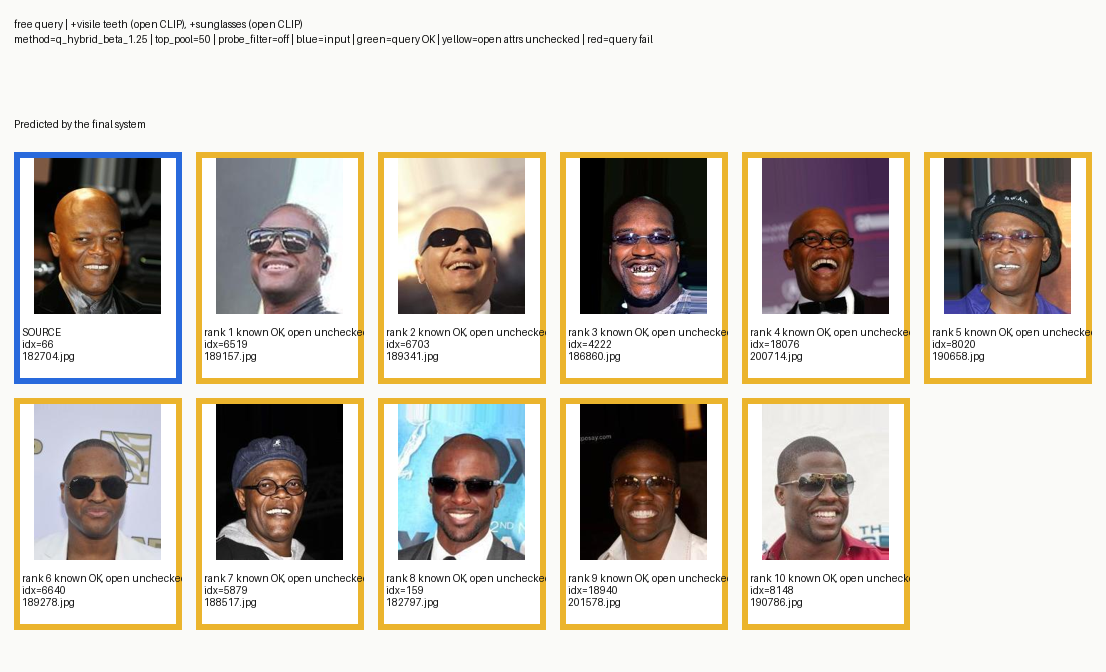</td>
</tr>
</table>

These examples are useful for discussion because they demonstrate two things: first, the system can compose more than one requested edit; second, some requested edits can be concepts not present in the training labels but still present in CLIP semantic space.


## Appendix: Full Cluster Source Used For Final Runs

The assignment requests a single self-contained notebook. The cells above contain the runnable notebook implementation and the saved outputs. For auditability, this appendix includes the exact Python source files used for the final cluster runs: embedding creation, prompt creation, pair construction, baseline, gate v7 training/hyperparameter search, probe v4 sweep, and final probe reranking evaluation.

These appendix cells are intentionally Markdown code listings, not executed during normal review, because the actual full runs require cluster resources and cached embeddings. They make the training/evaluation code visible in the submitted notebook without accidentally launching multi-hour jobs.


### `cluster/scripts/create_embeddings.py`

```python
#!/usr/bin/env python3
"""Create resumable CLIP image and text embedding caches."""

from __future__ import annotations

import argparse
import signal
import time
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

from project_core import (
    CHECKPOINT_DIR,
    EMBEDDING_DIR,
    MODEL_ID,
    atomic_torch_save,
    attribute_names,
    choose_device,
    load_celeba,
    load_torch,
    prompt_pair,
    unwrap_features,
)


STOP_REQUESTED = False


def request_stop(signum, frame) -> None:
    del signum, frame
    global STOP_REQUESTED
    STOP_REQUESTED = True
    print("Stop requested: finishing the current batch before exiting.")


class IndexedImages(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        return image, index


class ImageCollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, batch):
        images, indices = zip(*batch)
        pixels = self.processor(images=list(images), return_tensors="pt")[
            "pixel_values"
        ]
        return pixels, torch.tensor(indices)


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--split", choices=("train", "valid", "test"), required=True)
    parser.add_argument("--batch-size", type=int, default=256)
    parser.add_argument("--workers", type=int, default=8)
    parser.add_argument("--device", choices=("auto", "cpu", "cuda"), default="auto")
    parser.add_argument("--time-budget-seconds", type=int, default=480)
    parser.add_argument("--force", action="store_true")
    return parser.parse_args()


def contiguous_resume_index(chunks_dir: Path) -> int:
    expected = 0
    for path in sorted(chunks_dir.glob("chunk_*.pt")):
        chunk = load_torch(path)
        start = int(chunk["indices"][0])
        end = int(chunk["indices"][-1]) + 1
        if start != expected:
            break
        expected = end
    return expected


def create_text_cache(model, processor, device, dataset) -> None:
    path = EMBEDDING_DIR / "attribute_text_embeddings.pt"
    names = attribute_names(dataset)
    if path.exists():
        cache = load_torch(path)
        if cache.get("model_id") == MODEL_ID and cache.get("attributes") == names:
            print(f"Reusing text cache: {path}")
            return

    pairs = [prompt_pair(name) for name in names]
    prompts = [prompt for pair in pairs for prompt in pair]
    inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)
    with torch.inference_mode():
        features = unwrap_features(model.get_text_features(**inputs)).float()
        features = F.normalize(features, dim=-1).cpu()
    positive = features[0::2]
    negative = features[1::2]
    atomic_torch_save(
        {
            "model_id": MODEL_ID,
            "attributes": names,
            "prompts": pairs,
            "positive": positive.half(),
            "negative": negative.half(),
            "directions": F.normalize(positive - negative, dim=-1).half(),
        },
        path,
    )
    print(f"Saved text cache: {path}")


def finalize_split(split, dataset, chunks_dir, final_path) -> None:
    chunks = []
    expected = 0
    for path in sorted(chunks_dir.glob("chunk_*.pt")):
        chunk = load_torch(path)
        indices = chunk["indices"]
        if int(indices[0]) != expected:
            raise RuntimeError(f"Non-contiguous embedding chunks at index {expected}")
        expected = int(indices[-1]) + 1
        chunks.append(chunk["embeddings"])
    if expected != len(dataset):
        raise RuntimeError(f"Cannot finalize {split}: reached {expected}/{len(dataset)}")
    embeddings = torch.cat(chunks)
    atomic_torch_save(
        {
            "model_id": MODEL_ID,
            "split": split,
            "embeddings": embeddings,
            "filenames": list(dataset.filename),
        },
        final_path,
    )
    print(f"Final cache saved: {final_path}")


def main() -> int:
    args = parse_args()
    started = time.monotonic()
    signal.signal(signal.SIGTERM, request_stop)
    if hasattr(signal, "SIGUSR1"):
        signal.signal(signal.SIGUSR1, request_stop)

    dataset = load_celeba(args.split)
    final_path = EMBEDDING_DIR / f"{args.split}_image_embeddings.pt"
    chunks_dir = CHECKPOINT_DIR / "embeddings" / args.split
    chunks_dir.mkdir(parents=True, exist_ok=True)
    EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)

    if final_path.exists() and not args.force:
        cache = load_torch(final_path)
        if len(cache["embeddings"]) == len(dataset) and cache["model_id"] == MODEL_ID:
            print(f"Complete cache already exists: {final_path}")
            return 0

    if args.force:
        for path in chunks_dir.glob("chunk_*.pt"):
            path.unlink()
        final_path.unlink(missing_ok=True)

    start_index = contiguous_resume_index(chunks_dir)
    print(f"Resuming {args.split} at dataset index {start_index}/{len(dataset)}")
    if start_index == len(dataset):
        finalize_split(args.split, dataset, chunks_dir, final_path)
        return 0

    device = choose_device(args.device)
    processor = CLIPProcessor.from_pretrained(MODEL_ID)
    model = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    create_text_cache(model, processor, device, dataset)

    remaining = Subset(IndexedImages(dataset), range(start_index, len(dataset)))
    loader = DataLoader(
        remaining,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.workers,
        pin_memory=device.type == "cuda",
        persistent_workers=args.workers > 0,
        collate_fn=ImageCollator(processor),
    )

    with torch.inference_mode():
        for pixels, indices in tqdm(loader, desc=f"Encoding {args.split}"):
            features = unwrap_features(
                model.get_image_features(pixel_values=pixels.to(device))
            )
            features = F.normalize(features.float(), dim=-1).cpu().half()
            first = int(indices[0])
            end = int(indices[-1]) + 1
            atomic_torch_save(
                {
                    "model_id": MODEL_ID,
                    "split": args.split,
                    "indices": indices,
                    "filenames": [dataset.filename[index] for index in indices.tolist()],
                    "embeddings": features,
                },
                chunks_dir / f"chunk_{first:08d}_{end:08d}.pt",
            )

            elapsed = time.monotonic() - started
            if STOP_REQUESTED or elapsed >= args.time_budget_seconds:
                print(f"Checkpointed through index {end}; submit the job again.")
                return 3

    finalize_split(args.split, dataset, chunks_dir, final_path)
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/scripts/create_prompt_embeddings.py`

```python
#!/usr/bin/env python3
"""Create CLIP text embeddings for the manual prompt ensemble.

This is separate from the older attribute_text_embeddings.pt cache used by the
zero-shot baselines. The learned gate model uses this file because each signed
attribute is represented by the normalized mean of 2-3 natural prompts.
"""

from __future__ import annotations

import argparse
import json
from pathlib import Path

import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

from project_core import (
    EMBEDDING_DIR,
    MODEL_ID,
    ROOT,
    atomic_torch_save,
    choose_device,
    read_attribute_table,
    unwrap_features,
)


DEFAULT_PROMPTS = ROOT / "configs" / "attribute_prompts.json"
DEFAULT_OUTPUT = EMBEDDING_DIR / "signed_attribute_prompt_embeddings.pt"


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--prompt-config", type=Path, default=DEFAULT_PROMPTS)
    parser.add_argument("--output", type=Path, default=DEFAULT_OUTPUT)
    parser.add_argument("--device", choices=("auto", "cpu", "cuda"), default="auto")
    parser.add_argument("--force", action="store_true")
    return parser.parse_args()


def load_prompt_config(path: Path) -> dict:
    with path.open(encoding="utf-8") as handle:
        config = json.load(handle)
    return config


def validate_prompt_config(config: dict, attributes: list[str]) -> None:
    missing = [attribute for attribute in attributes if attribute not in config]
    extra = [attribute for attribute in config if attribute not in set(attributes)]
    if missing:
        raise RuntimeError(f"Missing prompt entries: {missing}")
    if extra:
        raise RuntimeError(f"Unknown prompt entries: {extra}")
    for attribute in attributes:
        entry = config[attribute]
        for polarity in ("positive", "negative"):
            prompts = entry.get(polarity)
            if not isinstance(prompts, list) or not 2 <= len(prompts) <= 5:
                raise RuntimeError(
                    f"{attribute}.{polarity} must contain 2-5 prompt strings"
                )
            if not all(isinstance(prompt, str) and prompt.strip() for prompt in prompts):
                raise RuntimeError(f"{attribute}.{polarity} contains invalid prompts")


def embed_prompt_groups(model, processor, device, groups: list[list[str]]) -> torch.Tensor:
    group_embeddings = []
    for prompts in groups:
        inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)
        with torch.inference_mode():
            features = unwrap_features(model.get_text_features(**inputs)).float()
            features = F.normalize(features, dim=-1)
            group_embedding = F.normalize(features.mean(dim=0, keepdim=True), dim=-1)
        group_embeddings.append(group_embedding.cpu())
    return torch.cat(group_embeddings, dim=0)


def main() -> int:
    args = parse_args()
    attributes, _, _ = read_attribute_table()
    prompt_config = load_prompt_config(args.prompt_config)
    validate_prompt_config(prompt_config, attributes)

    if args.output.exists() and not args.force:
        cache = torch.load(args.output, map_location="cpu", weights_only=False)
        if (
            cache.get("model_id") == MODEL_ID
            and cache.get("attributes") == attributes
            and cache.get("prompt_config_path") == str(args.prompt_config)
        ):
            print(f"Complete prompt cache already exists: {args.output}")
            return 0

    device = choose_device(args.device)
    processor = CLIPProcessor.from_pretrained(MODEL_ID)
    model = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    positive_groups = [prompt_config[attribute]["positive"] for attribute in attributes]
    negative_groups = [prompt_config[attribute]["negative"] for attribute in attributes]
    positive = embed_prompt_groups(model, processor, device, positive_groups)
    negative = embed_prompt_groups(model, processor, device, negative_groups)

    atomic_torch_save(
        {
            "model_id": MODEL_ID,
            "attributes": attributes,
            "prompt_config_path": str(args.prompt_config),
            "prompt_config": prompt_config,
            "positive": positive.half(),
            "negative": negative.half(),
            "directions": F.normalize(positive - negative, dim=-1).half(),
            "notes": (
                "positive/negative store normalized mean prompt embeddings. "
                "For a signed edit +A use positive[A]; for -A use negative[A]."
            ),
        },
        args.output,
    )
    print(f"Saved signed prompt cache: {args.output}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/scripts/build_training_pairs.py`

```python
#!/usr/bin/env python3
"""Build same-identity edit tuples for the learned gate model."""

from __future__ import annotations

import argparse
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import torch

from learned_gate_core import signed_condition_text
from project_core import (
    ARTIFACTS_DIR,
    atomic_json_dump,
    atomic_torch_save,
    load_torch,
    read_attribute_table,
    read_identity_map,
)


DEFAULT_OUTPUT_DIR = ARTIFACTS_DIR / "training_pairs"
SPLITS = {"train": 0, "valid": 1}


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--splits", nargs="+", choices=tuple(SPLITS), default=["train", "valid"])
    parser.add_argument("--min-query-len", type=int, default=1)
    parser.add_argument("--max-query-len", type=int, default=3)
    parser.add_argument("--output-dir", type=Path, default=DEFAULT_OUTPUT_DIR)
    parser.add_argument("--max-pairs-per-length", type=int, default=0)
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--write-jsonl", action="store_true")
    parser.add_argument("--force", action="store_true")
    return parser.parse_args()


def embedding_filenames(split: str) -> list[str]:
    from learned_gate_core import load_image_embedding_cache

    cache = load_image_embedding_cache(split)
    return list(cache["filenames"])


def collect_pairs_for_split(
    split: str,
    attributes: list[str],
    attr_by_file: dict[str, torch.Tensor],
    identities: dict[str, int],
    min_query_len: int,
    max_query_len: int,
) -> dict:
    filenames = embedding_filenames(split)
    split_attrs = torch.stack([attr_by_file[filename] for filename in filenames])
    split_identities = [identities[filename] for filename in filenames]

    by_identity: dict[int, list[int]] = defaultdict(list)
    for index, identity in enumerate(split_identities):
        by_identity[identity].append(index)

    source_indices = []
    target_indices = []
    padded_attrs = []
    padded_signs = []
    query_lengths = []
    pair_identities = []
    counts = Counter()

    for identity, indices in by_identity.items():
        if len(indices) < 2:
            continue
        for source_index in indices:
            source_attr = split_attrs[source_index]
            for target_index in indices:
                if source_index == target_index:
                    continue
                target_attr = split_attrs[target_index]
                diff_positions = torch.nonzero(source_attr != target_attr).flatten()
                query_len = int(diff_positions.numel())
                if not min_query_len <= query_len <= max_query_len:
                    continue
                signs = target_attr[diff_positions].to(torch.int8)
                padded_attr = torch.full((max_query_len,), -1, dtype=torch.long)
                padded_sign = torch.zeros((max_query_len,), dtype=torch.int8)
                padded_attr[:query_len] = diff_positions.long()
                padded_sign[:query_len] = signs

                source_indices.append(source_index)
                target_indices.append(target_index)
                padded_attrs.append(padded_attr)
                padded_signs.append(padded_sign)
                query_lengths.append(query_len)
                pair_identities.append(identity)
                counts[query_len] += 1

    if not source_indices:
        raise RuntimeError(f"No pairs found for split={split}")

    return {
        "split": split,
        "attributes": attributes,
        "filenames": filenames,
        "attrs": split_attrs,
        "source_indices": torch.tensor(source_indices, dtype=torch.long),
        "target_indices": torch.tensor(target_indices, dtype=torch.long),
        "attr_indices": torch.stack(padded_attrs),
        "signs": torch.stack(padded_signs),
        "query_lengths": torch.tensor(query_lengths, dtype=torch.long),
        "identities": torch.tensor(pair_identities, dtype=torch.long),
        "max_query_len": max_query_len,
        "counts_by_query_len": dict(sorted(counts.items())),
    }


def maybe_subsample_by_length(index: dict, max_pairs_per_length: int, seed: int) -> dict:
    if max_pairs_per_length <= 0:
        return index
    generator = torch.Generator().manual_seed(seed)
    keep_parts = []
    lengths = index["query_lengths"]
    for query_len in sorted(set(lengths.tolist())):
        positions = torch.nonzero(lengths == query_len).flatten()
        if len(positions) > max_pairs_per_length:
            order = torch.randperm(len(positions), generator=generator)
            positions = positions[order[:max_pairs_per_length]]
        keep_parts.append(positions)
    keep = torch.cat(keep_parts)
    keep = keep[torch.randperm(len(keep), generator=generator)]

    output = dict(index)
    for key in (
        "source_indices",
        "target_indices",
        "attr_indices",
        "signs",
        "query_lengths",
        "identities",
    ):
        output[key] = index[key][keep]
    output["subsampled"] = True
    output["max_pairs_per_length"] = max_pairs_per_length
    output["counts_by_query_len"] = dict(
        sorted(Counter(output["query_lengths"].tolist()).items())
    )
    return output


def write_jsonl(path: Path, index: dict, limit: int | None = None) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    total = len(index["source_indices"])
    n = total if limit is None else min(total, limit)
    with path.open("w", encoding="utf-8") as handle:
        for row in range(n):
            length = int(index["query_lengths"][row])
            source_index = int(index["source_indices"][row])
            target_index = int(index["target_indices"][row])
            record = {
                "source_index": source_index,
                "target_index": target_index,
                "source_filename": index["filenames"][source_index],
                "target_filename": index["filenames"][target_index],
                "identity": int(index["identities"][row]),
                "query_length": length,
                "query": signed_condition_text(
                    index["attr_indices"][row],
                    index["signs"][row],
                    length,
                    index["attributes"],
                ),
            }
            handle.write(json.dumps(record) + "\n")


def main() -> int:
    args = parse_args()
    random.seed(args.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)

    attributes, filenames, all_attrs = read_attribute_table()
    identities = read_identity_map()
    attr_by_file = {
        filename: all_attrs[index] for index, filename in enumerate(filenames)
    }

    summaries = []
    for split in args.splits:
        output_path = (
            args.output_dir
            / f"{split}_pairs_len{args.min_query_len}_{args.max_query_len}.pt"
        )
        if output_path.exists() and not args.force:
            index = load_torch(output_path)
            print(f"Reusing pair index: {output_path}")
        else:
            print(f"Building {split} pairs...")
            index = collect_pairs_for_split(
                split,
                attributes,
                attr_by_file,
                identities,
                args.min_query_len,
                args.max_query_len,
            )
            index = maybe_subsample_by_length(
                index,
                args.max_pairs_per_length,
                args.seed + SPLITS[split],
            )
            atomic_torch_save(index, output_path)
            print(f"Saved pair index: {output_path}")

        summary = {
            "split": split,
            "pairs": int(len(index["source_indices"])),
            "counts_by_query_len": {
                str(key): int(value)
                for key, value in index["counts_by_query_len"].items()
            },
            "path": str(output_path),
        }
        summaries.append(summary)
        print(json.dumps(summary, indent=2))
        if args.write_jsonl:
            write_jsonl(output_path.with_suffix(".jsonl"), index)

    atomic_json_dump(
        {
            "min_query_len": args.min_query_len,
            "max_query_len": args.max_query_len,
            "splits": summaries,
        },
        args.output_dir / "summary.json",
    )
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/scripts/run_baseline.py`

```python
#!/usr/bin/env python3
"""Run one resumable official zero-shot baseline."""

from __future__ import annotations

import argparse
import csv
import json
import signal
import time
from pathlib import Path

import torch

from project_core import (
    CHECKPOINT_DIR,
    EMBEDDING_DIR,
    METHOD_FOLDERS,
    MODEL_ID,
    RESULTS_DIR,
    TOP_KS,
    atomic_json_dump,
    attribute_names,
    choose_device,
    compose_queries,
    load_celeba,
    load_evaluation,
    load_torch,
    parse_query,
    retrieval_metrics,
)


STOP_REQUESTED = False


def request_stop(signum, frame) -> None:
    del signum, frame
    global STOP_REQUESTED
    STOP_REQUESTED = True
    print("Stop requested: finishing the current source batch.")


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--method", choices=tuple(METHOD_FOLDERS), required=True)
    parser.add_argument("--source-batch-size", type=int, default=256)
    parser.add_argument("--device", choices=("auto", "cpu", "cuda"), default="auto")
    parser.add_argument("--time-budget-seconds", type=int, default=480)
    parser.add_argument("--force", action="store_true")
    return parser.parse_args()


def write_csv(path: Path, rows: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    temporary.replace(path)


def finalize(method, annotations, chunks_dir, result_dir) -> None:
    per_query = []
    retrieval_path = result_dir / "retrievals.jsonl"
    retrieval_tmp = retrieval_path.with_suffix(".jsonl.tmp")
    with retrieval_tmp.open("w", encoding="utf-8") as retrieval_file:
        for query_id, item in enumerate(annotations):
            source_count = len(item["ground_truth"])
            totals = {f"Recall@{k}": 0.0 for k in TOP_KS}
            totals.update({f"Precision@{k}": 0.0 for k in TOP_KS})
            seen = 0
            for path in sorted(chunks_dir.glob(f"q{query_id:02d}_*.json")):
                chunk = json.loads(path.read_text(encoding="utf-8"))
                for record in chunk["records"]:
                    retrieval_file.write(json.dumps(record) + "\n")
                    valid = set(item["ground_truth"][str(record["source_index"])])
                    for k in TOP_KS:
                        recall, precision = retrieval_metrics(record["top10"], valid, k)
                        totals[f"Recall@{k}"] += recall
                        totals[f"Precision@{k}"] += precision
                    seen += 1
            if seen != source_count:
                raise RuntimeError(
                    f"Query {query_id} incomplete: {seen}/{source_count} source cases"
                )
            per_query.append(
                {
                    "query_id": query_id,
                    "query": item["query"],
                    "sources": source_count,
                    **{name: value / source_count for name, value in totals.items()},
                }
            )
    retrieval_tmp.replace(retrieval_path)
    write_csv(result_dir / "per_query_metrics.csv", per_query)
    metric_names = [name for name in per_query[0] if "@" in name]
    total_sources = sum(row["sources"] for row in per_query)
    summary = {
        "method": method,
        "query_entries": len(per_query),
        "source_query_cases": total_sources,
        **{
            f"macro_{name}": sum(row[name] for row in per_query) / len(per_query)
            for name in metric_names
        },
        **{
            f"micro_{name}": sum(row[name] * row["sources"] for row in per_query)
            / total_sources
            for name in metric_names
        },
    }
    write_csv(result_dir / "summary.csv", [summary])
    atomic_json_dump(
        {"model_id": MODEL_ID, "method": method, "top_ks": TOP_KS},
        result_dir / "config.json",
    )
    (result_dir / "COMPLETE").write_text("complete\n", encoding="utf-8")
    print(f"Final results saved in {result_dir}")


def main() -> int:
    args = parse_args()
    started = time.monotonic()
    signal.signal(signal.SIGTERM, request_stop)
    if hasattr(signal, "SIGUSR1"):
        signal.signal(signal.SIGUSR1, request_stop)

    result_dir = RESULTS_DIR / METHOD_FOLDERS[args.method]
    chunks_dir = CHECKPOINT_DIR / "baselines" / args.method
    result_dir.mkdir(parents=True, exist_ok=True)
    chunks_dir.mkdir(parents=True, exist_ok=True)
    complete_marker = result_dir / "COMPLETE"
    if complete_marker.exists() and not args.force:
        print(f"Baseline already complete: {result_dir}")
        return 0
    if args.force:
        for path in chunks_dir.glob("*.json"):
            path.unlink()
        for path in result_dir.iterdir():
            if path.is_file():
                path.unlink()

    checkpoint_config_path = chunks_dir / "checkpoint_config.json"
    checkpoint_config = {
        "model_id": MODEL_ID,
        "method": args.method,
        "source_batch_size": args.source_batch_size,
    }
    if checkpoint_config_path.exists():
        existing_config = json.loads(
            checkpoint_config_path.read_text(encoding="utf-8")
        )
        if existing_config != checkpoint_config:
            raise RuntimeError(
                "Checkpoint configuration changed. Reuse the original batch size "
                "or restart with --force."
            )
    else:
        atomic_json_dump(checkpoint_config, checkpoint_config_path)

    gallery_cache = load_torch(EMBEDDING_DIR / "test_image_embeddings.pt")
    text_cache = load_torch(EMBEDDING_DIR / "attribute_text_embeddings.pt")
    if gallery_cache["model_id"] != MODEL_ID or text_cache["model_id"] != MODEL_ID:
        raise RuntimeError("Embedding cache model IDs do not match the required CLIP model")

    dataset = load_celeba("test")
    names = attribute_names(dataset)
    if text_cache["attributes"] != names:
        raise RuntimeError("Text cache attributes do not match CelebA")
    attribute_to_index = {name: index for index, name in enumerate(names)}
    annotations = load_evaluation()
    device = choose_device(args.device)
    gallery = gallery_cache["embeddings"].float().to(device)
    positive = text_cache["positive"].float().to(device)
    directions = text_cache["directions"].float().to(device)

    with torch.inference_mode():
        for query_id, item in enumerate(annotations):
            conditions = parse_query(item["query"])
            source_indices = [int(index) for index in item["ground_truth"]]
            for start in range(0, len(source_indices), args.source_batch_size):
                end = min(start + args.source_batch_size, len(source_indices))
                chunk_path = chunks_dir / f"q{query_id:02d}_{start:06d}_{end:06d}.json"
                if chunk_path.exists():
                    continue
                batch_indices = source_indices[start:end]
                queries = compose_queries(
                    gallery[batch_indices],
                    conditions,
                    args.method,
                    attribute_to_index,
                    positive,
                    directions,
                )
                scores = queries @ gallery.T
                rows = torch.arange(len(batch_indices), device=device)
                scores[rows, torch.tensor(batch_indices, device=device)] = -torch.inf
                rankings = scores.topk(max(TOP_KS), dim=1).indices.cpu().tolist()
                atomic_json_dump(
                    {
                        "method": args.method,
                        "query_id": query_id,
                        "query": item["query"],
                        "start": start,
                        "end": end,
                        "records": [
                            {
                                "query_id": query_id,
                                "query": item["query"],
                                "source_index": source_index,
                                "top10": ranking,
                            }
                            for source_index, ranking in zip(batch_indices, rankings)
                        ],
                    },
                    chunk_path,
                )
                print(
                    f"{args.method}: query {query_id + 1}/{len(annotations)}, "
                    f"sources {end}/{len(source_indices)}"
                )
                elapsed = time.monotonic() - started
                if STOP_REQUESTED or elapsed >= args.time_budget_seconds:
                    print("Checkpoint saved; submit the same job again.")
                    return 3

    finalize(args.method, annotations, chunks_dir, result_dir)
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/experimental/train_official_mix_v7_weighted.py`

```python
#!/usr/bin/env python3
"""Train v7 with Hamming-weighted official-like multi-positive sets.

This trainer keeps the current final-system architecture intact:

    q_final = normalize(q_model + beta * (q_sum - source))

The change is the training mixture:

- official-like multi-positive rows from the train split only;
- same-identity rows from the original train-pair index;
- weak/global official-like oversampling rows from the train split only.

Compared with v6, this trainer does not treat all official-like positives as
equally strong. Candidates satisfying the requested query with non-query
Hamming distance <= 1 can receive a higher positive weight than candidates at
distance exactly 2. This keeps the official <=2 objective while adding a soft
source-preservation preference.

No official JSON target list is used here. The JSON is reserved for the
hpsearch runner's post-training evaluation.
"""

from __future__ import annotations

import argparse
import json
import os
import random
import signal
import sys
import time
from collections import Counter
from pathlib import Path

import torch
import torch.nn.functional as F


ROOT = Path(__file__).resolve().parents[1]
SCRIPTS = ROOT / "scripts"
EXPERIMENTAL = ROOT / "experimental"
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(EXPERIMENTAL))
os.environ.setdefault("DL_PROJECT_ROOT", str(ROOT))

from learned_gate_core import (  # noqa: E402
    create_model_from_config,
    dump_config,
    load_image_embedding_cache,
    load_prompt_embedding_cache,
    progress_line,
    save_checkpoint,
    write_csv_rows,
)
from project_core import choose_device, load_torch  # noqa: E402
from train_gate_model import (  # noqa: E402
    false_negative_mask,
    load_pair_index,
    make_batch,
    plot_metric_curves,
    positions_by_length,
    sample_positions,
    source_similarity_filter,
)
from train_blend_finetune_v4 import (  # noqa: E402
    blended_query,
    generic_sum_query,
    hard_triplet_loss,
    load_config,
    load_start_weights,
    load_text_bank,
    resolve_project_path,
    validate_blend,
)


STOP_REQUESTED = False


def request_stop(signum, frame) -> None:
    del signum, frame
    global STOP_REQUESTED
    STOP_REQUESTED = True


def find_default_start_checkpoint_v6() -> Path:
    candidates = [
        ROOT / "final_best_system" / "weights" / "best_val_official_like_at10.pt",
        ROOT.parent / "final_best_system" / "weights" / "best_val_official_like_at10.pt",
    ]
    candidates.extend(
        sorted(
            (ROOT / "artifacts" / "training_runs").glob(
                "hpsearch_mixed_weak_v5_*_long/"
                "mixed_v5_mw85_012*/"
                "checkpoints/best_val_official_like_at10.pt"
            ),
            reverse=True,
        )
    )
    candidates.extend(
        sorted(
            (ROOT / "artifacts" / "training_runs").glob(
                "hpsearch_gate_v3_*_long/"
                "gate_v3_sequentialgate_hybmp_l002*/"
                "checkpoints/best_val_official_like_at10.pt"
            ),
            reverse=True,
        )
    )
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find a v5/v3 start checkpoint for v6 training")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--profile", choices=("short", "long"), default="long")
    parser.add_argument("--config", type=Path, required=True)
    parser.add_argument("--run-dir", type=Path, required=True)
    parser.add_argument("--device", choices=("auto", "cpu", "cuda"), default="auto")
    parser.add_argument("--time-budget-seconds", type=int, default=0)
    parser.add_argument("--force", action="store_true")
    return parser.parse_args()


def load_pair_index_from_path(path: str | os.PathLike | None, default_split: str) -> dict:
    if path:
        resolved = resolve_project_path(path)
        if resolved is None or not resolved.exists():
            raise FileNotFoundError(f"Missing pair index: {resolved}")
        return load_torch(resolved)
    return load_pair_index(default_split)


def batch_from_positions(index: dict, positions: torch.Tensor) -> dict:
    batch = make_batch(index, positions)
    if "group_ids" in index:
        batch["group_ids"] = index["group_ids"][positions]
    return batch


def sample_from(index: dict, by_length: dict[int, torch.Tensor], count: int, config: dict) -> dict:
    if count <= 0:
        return {}
    local_config = dict(config)
    local_config["batch_size"] = count
    positions = sample_positions(index, by_length, local_config)
    return batch_from_positions(index, positions)


def positions_by_group(index: dict) -> list[torch.Tensor]:
    group_ids = index.get("group_ids")
    if group_ids is None:
        raise RuntimeError("Official-like v6 index must contain group_ids")
    order = torch.argsort(group_ids)
    ordered_groups = group_ids[order]
    _, counts = torch.unique_consecutive(ordered_groups, return_counts=True)
    return list(torch.split(order, counts.tolist()))


def sample_official_groups(index: dict, group_positions: list[torch.Tensor], count: int, config: dict) -> dict:
    if count <= 0:
        return {}
    positives_per_group = max(1, int(config.get("official_positives_per_group", 2)))
    group_count = max(1, (count + positives_per_group - 1) // positives_per_group)
    selected_groups = torch.randint(0, len(group_positions), (group_count,))
    positions: list[torch.Tensor] = []
    for group_id in selected_groups.tolist():
        pool = group_positions[group_id]
        if len(pool) >= positives_per_group:
            choice = pool[torch.randperm(len(pool))[:positives_per_group]]
        else:
            repeats = torch.randint(0, len(pool), (positives_per_group,))
            choice = pool[repeats]
        positions.append(choice)
    sampled = torch.cat(positions)
    if len(sampled) > count:
        sampled = sampled[:count]
    elif len(sampled) < count:
        extra = torch.randint(0, len(index["source_indices"]), (count - len(sampled),))
        sampled = torch.cat([sampled, extra])
    return batch_from_positions(index, sampled)


def concat_batches(parts: list[dict]) -> dict:
    parts = [part for part in parts if part]
    if len(parts) == 1:
        return parts[0]
    keys = set().union(*(part.keys() for part in parts))
    result = {}
    for key in keys:
        values = [part[key] for part in parts if key in part]
        if len(values) == len(parts):
            result[key] = torch.cat(values, dim=0)
    return result


def source_counts(config: dict, has_official: bool, has_weak: bool) -> tuple[int, int, int]:
    batch_size = int(config["batch_size"])
    official_fraction = float(config.get("official_pair_fraction", 0.0)) if has_official else 0.0
    same_fraction = float(config.get("same_pair_fraction", 1.0))
    weak_fraction = float(config.get("weak_pair_fraction", 0.0)) if has_weak else 0.0
    total = official_fraction + same_fraction + weak_fraction
    if total <= 0:
        raise ValueError("At least one pair fraction must be positive")
    official_count = int(round(batch_size * official_fraction / total))
    weak_count = int(round(batch_size * weak_fraction / total))
    official_count = max(0, min(batch_size, official_count))
    weak_count = max(0, min(batch_size - official_count, weak_count))
    same_count = batch_size - official_count - weak_count
    return official_count, same_count, weak_count


def mixed_batch(
    official_index: dict | None,
    same_index: dict,
    weak_index: dict | None,
    official_groups: list[torch.Tensor] | None,
    weak_groups: list[torch.Tensor] | None,
    same_by_length: dict[int, torch.Tensor],
    weak_by_length: dict[int, torch.Tensor] | None,
    config: dict,
) -> tuple[dict, dict[str, int]]:
    official_count, same_count, weak_count = source_counts(
        config,
        has_official=official_index is not None,
        has_weak=weak_index is not None,
    )
    parts = []
    if official_count and official_index is not None and official_groups is not None:
        parts.append(sample_official_groups(official_index, official_groups, official_count, config))
    if same_count:
        parts.append(sample_from(same_index, same_by_length, same_count, config))
    if weak_count and weak_index is not None and weak_by_length is not None:
        if weak_groups is not None:
            parts.append(sample_official_groups(weak_index, weak_groups, weak_count, config))
        else:
            parts.append(sample_from(weak_index, weak_by_length, weak_count, config))
    batch = concat_batches(parts)
    order = torch.randperm(len(batch["source_indices"]))
    batch = {key: value[order] for key, value in batch.items()}
    return batch, {"official": official_count, "same": same_count, "weak": weak_count}


def ensure_attrs_match(reference: dict, *indices: dict | None) -> None:
    for index in indices:
        if index is None:
            continue
        if reference["attributes"] != index["attributes"]:
            raise RuntimeError("Pair index attributes do not match")


def official_like_with_hamming(source_attrs, candidate_attrs, attr_indices, signs, hamming_threshold):
    """Return official-like mask and non-query Hamming distance per source/candidate.

    Shape convention follows ``official_like_mask`` from ``train_gate_model``:
    rows are source/query examples, columns are candidate targets in the batch.
    """
    batch = source_attrs.shape[0]
    device = source_attrs.device
    query_ok = torch.ones((batch, batch), dtype=torch.bool, device=device)
    query_attr_mask = torch.zeros((batch, source_attrs.shape[1]), dtype=torch.bool, device=device)

    for position in range(attr_indices.shape[1]):
        active = attr_indices[:, position] >= 0
        if not bool(active.any()):
            continue
        attrs = attr_indices[:, position].clamp_min(0)
        desired = signs[:, position]
        candidate_values = candidate_attrs[:, attrs].T
        query_ok &= (~active[:, None]) | (candidate_values == desired[:, None])
        query_attr_mask[torch.arange(batch, device=device), attrs] |= active

    nonquery_diff = candidate_attrs.unsqueeze(0) != source_attrs.unsqueeze(1)
    nonquery_diff &= ~query_attr_mask[:, None, :]
    hamming = nonquery_diff.sum(dim=-1)
    official_like = query_ok & (hamming <= int(hamming_threshold))
    return official_like, hamming


def hamming_positive_weights(hamming: torch.Tensor, config: dict) -> torch.Tensor:
    """Map non-query Hamming distances to soft-positive weights.

    Defaults implement the idea:

        h <= 1 -> 1.0
        h == 2 -> configurable softer positive
        h > 2 -> 0.0
    """
    le1 = float(config.get("hamming_weight_le1", 1.0))
    eq2 = float(config.get("hamming_weight_eq2", 0.5))
    gt2 = float(config.get("hamming_weight_gt2", 0.0))
    return torch.where(
        hamming <= 1,
        torch.full_like(hamming, le1, dtype=torch.float32),
        torch.where(
            hamming == 2,
            torch.full_like(hamming, eq2, dtype=torch.float32),
            torch.full_like(hamming, gt2, dtype=torch.float32),
        ),
    )


def weighted_multi_positive_contrastive_loss(scores, positive_weights, neutral_mask):
    """InfoNCE with weighted positives.

    Positive weights change only the numerator. Neutral candidates are removed
    from the denominator so valid-but-not-preferred official-like examples are
    not treated as hard negatives.
    """
    positive_mask = positive_weights > 0
    valid_rows = positive_mask.any(dim=1)
    if not bool(valid_rows.any()):
        return torch.zeros((), device=scores.device)

    scores_for_denominator = scores.masked_fill(neutral_mask & ~positive_mask, -torch.inf)
    safe_weights = positive_weights.clamp_min(1e-8)
    weighted_positive_scores = (scores + safe_weights.log()).masked_fill(~positive_mask, -torch.inf)
    numerator = torch.logsumexp(weighted_positive_scores[valid_rows], dim=1)
    denominator = torch.logsumexp(scores_for_denominator[valid_rows], dim=1)
    return -(numerator - denominator).mean()


def compute_losses(model, teacher_model, batch, embeddings, attrs, prompt_cache, text_bank, config, device):
    src_idx_cpu = batch["source_indices"].long()
    tgt_idx_cpu = batch["target_indices"].long()
    attr_indices = batch["attr_indices"].to(device)
    signs = batch["signs"].to(device)

    source = embeddings[src_idx_cpu].float().to(device)
    target = embeddings[tgt_idx_cpu].float().to(device)
    source_attrs = attrs[src_idx_cpu].to(device)
    target_attrs = attrs[tgt_idx_cpu].to(device)

    from learned_gate_core import condition_embeddings

    conditions, mask = condition_embeddings(
        prompt_cache,
        attr_indices,
        signs,
        device,
        str(config.get("condition_mode", "signed_direction")),
    )

    q_model, alpha, _ = model(source, conditions, mask)
    q_sum = generic_sum_query(
        source,
        attr_indices,
        signs,
        text_bank,
        alpha=float(config.get("sum_alpha", 1.0)),
        source_weight=float(config.get("sum_source_weight", 1.0)),
    )
    q_final = blended_query(q_model, q_sum, source, float(config.get("blend_beta", 1.0)))

    labels = torch.arange(len(src_idx_cpu), device=device)
    eye = torch.eye(len(src_idx_cpu), dtype=torch.bool, device=device)

    false_negatives = false_negative_mask(
        source_attrs,
        target_attrs,
        attr_indices,
        signs,
        int(config["false_negative_hamming"]),
    )
    official_like, nonquery_hamming = official_like_with_hamming(
        source_attrs,
        target_attrs,
        attr_indices,
        signs,
        int(config.get("multipositive_hamming", config["false_negative_hamming"])),
    )
    source_like = source_similarity_filter(source, target, config)

    scores = (q_final @ F.normalize(target, dim=-1).T) / float(config["temperature"])
    exact_scores = scores.masked_fill(false_negatives, -torch.inf)
    exact_info_nce = F.cross_entropy(exact_scores, labels)

    if bool(config.get("use_multipositive_loss", True)):
        weights = hamming_positive_weights(nonquery_hamming, config).to(device)
        positive_weights = weights * official_like.float() * source_like.float()
        if bool(config.get("force_eye_in_weighted_multipositive", True)):
            diag_weights = weights.diag().clamp_min(float(config.get("min_eye_positive_weight", 1e-3)))
            positive_weights[eye] = torch.maximum(positive_weights[eye], diag_weights)
        neutral_mask = official_like & (positive_weights <= 0)
        multipositive_info_nce = weighted_multi_positive_contrastive_loss(
            scores,
            positive_weights,
            neutral_mask,
        )
        multipositive_weight = float(config.get("multipositive_weight", 0.5))
        info_nce = (
            (1.0 - multipositive_weight) * exact_info_nce
            + multipositive_weight * multipositive_info_nce
        )
        positive_count = (positive_weights > 0).float().sum(dim=1).mean()
        positive_weight_mean = positive_weights[positive_weights > 0].mean() if bool((positive_weights > 0).any()) else torch.zeros((), device=device)
        hamming_le1_count = ((official_like & source_like) & (nonquery_hamming <= 1)).float().sum(dim=1).mean()
        hamming_eq2_count = ((official_like & source_like) & (nonquery_hamming == 2)).float().sum(dim=1).mean()
    else:
        multipositive_info_nce = torch.zeros((), device=device)
        multipositive_weight = 0.0
        info_nce = exact_info_nce
        positive_count = torch.ones((), device=device)
        positive_weight_mean = torch.ones((), device=device)
        hamming_le1_count = torch.zeros((), device=device)
        hamming_eq2_count = torch.zeros((), device=device)

    invalid_negatives = eye | false_negatives | official_like
    triplet = hard_triplet_loss(
        q_final,
        target,
        invalid_negatives=invalid_negatives,
        margin=float(config.get("triplet_margin", 0.05)),
    )

    model_aux = torch.zeros((), device=device)
    if float(config.get("lambda_model_aux", 0.0)) > 0:
        model_scores = (F.normalize(q_model, dim=-1) @ F.normalize(target, dim=-1).T) / float(config["temperature"])
        model_aux = F.cross_entropy(model_scores.masked_fill(false_negatives, -torch.inf), labels)

    distill = torch.zeros((), device=device)
    if teacher_model is not None and float(config.get("lambda_distill", 0.0)) > 0:
        with torch.no_grad():
            teacher_q_model, _, _ = teacher_model(source, conditions, mask)
            teacher_q_final = blended_query(
                teacher_q_model,
                q_sum,
                source,
                float(config.get("blend_beta", 1.0)),
            )
        distill = 1.0 - (q_final * teacher_q_final).sum(dim=-1).mean()

    target_cos = 1.0 - (q_final * F.normalize(target, dim=-1)).sum(dim=-1).mean()
    source_cos = 1.0 - (q_final * F.normalize(source, dim=-1)).sum(dim=-1).mean()

    loss = (
        info_nce
        + float(config["lambda_target"]) * target_cos
        + float(config["lambda_source"]) * source_cos
        + float(config.get("lambda_triplet", 0.0)) * triplet
        + float(config.get("lambda_model_aux", 0.0)) * model_aux
        + float(config.get("lambda_distill", 0.0)) * distill
    )

    return loss, {
        "loss": float(loss.detach().cpu()),
        "info_nce": float(info_nce.detach().cpu()),
        "exact_info_nce": float(exact_info_nce.detach().cpu()),
        "multipositive_info_nce": float(multipositive_info_nce.detach().cpu()),
        "multipositive_weight": float(multipositive_weight),
        "weighted_positive_mean": float(positive_weight_mean.detach().cpu()),
        "hamming_le1_positive_count": float(hamming_le1_count.detach().cpu()),
        "hamming_eq2_positive_count": float(hamming_eq2_count.detach().cpu()),
        "triplet_loss": float(triplet.detach().cpu()),
        "model_aux_loss": float(model_aux.detach().cpu()),
        "distill_loss": float(distill.detach().cpu()),
        "target_cosine_loss": float(target_cos.detach().cpu()),
        "source_preservation_loss": float(source_cos.detach().cpu()),
        "cos_final_target": float((q_final * F.normalize(target, dim=-1)).sum(dim=-1).mean().detach().cpu()),
        "cos_final_source": float((q_final * F.normalize(source, dim=-1)).sum(dim=-1).mean().detach().cpu()),
        "cos_model_target": float((F.normalize(q_model, dim=-1) * F.normalize(target, dim=-1)).sum(dim=-1).mean().detach().cpu()),
        "cos_sum_target": float((F.normalize(q_sum, dim=-1) * F.normalize(target, dim=-1)).sum(dim=-1).mean().detach().cpu()),
        "gate_mean": float(alpha[mask].mean().detach().cpu()) if bool(mask.any()) else 0.0,
        "positive_count": float(positive_count.detach().cpu()),
    }


def main() -> int:
    args = parse_args()
    started = time.monotonic()
    signal.signal(signal.SIGTERM, request_stop)
    if hasattr(signal, "SIGUSR1"):
        signal.signal(signal.SIGUSR1, request_stop)

    config = load_config(args.config, args.profile)
    config.setdefault("official_pair_fraction", 0.6)
    config.setdefault("same_pair_fraction", 0.3)
    config.setdefault("weak_pair_fraction", 0.1)
    config.setdefault("official_positives_per_group", 2)
    config.setdefault("hamming_weight_le1", 1.0)
    config.setdefault("hamming_weight_eq2", 0.5)
    config.setdefault("hamming_weight_gt2", 0.0)
    config.setdefault("force_eye_in_weighted_multipositive", True)
    random.seed(int(config["seed"]))
    torch.manual_seed(int(config["seed"]))
    device = choose_device(args.device)

    run_dir = args.run_dir
    if run_dir.exists() and any(run_dir.iterdir()) and not args.force:
        raise RuntimeError(f"Run dir already exists and is not empty: {run_dir}")
    for child in ("checkpoints", "plots", "samples", "logs"):
        (run_dir / child).mkdir(parents=True, exist_ok=True)
    dump_config(config, run_dir / "config.json")

    progress = run_dir / "progress.txt"
    progress_line(progress, f"RUN_DIR {run_dir}")
    progress_line(progress, f"config {json.dumps(config, sort_keys=True)}")
    progress_line(
        progress,
        "TRAINING_OBJECTIVE v7 hamming_weighted_official_like + same_identity + weak_global "
        "q_final=normalize(q_model + beta*(q_sum-source)) "
        f"fractions={config.get('official_pair_fraction')}/"
        f"{config.get('same_pair_fraction')}/{config.get('weak_pair_fraction')} "
        f"hamming_weights=(le1:{config.get('hamming_weight_le1')},"
        f"eq2:{config.get('hamming_weight_eq2')},"
        f"gt2:{config.get('hamming_weight_gt2')})",
    )

    train_cache = load_image_embedding_cache("train")
    valid_cache = load_image_embedding_cache("valid")
    prompt_cache = load_prompt_embedding_cache(resolve_project_path(config.get("prompt_cache_path")))
    text_bank = load_text_bank()

    same_index = load_pair_index_from_path(config.get("same_pair_index_path"), "train")
    official_index = None
    if float(config.get("official_pair_fraction", 0.0)) > 0:
        official_index = load_pair_index_from_path(config.get("official_pair_index_path"), "train")
    weak_index = None
    if float(config.get("weak_pair_fraction", 0.0)) > 0:
        weak_index = load_pair_index_from_path(config.get("weak_pair_index_path"), "train")
    valid_index = load_pair_index_from_path(config.get("valid_pair_index_path"), "valid")

    ensure_attrs_match(same_index, official_index, weak_index, valid_index)
    if prompt_cache["attributes"] != same_index["attributes"]:
        raise RuntimeError("Prompt cache attributes do not match pair index")
    if text_bank["attributes"] != same_index["attributes"]:
        raise RuntimeError("Text bank attributes do not match pair index")

    train_embeddings = train_cache["embeddings"].float()
    valid_embeddings = valid_cache["embeddings"].float()
    train_attrs = same_index["attrs"]
    same_by_length = positions_by_length(same_index)
    official_groups = positions_by_group(official_index) if official_index is not None else None
    weak_by_length = positions_by_length(weak_index) if weak_index is not None else None
    weak_groups = positions_by_group(weak_index) if weak_index is not None and "group_ids" in weak_index else None

    progress_line(
        progress,
        "pair_counts "
        f"official_rows={len(official_index['source_indices']) if official_index is not None else 0} "
        f"official_groups={len(official_groups) if official_groups is not None else 0} "
        f"same={len(same_index['source_indices'])} "
        f"weak_rows={len(weak_index['source_indices']) if weak_index is not None else 0} "
        f"same_lengths={same_index.get('counts_by_query_len')} "
        f"official_lengths={official_index.get('counts_by_query_len') if official_index is not None else None} "
        f"weak_lengths={weak_index.get('counts_by_query_len') if weak_index is not None else None}",
    )

    model = create_model_from_config(config).to(device)
    checkpoint_path = resolve_project_path(config.get("start_checkpoint_path")) or find_default_start_checkpoint_v6()
    load_start_weights(model, checkpoint_path, progress)

    teacher_model = None
    if float(config.get("lambda_distill", 0.0)) > 0:
        teacher_model = create_model_from_config(config).to(device)
        load_start_weights(teacher_model, checkpoint_path, progress)
        teacher_model.eval()
        for parameter in teacher_model.parameters():
            parameter.requires_grad_(False)
        progress_line(progress, f"teacher model enabled lambda_distill={config['lambda_distill']}")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )

    latest_path = run_dir / "checkpoints" / "latest.pt"
    best = {"val_official_like@10": -1.0, "val_exact_R@10": -1.0}
    start_epoch = 1
    global_step = 0
    if latest_path.exists():
        checkpoint = load_torch(latest_path)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        start_epoch = int(checkpoint["epoch"]) + 1
        global_step = int(checkpoint["step"])
        best = checkpoint.get("best", best)
        progress_line(progress, f"resumed latest.pt epoch={start_epoch} step={global_step}")

    metrics_path = run_dir / "metrics.csv"
    train_accumulator = Counter()
    train_count = 0
    seen = Counter()
    max_steps = int(config.get("max_steps", 0))
    model.train()

    for epoch in range(start_epoch, int(config["epochs"]) + 1):
        for _ in range(int(config["steps_per_epoch"])):
            batch, counts = mixed_batch(
                official_index,
                same_index,
                weak_index,
                official_groups,
                weak_groups,
                same_by_length,
                weak_by_length,
                config,
            )
            optimizer.zero_grad(set_to_none=True)
            loss, loss_parts = compute_losses(
                model,
                teacher_model,
                batch,
                train_embeddings,
                train_attrs,
                prompt_cache,
                text_bank,
                config,
                device,
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(config.get("grad_clip", 1.0)))
            optimizer.step()

            global_step += 1
            train_count += 1
            seen.update(counts)
            for key, value in loss_parts.items():
                train_accumulator[key] += value

            if global_step % 25 == 0:
                progress_line(
                    progress,
                    "step "
                    f"epoch={epoch} step={global_step} "
                    f"loss={loss_parts['loss']:.4f} "
                    f"info_nce={loss_parts['info_nce']:.4f} "
                    f"triplet={loss_parts['triplet_loss']:.4f} "
                    f"cos_final_target={loss_parts['cos_final_target']:.4f} "
                    f"wpos={loss_parts['weighted_positive_mean']:.3f} "
                    f"h1pos={loss_parts['hamming_le1_positive_count']:.2f} "
                    f"h2pos={loss_parts['hamming_eq2_positive_count']:.2f} "
                    f"official_seen={seen['official']} same_seen={seen['same']} weak_seen={seen['weak']}",
                )

            should_validate = global_step % int(config["validate_every_steps"]) == 0
            should_stop = STOP_REQUESTED
            if args.time_budget_seconds:
                should_stop |= time.monotonic() - started >= args.time_budget_seconds
            if max_steps:
                should_stop |= global_step >= max_steps

            if should_validate or should_stop:
                train_means = {
                    f"train_{key}": value / max(1, train_count)
                    for key, value in train_accumulator.items()
                }
                train_means["train_official_rows_seen"] = seen["official"]
                train_means["train_same_rows_seen"] = seen["same"]
                train_means["train_weak_rows_seen"] = seen["weak"]
                val_metrics = validate_blend(
                    model,
                    valid_index,
                    valid_embeddings,
                    prompt_cache,
                    text_bank,
                    config,
                    device,
                    epoch,
                    run_dir,
                )
                row = {"epoch": epoch, "step": global_step, **train_means, **val_metrics}
                write_csv_rows(metrics_path, [row], append=True)
                plot_metric_curves(metrics_path, run_dir)
                save_checkpoint(latest_path, model, optimizer, config, epoch, global_step, best)
                progress_line(
                    progress,
                    "validation "
                    f"epoch={epoch} step={global_step} "
                    f"exact@10={val_metrics['val_exact_R@10']:.4f} "
                    f"attr@10={val_metrics['val_attr_success@10']:.4f} "
                    f"official_like@10={val_metrics['val_official_like@10']:.4f} "
                    f"mean_rank_B={val_metrics['val_mean_rank_B']:.1f}",
                )

                if val_metrics["val_official_like@10"] > best["val_official_like@10"]:
                    best["val_official_like@10"] = val_metrics["val_official_like@10"]
                    save_checkpoint(
                        run_dir / "checkpoints" / "best_val_official_like_at10.pt",
                        model,
                        optimizer,
                        config,
                        epoch,
                        global_step,
                        best,
                    )
                    progress_line(
                        progress,
                        "BEST_OFFICIAL_LIKE "
                        f"epoch={epoch} step={global_step} "
                        f"val_official_like@10={best['val_official_like@10']:.4f}",
                    )

                if val_metrics["val_exact_R@10"] > best["val_exact_R@10"]:
                    best["val_exact_R@10"] = val_metrics["val_exact_R@10"]
                    save_checkpoint(
                        run_dir / "checkpoints" / "best_val_exact_at10.pt",
                        model,
                        optimizer,
                        config,
                        epoch,
                        global_step,
                        best,
                    )
                    progress_line(
                        progress,
                        "BEST_EXACT "
                        f"epoch={epoch} step={global_step} "
                        f"val_exact_R@10={best['val_exact_R@10']:.4f}",
                    )

                train_accumulator = Counter()
                train_count = 0
                seen = Counter()

            if should_stop:
                if max_steps and global_step >= max_steps and not STOP_REQUESTED:
                    (run_dir / "COMPLETE").write_text("complete\n", encoding="utf-8")
                    progress_line(progress, f"COMPLETE max_steps epoch={epoch} step={global_step}")
                    return 0
                progress_line(progress, f"checkpoint stop epoch={epoch} step={global_step}")
                return 3

    save_checkpoint(latest_path, model, optimizer, config, int(config["epochs"]), global_step, best)
    (run_dir / "COMPLETE").write_text("complete\n", encoding="utf-8")
    progress_line(progress, f"COMPLETE step={global_step}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/experimental/run_official_mix_hpsearch_v7_weighted.py`

```python
#!/usr/bin/env python3
"""HP-search runner for v7 Hamming-weighted official-like training."""

from __future__ import annotations

import argparse
import csv
import json
import os
import signal
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path


ROOT = Path(__file__).resolve().parents[1]
SCRIPTS = ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS))
os.environ.setdefault("DL_PROJECT_ROOT", str(ROOT))

from learned_gate_core import TRAINING_RUN_DIRNAME, progress_line  # noqa: E402
from project_core import ARTIFACTS_DIR, atomic_json_dump  # noqa: E402


DEFAULT_CONFIGS = ROOT / "configs" / "gate_v7_hamming_weighted_3h_configs.json"
STOP_REQUESTED = False


def request_stop(signum, frame) -> None:
    del signum, frame
    global STOP_REQUESTED
    STOP_REQUESTED = True


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--profile", choices=("short", "long"), default="long")
    parser.add_argument("--configs", type=Path, default=DEFAULT_CONFIGS)
    parser.add_argument("--device", choices=("auto", "cpu", "cuda"), default="cuda")
    parser.add_argument("--limit", type=int, default=0)
    parser.add_argument("--time-budget-seconds-per-run", type=int, default=0)
    parser.add_argument("--job-time-budget-seconds", type=int, default=0)
    parser.add_argument("--finalize-window-seconds", type=int, default=300)
    parser.add_argument("--min-seconds-for-new-run", type=int, default=900)
    parser.add_argument("--beta-eval-time-budget-seconds", type=int, default=0)
    parser.add_argument("--skip-eval", action="store_true")
    parser.add_argument("--force", action="store_true")
    return parser.parse_args()


def compact(value) -> str:
    text = str(value)
    return text.replace(".", "p").replace("-", "m")


def remaining_seconds(started: float, budget: int) -> float | None:
    if not budget:
        return None
    return budget - (time.monotonic() - started)


def append_summary(path: Path, row: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    with path.open("a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(row))
        if not exists:
            writer.writeheader()
        writer.writerow(row)


def read_best_metrics(run_dir: Path) -> dict:
    metrics_path = run_dir / "metrics.csv"
    if not metrics_path.exists():
        return {}
    with metrics_path.open(encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        return {}
    best = max(rows, key=lambda row: float(row.get("val_official_like@10", 0.0)))
    return {
        "best_val_official_like@10": best.get("val_official_like@10", ""),
        "best_val_exact_R@10": best.get("val_exact_R@10", ""),
        "best_val_attr_success@10": best.get("val_attr_success@10", ""),
        "best_epoch": best.get("epoch", ""),
        "best_step": best.get("step", ""),
        "val_mean_rank_B": best.get("val_mean_rank_B", ""),
    }


def checkpoint_for_run(run_dir: Path) -> Path | None:
    checkpoint = run_dir / "checkpoints" / "best_val_official_like_at10.pt"
    return checkpoint if checkpoint.exists() else None


def evaluate_beta_sweep(
    checkpoint: Path,
    output_root: Path,
    progress: Path,
    device: str,
    force: bool,
    time_budget_seconds: int,
) -> dict:
    command = [
        sys.executable,
        "orchestrator/evaluate_beta_sweep_blends.py",
        "--checkpoint",
        str(checkpoint),
        "--output-root",
        str(output_root),
        "--device",
        device,
        "--source-batch-size",
        "256",
    ]
    if time_budget_seconds:
        command.extend(["--time-budget-seconds", str(time_budget_seconds)])
    if force:
        command.append("--force")
    progress_line(progress, f"START beta_sweep checkpoint={checkpoint} output={output_root}")
    completed = subprocess.run(command, check=False)
    progress_line(progress, f"END beta_sweep status=exit_{completed.returncode} output={output_root}")

    best_path = output_root / "comparison" / "BEST_OVERALL_BETA.txt"
    result = {"beta_eval_status": f"exit_{completed.returncode}"}
    if best_path.exists():
        for line in best_path.read_text(encoding="utf-8").splitlines():
            if "=" in line:
                key, value = line.split("=", 1)
                result[f"json_{key}"] = value
    return result


def aggregate_evaluations(results_root: Path, progress: Path) -> None:
    rows = []
    for best_path in sorted(results_root.glob("*/comparison/BEST_OVERALL_BETA.txt")):
        row = {"evaluation_id": best_path.parents[1].name}
        for line in best_path.read_text(encoding="utf-8").splitlines():
            if "=" in line:
                key, value = line.split("=", 1)
                row[key] = value
        rows.append(row)
    if not rows:
        progress_line(progress, "SKIP aggregate: no beta sweep outputs yet")
        return
    rows = sorted(rows, key=lambda row: float(row.get("macro_Recall@10", 0.0)), reverse=True)
    aggregate_dir = results_root / "_aggregate"
    aggregate_dir.mkdir(parents=True, exist_ok=True)
    output = aggregate_dir / "best_beta_sweeps.csv"
    with output.open("w", newline="", encoding="utf-8") as handle:
        fieldnames = sorted({key for row in rows for key in row})
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    best = rows[0]
    (aggregate_dir / "BEST_HAMMING_WEIGHTED_METHOD.txt").write_text(
        "\n".join(f"{key}={value}" for key, value in best.items()) + "\n",
        encoding="utf-8",
    )
    progress_line(
        progress,
        "AGGREGATE best_json "
        f"evaluation_id={best.get('evaluation_id')} "
        f"method={best.get('method')} "
        f"macro_R@10={best.get('macro_Recall@10')} "
        f"micro_R@10={best.get('micro_Recall@10')} "
        f"summary={output}",
    )


def main() -> int:
    args = parse_args()
    started = time.monotonic()
    signal.signal(signal.SIGTERM, request_stop)
    if hasattr(signal, "SIGUSR1"):
        signal.signal(signal.SIGUSR1, request_stop)

    with args.configs.open(encoding="utf-8") as handle:
        configs = json.load(handle)
    if args.limit:
        configs = configs[: args.limit]

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    search_dir = ARTIFACTS_DIR / TRAINING_RUN_DIRNAME / f"hpsearch_hamming_weighted_v7_{stamp}_{args.profile}"
    search_dir.mkdir(parents=True, exist_ok=True)
    summary_path = search_dir / "summary.csv"
    progress = search_dir / "progress.txt"
    results_root = ARTIFACTS_DIR / "results" / "hamming_weighted_v7" / search_dir.name
    progress_line(progress, f"HPSEARCH_HAMMING_WEIGHTED_V7 start profile={args.profile} configs={len(configs)}")
    progress_line(progress, "objective=hamming_weighted_official_like + same_identity + weak_global")
    progress_line(progress, f"results_root={results_root}")

    trainer = Path("experimental") / "train_official_mix_v7_weighted.py"
    for index, config in enumerate(configs, start=1):
        remaining = remaining_seconds(started, args.job_time_budget_seconds)
        if remaining is not None and remaining <= args.min_seconds_for_new_run:
            progress_line(progress, f"STOP before next config remaining_seconds={remaining:.0f}")
            break
        if STOP_REQUESTED:
            progress_line(progress, "STOP before next config due to signal")
            break

        config = dict(config)
        config["profile"] = args.profile
        config_path = search_dir / f"{config['config_id']}.json"
        atomic_json_dump(config, config_path)
        run_name = (
            f"hamming_weighted_v7_{config['config_id']}"
            f"_off{compact(config.get('official_pair_fraction', 0.0))}"
            f"_same{compact(config.get('same_pair_fraction', 0.0))}"
            f"_weak{compact(config.get('weak_pair_fraction', 0.0))}"
            f"_h2{compact(config.get('hamming_weight_eq2', 0.5))}"
            f"_lr{compact(config.get('learning_rate'))}"
            f"_beta{compact(config.get('blend_beta'))}"
            f"_{args.profile}"
        )
        run_dir = search_dir / run_name
        command = [
            sys.executable,
            str(trainer),
            "--profile",
            args.profile,
            "--config",
            str(config_path),
            "--run-dir",
            str(run_dir),
            "--device",
            args.device,
        ]
        if args.time_budget_seconds_per_run:
            command.extend(["--time-budget-seconds", str(args.time_budget_seconds_per_run)])
        if args.force:
            command.append("--force")

        progress_line(progress, f"START config={config['config_id']} {index}/{len(configs)}")
        completed = subprocess.run(command, check=False)
        status = "complete" if completed.returncode == 0 else f"exit_{completed.returncode}"
        best = read_best_metrics(run_dir)
        beta_eval = {}
        checkpoint = checkpoint_for_run(run_dir)
        if status == "complete" and checkpoint is not None and not args.skip_eval:
            beta_eval = evaluate_beta_sweep(
                checkpoint,
                results_root / config["config_id"],
                progress,
                args.device,
                args.force,
                args.beta_eval_time_budget_seconds,
            )
            aggregate_evaluations(results_root, progress)

        row = {
            "config_id": config["config_id"],
            "run_dir": str(run_dir),
            "status": status,
            "official_pair_fraction": config.get("official_pair_fraction", ""),
            "same_pair_fraction": config.get("same_pair_fraction", ""),
            "weak_pair_fraction": config.get("weak_pair_fraction", ""),
            "official_positives_per_group": config.get("official_positives_per_group", ""),
            "learning_rate": config.get("learning_rate", ""),
            "blend_beta": config.get("blend_beta", ""),
            "lambda_triplet": config.get("lambda_triplet", ""),
            "lambda_source": config.get("lambda_source", ""),
            "multipositive_weight": config.get("multipositive_weight", ""),
            "hamming_weight_le1": config.get("hamming_weight_le1", ""),
            "hamming_weight_eq2": config.get("hamming_weight_eq2", ""),
            "hamming_weight_gt2": config.get("hamming_weight_gt2", ""),
            "max_steps": config.get("max_steps", ""),
            "batch_size": config.get("batch_size", ""),
            **best,
            **beta_eval,
        }
        append_summary(summary_path, row)
        progress_line(progress, f"END config={config['config_id']} status={status} best={best} beta_eval={beta_eval}")

        remaining = remaining_seconds(started, args.job_time_budget_seconds)
        if remaining is not None and remaining <= args.finalize_window_seconds:
            progress_line(progress, f"FINALIZE window reached remaining_seconds={remaining:.0f}")
            break

    aggregate_evaluations(results_root, progress)
    progress_line(progress, f"HPSEARCH_HAMMING_WEIGHTED_V7 complete summary={summary_path} results={results_root}")
    print(f"Hamming-weighted v7 hpsearch summary: {summary_path}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/experimental/probe_arch_sweep_v4_finetune.py`

```python
#!/usr/bin/env python3
"""Focused probe architecture fine sweep.

This script reuses the v3 probe-sweep pipeline but replaces the search space
with 50 variants centred on the best v3 candidates:

- deep MLP probes with ASL/BCE/focal losses;
- residual MLP probes;
- label-wise probes;
- compact, medium, and larger label-transformer probes.

The frozen retrieval system is unchanged. Each probe is trained, calibrated on
validation attributes, and evaluated on the official JSON with the same methods
as v3. The script also writes training-curve PNGs from the per-config
``train_metrics.csv`` files so we can inspect loss/selection-score dynamics.
"""

from __future__ import annotations

import csv
from pathlib import Path
from typing import Any

import probe_arch_sweep_v3 as v3


Config = v3.ProbeArchConfig


def focused_configs(profile: str) -> list[Config]:
    if profile == "short":
        return [
            Config(
                "v4_smoke_mlp_deep_asl",
                "mlp",
                loss="asl",
                epochs=1,
                max_steps=4,
                batch_size=512,
                hidden_dims=(1024, 512),
                lr=2e-4,
                dropout=0.05,
                notes="Smoke test for v4 fine sweep.",
            )
        ]

    configs: list[Config] = []

    # MLP variants around p05/p06/p03/p02.
    mlp_specs = [
        ("m01_deep_asl_lr2e4_d05", "asl", (1536, 1024, 512), 2e-4, 0.05, True, 0.0, 4.0),
        ("m02_deep_asl_lr1e4_d05", "asl", (1536, 1024, 512), 1e-4, 0.05, True, 0.0, 4.0),
        ("m03_deep_asl_lr3e4_d05", "asl", (1536, 1024, 512), 3e-4, 0.05, True, 0.0, 4.0),
        ("m04_deep_asl_lr2e4_d00", "asl", (1536, 1024, 512), 2e-4, 0.00, True, 0.0, 4.0),
        ("m05_deep_asl_lr2e4_d15", "asl", (1536, 1024, 512), 2e-4, 0.15, True, 0.0, 4.0),
        ("m06_wide_asl_2048", "asl", (2048, 1024, 512), 2e-4, 0.05, True, 0.0, 4.0),
        ("m07_wide_asl_1536x2", "asl", (1536, 1536, 768), 2e-4, 0.05, True, 0.0, 4.0),
        ("m08_mid_asl_1024x2", "asl", (1024, 1024, 512), 2e-4, 0.05, True, 0.0, 4.0),
        ("m09_xwide_asl_2048_1536", "asl", (2048, 1536, 768), 1e-4, 0.10, True, 0.0, 4.0),
        ("m10_deep_asl_no_posw", "asl", (1536, 1024, 512), 2e-4, 0.05, False, 0.0, 4.0),
        ("m11_deep_bce_lr2e4", "bce", (1536, 1024, 512), 2e-4, 0.05, True, 0.0, 4.0),
        ("m12_deep_bce_lr1e4", "bce", (1536, 1024, 512), 1e-4, 0.05, True, 0.0, 4.0),
        ("m13_deep_focal_lr2e4", "focal_bce", (1536, 1024, 512), 2e-4, 0.05, True, 0.0, 4.0),
        ("m14_asl_gamma2", "asl", (1536, 1024, 512), 2e-4, 0.05, True, 0.0, 2.0),
        ("m15_asl_gamma6", "asl", (1536, 1024, 512), 2e-4, 0.05, True, 0.0, 6.0),
        ("m16_asl_noise005", "asl", (1536, 1024, 512), 2e-4, 0.05, True, 0.005, 4.0),
        ("m17_asl_noise015", "asl", (1536, 1024, 512), 2e-4, 0.05, True, 0.015, 4.0),
        ("m18_lowdrop_lr1e4", "asl", (1024, 1024, 512), 1e-4, 0.05, True, 0.0, 4.0),
        ("m19_lowdrop_lr3e4", "asl", (1024, 1024, 512), 3e-4, 0.05, True, 0.0, 4.0),
        ("m20_deep_asl_longer", "asl", (1536, 1024, 512), 2e-4, 0.05, True, 0.0, 4.0),
    ]
    for name, loss, hidden, lr, dropout, use_pos_weight, noise, gamma_neg in mlp_specs:
        configs.append(
            Config(
                f"v4_{name}",
                "mlp",
                loss=loss,
                epochs=16 if name.endswith("longer") else 14,
                hidden_dims=hidden,
                lr=lr,
                dropout=dropout,
                use_pos_weight=use_pos_weight,
                noise_std=noise,
                asym_gamma_neg=gamma_neg,
            )
        )

    # Residual MLP variants around p08/p09.
    residual_specs = [
        ("r01_1024_b2_asl_lr2e4", "asl", 1024, 2, 2e-4, 0.05, 0.0),
        ("r02_1024_b2_asl_lr3e4", "asl", 1024, 2, 3e-4, 0.05, 0.0),
        ("r03_1024_b3_asl_lr2e4", "asl", 1024, 3, 2e-4, 0.05, 0.0),
        ("r04_1536_b2_asl_lr2e4", "asl", 1536, 2, 2e-4, 0.05, 0.0),
        ("r05_1536_b3_asl_lr2e4", "asl", 1536, 3, 2e-4, 0.10, 0.0),
        ("r06_2048_b2_asl_lr1e4", "asl", 2048, 2, 1e-4, 0.10, 0.0),
        ("r07_1024_b2_bce_lr3e4", "bce", 1024, 2, 3e-4, 0.05, 0.0),
        ("r08_1536_b2_bce_lr2e4", "bce", 1536, 2, 2e-4, 0.05, 0.0),
        ("r09_1024_b3_asl_noise005", "asl", 1024, 3, 2e-4, 0.05, 0.005),
        ("r10_1536_b3_asl_noise005", "asl", 1536, 3, 2e-4, 0.05, 0.005),
    ]
    for name, loss, hidden_dim, blocks, lr, dropout, noise in residual_specs:
        configs.append(
            Config(
                f"v4_{name}",
                "residual_mlp",
                loss=loss,
                epochs=14,
                hidden_dim=hidden_dim,
                blocks=blocks,
                lr=lr,
                dropout=dropout,
                noise_std=noise,
            )
        )

    # Label-wise variants around p12/p13.
    labelwise_specs = [
        ("l01_256_asl_lr2e4", "asl", 256, 2e-4, 0.05),
        ("l02_384_asl_lr2e4", "asl", 384, 2e-4, 0.05),
        ("l03_512_asl_lr2e4", "asl", 512, 2e-4, 0.05),
        ("l04_768_asl_lr1e4", "asl", 768, 1e-4, 0.10),
        ("l05_512_asl_lr1e4", "asl", 512, 1e-4, 0.05),
        ("l06_512_bce_lr2e4", "bce", 512, 2e-4, 0.05),
        ("l07_512_focal_lr2e4", "focal_bce", 512, 2e-4, 0.05),
        ("l08_384_focal_lr2e4", "focal_bce", 384, 2e-4, 0.05),
    ]
    for name, loss, label_dim, lr, dropout in labelwise_specs:
        configs.append(
            Config(
                f"v4_{name}",
                "labelwise",
                loss=loss,
                epochs=14,
                label_dim=label_dim,
                lr=lr,
                dropout=dropout,
            )
        )

    # Transformer variants around p14/p16 plus larger variants. There are only
    # 40 attribute tokens, so big transformers may overfit, but we include them
    # explicitly to test whether extra label-attention capacity helps.
    transformer_specs = [
        ("t01_128_l1_asl_lr2e4", "asl", 128, 1, 4, 2e-4, 0.05),
        ("t02_128_l2_asl_lr2e4", "asl", 128, 2, 4, 2e-4, 0.05),
        ("t03_160_l2_asl_lr2e4", "asl", 160, 2, 4, 2e-4, 0.05),
        ("t04_192_l2_asl_lr2e4", "asl", 192, 2, 4, 2e-4, 0.05),
        ("t05_256_l2_asl_lr1e4", "asl", 256, 2, 4, 1e-4, 0.10),
        ("t06_256_l4_asl_lr1e4", "asl", 256, 4, 4, 1e-4, 0.10),
        ("t07_384_l2_asl_lr1e4", "asl", 384, 2, 8, 1e-4, 0.10),
        ("t08_384_l3_asl_lr1e4", "asl", 384, 3, 8, 1e-4, 0.10),
        ("t09_384_l4_asl_lr8e5", "asl", 384, 4, 8, 8e-5, 0.10),
        ("t10_512_l2_asl_lr8e5", "asl", 512, 2, 8, 8e-5, 0.10),
        ("t11_512_l3_asl_lr8e5", "asl", 512, 3, 8, 8e-5, 0.12),
        ("t12_512_l4_focal_lr8e5", "focal_bce", 512, 4, 8, 8e-5, 0.12),
    ]
    for name, loss, label_dim, layers, heads, lr, dropout in transformer_specs:
        configs.append(
            Config(
                f"v4_{name}",
                "label_transformer",
                loss=loss,
                epochs=14,
                label_dim=label_dim,
                layers=layers,
                heads=heads,
                lr=lr,
                dropout=dropout,
            )
        )

    assert len(configs) == 50, f"Expected 50 configs, got {len(configs)}"
    return configs


def _read_metric_csv(path: Path) -> list[dict[str, float | str]]:
    if not path.exists():
        return []
    rows: list[dict[str, float | str]] = []
    with path.open(newline="", encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            parsed: dict[str, float | str] = {}
            for key, value in row.items():
                try:
                    parsed[key] = float(value)
                except (TypeError, ValueError):
                    parsed[key] = value
            rows.append(parsed)
    return rows


def write_live_ranked_systems(output_root: Path, rows: list[dict[str, Any]]) -> None:
    """Write a human-readable live leaderboard after every completed config."""
    method_to_mode = {
        "query_only_fill_accuracy": "only_query",
        "hamming_only_fill_accuracy": "only_hamming",
        "query_hamming_fill_accuracy": "both",
    }
    live_rows: list[dict[str, Any]] = [
        {
            "system": "previous_best_model_and_probe_both",
            "config_id": "previous_best",
            "arch": "probe_v2",
            "loss": "calibrated",
            "filter": "both",
            "R@1": 0.12136112854412583,
            "R@5": 0.3503086273282216,
            "R@10": 0.47297151547368665,
            "P@1": 0.12136112854412583,
            "P@5": 0.10076000495632169,
            "P@10": 0.08570375640709439,
            "kept": 32.70156117632821,
        }
    ]

    for row in rows:
        mode = method_to_mode.get(str(row.get("method", "")))
        if mode is None:
            continue
        live_rows.append(
            {
                "system": f"model_and_{row['config_id']}_{mode}",
                "config_id": row["config_id"],
                "arch": row["arch"],
                "loss": row["loss"],
                "filter": mode,
                "R@1": float(row["macro_Recall@1"]),
                "R@5": float(row["macro_Recall@5"]),
                "R@10": float(row["macro_Recall@10"]),
                "P@1": float(row["macro_Precision@1"]),
                "P@5": float(row["macro_Precision@5"]),
                "P@10": float(row["macro_Precision@10"]),
                "kept": float(row["avg_kept_in_pool"]),
            }
        )

    live_rows.sort(key=lambda item: (float(item["R@10"]), float(item["P@10"])), reverse=True)

    csv_path = output_root / "live_ranked_systems.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(live_rows[0]))
        writer.writeheader()
        writer.writerows(live_rows)

    lines = [
        f"{'rank':<5} {'system':<62} {'arch':<18} {'loss':<12} {'filter':<13} "
        f"{'R@1':>7} {'R@5':>7} {'R@10':>7} {'P@1':>7} {'P@5':>7} {'P@10':>7} {'kept':>8}",
        "-" * 170,
    ]
    for rank, row in enumerate(live_rows, start=1):
        lines.append(
            f"{rank:<5} "
            f"{str(row['system']):<62} "
            f"{str(row['arch']):<18} "
            f"{str(row['loss']):<12} "
            f"{str(row['filter']):<13} "
            f"{float(row['R@1']):>7.4f} "
            f"{float(row['R@5']):>7.4f} "
            f"{float(row['R@10']):>7.4f} "
            f"{float(row['P@1']):>7.4f} "
            f"{float(row['P@5']):>7.4f} "
            f"{float(row['P@10']):>7.4f} "
            f"{float(row['kept']):>8.1f}"
        )
    (output_root / "live_ranked_systems.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")


def plot_training_curves(output_root: Path) -> None:
    if v3.plt is None:
        return
    curve_dir = output_root / "training_curves"
    curve_dir.mkdir(parents=True, exist_ok=True)

    metrics_by_config: dict[str, list[dict[str, float | str]]] = {}
    for metrics_path in sorted((output_root / "probes").glob("*/train_metrics.csv")):
        rows = _read_metric_csv(metrics_path)
        if rows:
            metrics_by_config[metrics_path.parent.name] = rows

    if not metrics_by_config:
        return

    for metric, filename, ylabel in [
        ("train_loss", "train_loss_all_configs.png", "Train loss"),
        ("selection_score", "selection_score_all_configs.png", "Validation selection score"),
        ("acc_pct_hamming_le2", "valid_hamming_le2_all_configs.png", "Validation % images with <=2 attr errors"),
        ("f1_macro_f1", "valid_macro_f1_all_configs.png", "Validation macro F1"),
    ]:
        v3.plt.figure(figsize=(13, 8))
        for config_id, rows in metrics_by_config.items():
            xs = [float(row["epoch"]) for row in rows if metric in row]
            ys = [float(row[metric]) for row in rows if metric in row]
            if xs and ys:
                alpha = 0.35 if len(metrics_by_config) > 12 else 0.75
                v3.plt.plot(xs, ys, linewidth=1.1, alpha=alpha, label=config_id)
        v3.plt.xlabel("Epoch")
        v3.plt.ylabel(ylabel)
        v3.plt.title(f"Probe v4 fine sweep: {ylabel}")
        if len(metrics_by_config) <= 15:
            v3.plt.legend(fontsize=8)
        v3.plt.tight_layout()
        v3.plt.savefig(curve_dir / filename, dpi=160)
        v3.plt.close()

    # Focused readable plot for the current top JSON configs.
    aggregate = output_root / "aggregate_summary.csv"
    if aggregate.exists():
        with aggregate.open(newline="", encoding="utf-8") as handle:
            rows = [row for row in csv.DictReader(handle) if row.get("method") == "query_hamming_fill_accuracy"]
        top_ids = [row["config_id"] for row in sorted(rows, key=lambda r: float(r["macro_Recall@10"]), reverse=True)[:10]]
        if top_ids:
            v3.plt.figure(figsize=(12, 7))
            for config_id in top_ids:
                rows = metrics_by_config.get(config_id, [])
                xs = [float(row["epoch"]) for row in rows if "selection_score" in row]
                ys = [float(row["selection_score"]) for row in rows if "selection_score" in row]
                if xs and ys:
                    v3.plt.plot(xs, ys, linewidth=2.0, label=config_id)
            v3.plt.xlabel("Epoch")
            v3.plt.ylabel("Validation selection score")
            v3.plt.title("Probe v4 fine sweep: top-10 JSON configs training curves")
            v3.plt.legend(fontsize=8)
            v3.plt.tight_layout()
            v3.plt.savefig(curve_dir / "selection_score_top_json_configs.png", dpi=180)
            v3.plt.close()


_original_plot_global_summary = v3.plot_global_summary


def plot_global_summary_with_curves(output_root: Path, rows: list[dict[str, Any]]) -> None:
    _original_plot_global_summary(output_root, rows)
    write_live_ranked_systems(output_root, rows)
    plot_training_curves(output_root)


def main() -> int:
    v3.default_configs = focused_configs
    v3.plot_global_summary = plot_global_summary_with_curves
    return v3.main()


if __name__ == "__main__":
    raise SystemExit(main())

```


### `cluster/experimental/evaluate_weighted_probe_reranker.py`

```python
#!/usr/bin/env python3
"""Weighted probe reranker for the final hybrid retrieval system.

This script is a no-training follow-up to the calibrated probe reranker.

Motivation
----------
The oracle experiment showed that the official non-query Hamming constraint is
very powerful, but the learned probe is not reliable enough to use Hamming as a
pure hard delete rule. This script keeps the current best hybrid retrieval
vector fixed, then evaluates safer alternatives:

1. promote candidates that satisfy the query according to the calibrated probe;
2. use predicted Hamming as a soft penalty instead of hard deletion;
3. down-weight noisy attributes in the Hamming penalty using probe reliability.

The official JSON is used only for final metric computation.
"""

from __future__ import annotations

import argparse
import csv
import json
import math
import os
import sys
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

import torch
import torch.nn.functional as F

try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
except Exception:  # pragma: no cover - plotting is optional on minimal envs.
    plt = None


ROOT = Path(__file__).resolve().parents[1]
EXPERIMENTAL = ROOT / "experimental"
SCRIPTS = ROOT / "scripts"
ORCH = ROOT / "orchestrator"
sys.path.insert(0, str(EXPERIMENTAL))
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ORCH))
os.environ.setdefault("DL_PROJECT_ROOT", str(ROOT))

import evaluate_sum_model_blends as blends  # noqa: E402
import probe_reranker_v1 as v1  # noqa: E402
import probe_reranker_v2_calibrated as v2  # noqa: E402
from learned_gate_core import load_model_checkpoint, load_prompt_embedding_cache, progress_line  # noqa: E402
from project_core import (  # noqa: E402
    ARTIFACTS_DIR,
    MODEL_ID,
    TOP_KS,
    choose_device,
    load_evaluation,
    load_torch,
    parse_query,
    read_attribute_table,
    retrieval_metrics,
)


@dataclass(frozen=True)
class RerankMethod:
    name: str
    kind: str
    objective: str = "accuracy"
    reliability: str = "uniform"
    hamming_mode: str = "prob"
    lambda_query: float = 0.0
    lambda_hamming: float = 0.0
    lambda_source: float = 0.0
    max_hamming: float = 2.0
    fill_to_k: bool = True


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--probe-results", type=Path, default=None)
    parser.add_argument("--checkpoint", type=Path, default=None)
    parser.add_argument("--probe-checkpoint", type=Path, default=None)
    parser.add_argument("--output-root", type=Path, default=None)
    parser.add_argument("--device", choices=("auto", "cpu", "cuda"), default="auto")
    parser.add_argument("--source-batch-size", type=int, default=256)
    parser.add_argument("--probe-batch-size", type=int, default=2048)
    parser.add_argument("--top-pool", type=int, default=500)
    parser.add_argument("--top-k", type=int, default=10)
    parser.add_argument("--beta", type=float, default=None)
    parser.add_argument("--query-ids", nargs="*", type=int, default=None)
    parser.add_argument("--max-sources-per-query", type=int, default=0)
    parser.add_argument("--time-budget-seconds", type=int, default=0)
    parser.add_argument("--threshold-objectives", nargs="+", default=["accuracy", "f1"])
    parser.add_argument("--min-reliability", type=float, default=0.15)
    return parser.parse_args()


def timestamp() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def latest_probe_results() -> Path:
    candidates = sorted((ARTIFACTS_DIR / "results" / "probe_reranker_v2_calibrated").glob("probe_reranker_v2_calibrated_*"))
    if not candidates:
        raise FileNotFoundError("No probe_reranker_v2_calibrated results found. Run job 59 first.")
    return candidates[-1]


def write_csv(path: Path, rows: list[dict[str, Any]]) -> None:
    if not rows:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def load_experiment_config(probe_results: Path) -> dict[str, Any]:
    path = probe_results / "experiment_config.json"
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def resolve_checkpoint_and_beta(args: argparse.Namespace, probe_results: Path, progress: Path) -> tuple[Path, float]:
    config = load_experiment_config(probe_results)
    if args.checkpoint is not None:
        checkpoint = args.checkpoint
    elif config.get("checkpoint"):
        checkpoint = Path(config["checkpoint"])
    else:
        checkpoint, _, _ = v1.scan_best_v7_checkpoint()
        if checkpoint is None:
            raise FileNotFoundError("Could not resolve checkpoint; pass --checkpoint")

    if args.beta is not None:
        beta = float(args.beta)
    elif config.get("beta") is not None:
        beta = float(config["beta"])
    else:
        beta = 1.25

    progress_line(progress, f"CHECKPOINT {checkpoint} beta={beta}")
    return checkpoint, beta


def resolve_probe_checkpoint(args: argparse.Namespace, probe_results: Path, progress: Path) -> Path:
    probe_checkpoint = args.probe_checkpoint or (probe_results / "probe" / "best_probe.pt")
    if not probe_checkpoint.exists():
        raise FileNotFoundError(f"Missing probe checkpoint: {probe_checkpoint}")
    progress_line(progress, f"PROBE_CHECKPOINT {probe_checkpoint}")
    return probe_checkpoint


def load_reliability_table(probe_results: Path, attributes: list[str], objective: str, min_value: float) -> dict[str, torch.Tensor]:
    by_mode = {
        "uniform": torch.ones(len(attributes), dtype=torch.float32),
    }

    per_attr_csv = probe_results / "probe" / "calibrated_thresholds_per_attribute.csv"
    if per_attr_csv.exists():
        rows = list(csv.DictReader(per_attr_csv.open(encoding="utf-8")))
        objective_rows = [row for row in rows if row["objective"] == objective]
        for metric in ["f1", "accuracy", "balanced_accuracy", "precision"]:
            values = {row["attribute"]: float(row[metric]) for row in objective_rows}
            if values:
                tensor = torch.tensor([values.get(attr, 1.0) for attr in attributes], dtype=torch.float32)
                by_mode[metric] = tensor.clamp(float(min_value), 1.0)

    # Prefer the validation error-pattern analysis if it was copied under the
    # same result folder. It directly measures calibrated prediction quality.
    for split in ["valid", "test"]:
        error_csv = probe_results / "probe_error_patterns" / split / "overall_attribute_errors.csv"
        if not error_csv.exists():
            continue
        rows = list(csv.DictReader(error_csv.open(encoding="utf-8")))
        values = {row["attribute"]: float(row["f1"]) for row in rows}
        tensor = torch.tensor([values.get(attr, 1.0) for attr in attributes], dtype=torch.float32)
        by_mode[f"{split}_f1"] = tensor.clamp(float(min_value), 1.0)

    return by_mode


def weighted_hamming(
    source_probs: torch.Tensor,
    candidate_probs: torch.Tensor,
    attr_indices: torch.Tensor,
    thresholds: torch.Tensor,
    weights: torch.Tensor,
    mode: str,
) -> tuple[torch.Tensor, torch.Tensor]:
    nonquery = torch.ones(source_probs.shape[-1], dtype=torch.bool, device=source_probs.device)
    nonquery[attr_indices.long()] = False

    local_weights = weights.to(source_probs.device)[nonquery].view(1, 1, -1)
    ps = source_probs[:, None, nonquery]
    pc = candidate_probs[:, :, nonquery]

    if mode == "hard":
        source_bits = source_probs >= thresholds[None, :]
        cand_bits = candidate_probs >= thresholds[None, None, :]
        diff = (source_bits[:, None, nonquery] != cand_bits[:, :, nonquery]).float()
    elif mode == "prob":
        # Expected mismatch probability for independent Bernoulli predictions.
        diff = ps * (1.0 - pc) + (1.0 - ps) * pc
    else:
        raise ValueError(f"Unknown hamming mode: {mode}")

    raw = (diff * local_weights).sum(dim=-1)
    norm = raw / local_weights.sum().clamp_min(1e-8)
    return raw, norm


def build_methods(objectives: list[str]) -> list[RerankMethod]:
    methods = [
        RerankMethod("baseline_q_final", "baseline"),
    ]
    for objective in objectives:
        suffix = objective.replace("_", "")
        methods.extend(
            [
                RerankMethod(f"current_A_query_hardh2_{suffix}", "promote_query_hardh2", objective=objective),
                RerankMethod(f"query_promote_{suffix}", "promote_query", objective=objective),
            ]
        )

    soft_grid = [
        ("uniform", "prob", 0.10, 0.02, 0.00),
        ("f1", "prob", 0.10, 0.02, 0.00),
        ("f1", "prob", 0.20, 0.02, 0.00),
        ("f1", "prob", 0.20, 0.05, 0.00),
        ("f1", "prob", 0.20, 0.05, 0.05),
        ("accuracy", "prob", 0.20, 0.05, 0.00),
        ("f1", "hard", 0.20, 0.02, 0.00),
        ("f1", "hard", 0.20, 0.05, 0.05),
    ]
    for objective in objectives:
        suffix = objective.replace("_", "")
        for reliability, hmode, lq, lh, ls in soft_grid:
            name = f"soft_{suffix}_{reliability}_{hmode}_lq{lq:.2f}_lh{lh:.2f}_ls{ls:.2f}".replace(".", "p")
            methods.append(
                RerankMethod(
                    name,
                    "soft",
                    objective=objective,
                    reliability=reliability,
                    hamming_mode=hmode,
                    lambda_query=lq,
                    lambda_hamming=lh,
                    lambda_source=ls,
                )
            )
            name = f"queryhard_soft_{suffix}_{reliability}_{hmode}_lh{lh:.2f}_ls{ls:.2f}".replace(".", "p")
            methods.append(
                RerankMethod(
                    name,
                    "queryhard_soft",
                    objective=objective,
                    reliability=reliability,
                    hamming_mode=hmode,
                    lambda_hamming=lh,
                    lambda_source=ls,
                )
            )
    return methods


def select_rankings(
    method: RerankMethod,
    top_indices: torch.Tensor,
    top_scores: torch.Tensor,
    source: torch.Tensor,
    gallery_top: torch.Tensor,
    source_probs: torch.Tensor,
    candidate_probs: torch.Tensor,
    attr_indices: torch.Tensor,
    signs: torch.Tensor,
    thresholds: torch.Tensor,
    reliability_weights: torch.Tensor,
    top_k: int,
) -> tuple[list[list[int]], list[float], list[float], list[float]]:
    if method.kind == "baseline":
        return (
            top_indices[:, :top_k].cpu().tolist(),
            [float(top_k)] * int(top_indices.shape[0]),
            [0.0] * int(top_indices.shape[0]),
            [0.0] * int(top_indices.shape[0]),
        )

    query_ok = v2.calibrated_query_ok(candidate_probs, attr_indices, signs, thresholds)
    query_margin = v2.calibrated_query_margin(candidate_probs, attr_indices, signs, thresholds)
    hard_ham, _ = weighted_hamming(source_probs, candidate_probs, attr_indices, thresholds, torch.ones_like(reliability_weights), "hard")
    weighted_ham_raw, weighted_ham_norm = weighted_hamming(
        source_probs,
        candidate_probs,
        attr_indices,
        thresholds,
        reliability_weights,
        method.hamming_mode,
    )
    source_sim = (source[:, None, :] * gallery_top).sum(dim=-1)

    if method.kind == "promote_query":
        keep = query_ok
        score = top_scores.masked_fill(~keep, -torch.inf)
    elif method.kind == "promote_query_hardh2":
        keep = query_ok & (hard_ham <= float(method.max_hamming))
        score = top_scores.masked_fill(~keep, -torch.inf)
    elif method.kind == "soft":
        keep = torch.ones_like(top_scores, dtype=torch.bool)
        score = (
            top_scores
            + float(method.lambda_query) * query_margin
            - float(method.lambda_hamming) * weighted_ham_norm
            + float(method.lambda_source) * source_sim
        )
    elif method.kind == "queryhard_soft":
        keep = query_ok
        score = (
            top_scores
            - float(method.lambda_hamming) * weighted_ham_norm
            + float(method.lambda_source) * source_sim
        ).masked_fill(~keep, -torch.inf)
    else:
        raise ValueError(method.kind)

    rankings: list[list[int]] = []
    kept_counts: list[float] = []
    avg_hamming: list[float] = []
    avg_query_margin: list[float] = []
    for row in range(score.shape[0]):
        finite = torch.isfinite(score[row])
        kept_counts.append(float(finite.sum().detach().cpu()))
        if bool(finite.any()):
            avg_hamming.append(float(weighted_ham_raw[row, finite].float().mean().detach().cpu()))
            avg_query_margin.append(float(query_margin[row, finite].float().mean().detach().cpu()))
            ordered_local = score[row].topk(min(top_k, int(finite.sum().item()))).indices
            selected = top_indices[row, ordered_local].tolist()
        else:
            avg_hamming.append(float("nan"))
            avg_query_margin.append(float("nan"))
            selected = []

        if method.fill_to_k and len(selected) < top_k:
            selected_set = set(selected)
            for idx in top_indices[row].tolist():
                if idx not in selected_set:
                    selected.append(idx)
                    selected_set.add(idx)
                if len(selected) >= top_k:
                    break
        rankings.append(selected[:top_k])
    return rankings, kept_counts, avg_hamming, avg_query_margin


def summarize(
    annotations: list[dict[str, Any]],
    records_by_query: dict[int, list[dict[str, Any]]],
    method: RerankMethod,
    checkpoint: Path,
    probe_checkpoint: Path,
    args: argparse.Namespace,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    per_query = []
    for query_id, records in sorted(records_by_query.items()):
        item = annotations[query_id]
        totals = {f"Recall@{k}": 0.0 for k in TOP_KS}
        totals.update({f"Precision@{k}": 0.0 for k in TOP_KS})
        kept_sum = 0.0
        hamming_sum = 0.0
        margin_sum = 0.0
        hamming_count = 0
        margin_count = 0
        for record in records:
            valid = set(item["ground_truth"][str(record["source_index"])])
            kept_sum += float(record["kept_in_pool"])
            if not math.isnan(float(record["avg_pred_hamming_kept"])):
                hamming_sum += float(record["avg_pred_hamming_kept"])
                hamming_count += 1
            if not math.isnan(float(record["avg_query_margin_kept"])):
                margin_sum += float(record["avg_query_margin_kept"])
                margin_count += 1
            for k in TOP_KS:
                recall, precision = retrieval_metrics(record["top10"], valid, k)
                totals[f"Recall@{k}"] += recall
                totals[f"Precision@{k}"] += precision
        source_count = len(records)
        per_query.append(
            {
                "method": method.name,
                "query_id": query_id,
                "query": item["query"],
                "sources": source_count,
                "avg_kept_in_pool": kept_sum / max(1, source_count),
                "avg_pred_hamming_kept": hamming_sum / max(1, hamming_count),
                "avg_query_margin_kept": margin_sum / max(1, margin_count),
                **{name: value / source_count for name, value in totals.items()},
            }
        )

    metric_names = [name for name in per_query[0] if "@" in name]
    total_sources = sum(row["sources"] for row in per_query)
    summary = {
        "method": method.name,
        "kind": method.kind,
        "objective": method.objective,
        "reliability": method.reliability,
        "hamming_mode": method.hamming_mode,
        "lambda_query": method.lambda_query,
        "lambda_hamming": method.lambda_hamming,
        "lambda_source": method.lambda_source,
        "checkpoint": str(checkpoint),
        "probe_checkpoint": str(probe_checkpoint),
        "model_id": MODEL_ID,
        "top_pool": args.top_pool,
        "top_k": args.top_k,
        "query_entries": len(per_query),
        "source_query_cases": total_sources,
        "macro_avg_kept_in_pool": sum(row["avg_kept_in_pool"] for row in per_query) / len(per_query),
        "macro_avg_pred_hamming_kept": sum(row["avg_pred_hamming_kept"] for row in per_query) / len(per_query),
        "macro_avg_query_margin_kept": sum(row["avg_query_margin_kept"] for row in per_query) / len(per_query),
        **{f"macro_{name}": sum(row[name] for row in per_query) / len(per_query) for name in metric_names},
        **{f"micro_{name}": sum(row[name] * row["sources"] for row in per_query) / total_sources for name in metric_names},
    }
    return summary, per_query


def write_outputs(
    output_root: Path,
    annotations: list[dict[str, Any]],
    method_records: dict[str, dict[int, list[dict[str, Any]]]],
    methods_by_name: dict[str, RerankMethod],
    checkpoint: Path,
    probe_checkpoint: Path,
    args: argparse.Namespace,
) -> None:
    summaries = []
    all_per_query = []
    for name, records_by_query in method_records.items():
        method = methods_by_name[name]
        method_dir = output_root / name
        method_dir.mkdir(parents=True, exist_ok=True)
        summary, per_query = summarize(annotations, records_by_query, method, checkpoint, probe_checkpoint, args)
        summaries.append(summary)
        all_per_query.extend(per_query)
        write_csv(method_dir / "summary.csv", [summary])
        write_csv(method_dir / "per_query_metrics.csv", per_query)
        with (method_dir / "retrievals.jsonl").open("w", encoding="utf-8") as handle:
            for records in records_by_query.values():
                for record in records:
                    handle.write(json.dumps(record) + "\n")
        (method_dir / "COMPLETE").write_text("complete\n", encoding="utf-8")

    summaries.sort(key=lambda row: row["macro_Recall@10"], reverse=True)
    write_csv(output_root / "combined_summary.csv", summaries)
    write_csv(output_root / "combined_per_query_metrics.csv", all_per_query)

    best = summaries[0]
    (output_root / "BEST_WEIGHTED_PROBE_RERANKER_METHOD.txt").write_text(
        "\n".join(
            [
                f"method={best['method']}",
                f"kind={best['kind']}",
                f"objective={best['objective']}",
                f"reliability={best['reliability']}",
                f"hamming_mode={best['hamming_mode']}",
                f"lambda_query={best['lambda_query']}",
                f"lambda_hamming={best['lambda_hamming']}",
                f"lambda_source={best['lambda_source']}",
                f"macro_Recall@10={best['macro_Recall@10']}",
                f"micro_Recall@10={best['micro_Recall@10']}",
                f"macro_Precision@10={best['macro_Precision@10']}",
                f"avg_kept_in_pool={best['macro_avg_kept_in_pool']}",
            ]
        )
        + "\n",
        encoding="utf-8",
    )
    (output_root / "config.json").write_text(json.dumps(vars(args), indent=2, default=str) + "\n", encoding="utf-8")

    plot_summary(output_root, summaries)


def plot_summary(output_root: Path, summaries: list[dict[str, Any]]) -> None:
    if plt is None:
        (output_root / "PLOTS_SKIPPED.txt").write_text(
            "matplotlib is not available in this environment; CSV outputs are complete.\n",
            encoding="utf-8",
        )
        return
    top = summaries[: min(16, len(summaries))]
    for metric, title, filename in [
        ("macro_Recall@10", "Weighted probe reranker: Macro Recall@10", "macro_recall10_weighted_probe.png"),
        ("macro_Precision@10", "Weighted probe reranker: Macro Precision@10", "macro_precision10_weighted_probe.png"),
        ("macro_avg_kept_in_pool", "Weighted probe reranker: average finite kept candidates", "avg_kept_weighted_probe.png"),
    ]:
        names = [row["method"] for row in top]
        values = [float(row[metric]) for row in top]
        plt.figure(figsize=(12, max(5, 0.35 * len(names))))
        bars = plt.barh(range(len(names)), values, color="#4c78a8")
        plt.yticks(range(len(names)), names, fontsize=8)
        plt.gca().invert_yaxis()
        plt.xlabel(metric)
        plt.title(title)
        for bar, value in zip(bars, values):
            text = f"{value:.3f}" if value < 10 else f"{value:.1f}"
            plt.text(value, bar.get_y() + bar.get_height() / 2, f" {text}", va="center", fontsize=8)
        plt.tight_layout()
        plt.savefig(output_root / filename, dpi=180)
        plt.close()


def main() -> int:
    args = parse_args()
    device = choose_device(args.device)
    probe_results = args.probe_results or latest_probe_results()
    output_root = args.output_root or (
        ARTIFACTS_DIR / "results" / "weighted_probe_reranker" / f"weighted_probe_reranker_{timestamp()}"
    )
    output_root.mkdir(parents=True, exist_ok=True)
    progress = output_root / "progress.txt"
    progress_line(progress, f"START weighted_probe_reranker output={output_root}")
    progress_line(progress, f"probe_results={probe_results}")
    progress_line(progress, f"args={json.dumps(vars(args), default=str, sort_keys=True)}")

    checkpoint, beta = resolve_checkpoint_and_beta(args, probe_results, progress)
    probe_checkpoint = resolve_probe_checkpoint(args, probe_results, progress)

    thresholds_cache = load_torch(probe_results / "probe" / "calibrated_thresholds.pt")
    threshold_by_objective = {
        objective: thresholds_cache["thresholds"][objective].float().to(device)
        for objective in args.threshold_objectives
    }

    model, checkpoint_data = load_model_checkpoint(checkpoint, device)
    model.eval()
    config = checkpoint_data["config"]
    prompt_cache = load_prompt_embedding_cache(blends.router.resolve_project_path(config.get("prompt_cache_path")))
    text_bank, _ = blends.router.load_text_banks(device)

    probe, probe_attributes, _ = v1.load_probe(probe_checkpoint, device)
    attributes, _, _ = read_attribute_table()
    if attributes != probe_attributes:
        raise RuntimeError("Probe attributes do not match CelebA attributes")
    attribute_to_index = {name: idx for idx, name in enumerate(attributes)}

    reliability_by_objective = {
        objective: load_reliability_table(probe_results, attributes, objective, float(args.min_reliability))
        for objective in args.threshold_objectives
    }
    methods = build_methods(list(args.threshold_objectives))
    methods_by_name = {method.name: method for method in methods}
    progress_line(progress, f"METHODS {len(methods)}")

    annotations = load_evaluation()
    gallery_cache = v1.load_split_embeddings("test")
    gallery = F.normalize(gallery_cache["embeddings"].float(), dim=-1).to(device)
    probs_path = probe_results / "probe" / "test_probe_probs.pt"
    if probs_path.exists():
        gallery_probs = load_torch(probs_path)["probs"].float().to(device)
        progress_line(progress, f"REUSE test probe probs {probs_path}")
    else:
        progress_line(progress, "PROBE predicting test attributes")
        gallery_probs = v1.predict_probe_probs(probe, gallery_cache["embeddings"], device, int(args.probe_batch_size)).to(device)

    query_ids = list(range(len(annotations))) if args.query_ids is None else args.query_ids
    method_records: dict[str, dict[int, list[dict[str, Any]]]] = {method.name: {} for method in methods}
    started = time.monotonic()

    with torch.inference_mode():
        for query_id in query_ids:
            item = annotations[query_id]
            conditions = parse_query(item["query"])
            attr_indices_one, signs_one = v1.query_tensors(conditions, attribute_to_index, device)
            attr_indices = attr_indices_one[0]
            signs = signs_one[0]
            source_indices = [int(index) for index in item["ground_truth"]]
            if args.max_sources_per_query:
                source_indices = source_indices[: int(args.max_sources_per_query)]

            for start in range(0, len(source_indices), int(args.source_batch_size)):
                end = min(start + int(args.source_batch_size), len(source_indices))
                batch_indices = source_indices[start:end]
                idx = torch.tensor(batch_indices, device=device)
                source = gallery[idx]

                q_model = blends.model_query(
                    model,
                    source,
                    conditions,
                    attribute_to_index,
                    prompt_cache,
                    str(config.get("condition_mode", "signed_prompt")),
                    device,
                )
                q_generic = blends.generic_sum_query(source, conditions, attribute_to_index, text_bank)
                q_final = blends.vector_delta(q_model, q_generic, source, beta)
                scores = q_final @ gallery.T
                rows = torch.arange(len(batch_indices), device=device)
                scores[rows, idx] = -torch.inf
                top_scores, top_indices = scores.topk(int(args.top_pool), dim=1)

                source_probs = gallery_probs[idx]
                candidate_probs = gallery_probs[top_indices]
                gallery_top = gallery[top_indices]

                for method in methods:
                    thresholds = threshold_by_objective[method.objective]
                    reliability_options = reliability_by_objective[method.objective]
                    reliability_weights = reliability_options.get(method.reliability)
                    if reliability_weights is None:
                        reliability_weights = reliability_options["uniform"]
                    rankings, kept_counts, avg_ham, avg_margin = select_rankings(
                        method,
                        top_indices,
                        top_scores,
                        source,
                        gallery_top,
                        source_probs,
                        candidate_probs,
                        attr_indices,
                        signs,
                        thresholds,
                        reliability_weights.to(device),
                        int(args.top_k),
                    )
                    method_records[method.name].setdefault(query_id, []).extend(
                        {
                            "method": method.name,
                            "query_id": query_id,
                            "query": item["query"],
                            "source_index": source_index,
                            "top10": ranking,
                            "kept_in_pool": kept,
                            "avg_pred_hamming_kept": ham,
                            "avg_query_margin_kept": margin,
                        }
                        for source_index, ranking, kept, ham, margin in zip(
                            batch_indices, rankings, kept_counts, avg_ham, avg_margin
                        )
                    )

                progress_line(progress, f"EVAL query={query_id + 1}/{len(annotations)} sources={end}/{len(source_indices)}")
                if args.time_budget_seconds and time.monotonic() - started > float(args.time_budget_seconds):
                    raise SystemExit("Time budget reached during weighted probe reranker evaluation")

    write_outputs(output_root, annotations, method_records, methods_by_name, checkpoint, probe_checkpoint, args)
    progress_line(progress, f"COMPLETE weighted_probe_reranker output={output_root}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

```
